# Latent Bridge Audit Notebook v2

This notebook is for probing a **Devanagari latent bridge** in multilingual models.

## What this notebook is trying to answer

At each hidden layer and each answer-generation timestep:

> While the model is generating the **native target word**, does it place probability mass on **Devanagari tokens corresponding to the transliteration of that same target word**?


## Model options

This notebook supports three model presets:

- `sarvamai/sarvam-1`
- `bharatgenai/Param-1-7B`
- `sarvamai/sarvam-translate`

### Why include Sarvam-Translate?

We include it because it is a strong multilingual translation model option and may still be interesting to probe with logit lens. But there is an important caution:

- it is **translation-specialized / instruction-tuned**
- so **translation** is its most meaningful task
- **repetition** and **bilingual cloze** are still probe-able here, but should be treated as **exploratory**

This notebook therefore makes the Sarvam-Translate task policy explicit in config.

## Cell 1 — install dependencies

**What this block does**

- installs model / tokenizer libraries
- installs transliteration tools
- installs utilities used for detailed audit tables

**What you should expect to see**

- standard `pip` install logs
- no scientific results yet

If installation fails in Colab, rerun the cell once. That usually fixes transient package resolution problems.

In [ ]:
!pip -q install -U transformers accelerate bitsandbytes sentencepiece regex pandas matplotlib tqdm unidecode
!pip -q install -U aksharamukha indic-nlp-library

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.1/801.1 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 9.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 req

## Cell 2 — imports and global helpers

**What this block does**

- imports all Python packages used in the notebook
- sets display options so wide audit tables are still readable
- defines small utility helpers used throughout

**What you should expect to see**

- only a small confirmation print like `Imports ready`

In [ ]:
import math
import json
import random
import unicodedata
from pathlib import Path
from typing import Dict, List, Iterable, Optional, Tuple
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import regex as re
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from aksharamukha import transliterate as aksh_trans
from indicnlp.transliterate.unicode_transliterate import UnicodeIndicTransliterator
from unidecode import unidecode
from IPython.display import display, Markdown

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_rows", 300)
pd.set_option("display.width", 200)

print("Imports ready.")

Imports ready.


## Cell 3 — experiment config

**What this block does**

This is the control room for the entire notebook. You can change:

- the model
- the active bridge (`deva` or `beng`)
- source languages
- target languages
- task policy
- threshold sweep
- whether to use a chat template for instruction-tuned models

**What you should expect to see**

A printed config dictionary summarizing the current run.

### Recommended first run

- model: `sarvamai/sarvam-1`
- bridge: `deva`
- sources: `["en"]`
- tasks: all three

### After that

- switch to `bharatgenai/Param-1-7B`
- optionally add `hi` to sources
- only then try `sarvamai/sarvam-translate`

In [ ]:
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_PRESETS = {
    "sarvam-1": {
        "hf_name": "sarvamai/sarvam-1",
        "family": "base_completion",
        "prefer_chat_template": False,
        "note": "2B multilingual Indic completion model",
    },
    "param-1-7b": {
        "hf_name": "bharatgenai/Param-1-7B",
        "family": "base_completion",
        "prefer_chat_template": False,
        "note": "7B multilingual Indic MoE base model",
    },
    "sarvam-translate": {
        "hf_name": "sarvamai/sarvam-translate",
        "family": "instruction_translation",
        "prefer_chat_template": True,
        "note": "Gemma3-4B-IT based translation-specialized model; non-translation tasks are exploratory",
    },
}

MODEL_KEY = "sarvam-1"  # change here
MODEL_NAME = MODEL_PRESETS[MODEL_KEY]["hf_name"]

# Active bridge for this notebook version
BRIDGE = "deva"   # "deva" or "beng"

# Default source-language setup
SOURCE_LANGS = ["en"]   # add "hi" later if desired

# Default target pairs for Devanagari sanity
TARGET_LANGS = ["as", "gu", "ml", "ta", "te"]

# Small sanity lexicon size
N_EXAMPLES_PER_PAIR = 18

# Task policy
TASKS_DEFAULT = ["translation", "repetition", "cloze_bilingual"]
ALLOW_NON_TRANSLATION_TASKS_FOR_SARVAM_TRANSLATE = False

if MODEL_KEY == "sarvam-translate" and not ALLOW_NON_TRANSLATION_TASKS_FOR_SARVAM_TRANSLATE:
    TASKS = ["translation"]
else:
    TASKS = TASKS_DEFAULT

# Threshold sweep for the max-candidate rule
PRIMARY_THRESHOLD = 0.10
THRESHOLD_SWEEP = [0.20, 0.10, 0.05, 0.02]

# Candidate construction
USE_GRAPHEME_SEGMENTATION = True
SPACE_MARKER_CANDIDATES = ["▁", " "]  # SentencePiece + literal-space forms

# Roman control policy
ROMAN_CONTROL_MODE = "ascii_simplified"
# options:
#   "ascii_simplified" -> deterministic Roman transliteration followed by ASCII simplification
#   "deterministic_raw" -> deterministic Roman transliteration only

# Chat template policy
USE_CHAT_TEMPLATE_IF_AVAILABLE = True

# Compute budget
USE_4BIT = True
RUN_WARMUP_ONLY = False
MAX_WARMUP_EXAMPLES_PER_PAIR = 4
LAST_N_LAYERS_FOR_PAPER_STYLE_PLOTS = 10
TOP_K_FOR_INSPECTION = 15
COLLECT_BRIDGE_CANDIDATE_PROBS = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print({
    "model_key": MODEL_KEY,
    "model_name": MODEL_NAME,
    "bridge": BRIDGE,
    "source_langs": SOURCE_LANGS,
    "target_langs": TARGET_LANGS,
    "n_examples_per_pair": N_EXAMPLES_PER_PAIR,
    "tasks": TASKS,
    "roman_control_mode": ROMAN_CONTROL_MODE,
    "threshold_sweep": THRESHOLD_SWEEP,
    "device": DEVICE,
})

{'model_key': 'sarvam-1', 'model_name': 'sarvamai/sarvam-1', 'bridge': 'deva', 'source_langs': ['en'], 'target_langs': ['as', 'gu', 'ml', 'ta', 'te'], 'n_examples_per_pair': 18, 'tasks': ['translation', 'repetition', 'cloze_bilingual'], 'roman_control_mode': 'ascii_simplified', 'threshold_sweep': [0.2, 0.1, 0.05, 0.02], 'device': 'cuda'}


## Cell 4 — seed lexicon and language metadata

**What this block does**

- defines a small multilingual word list for the sanity run
- constructs the `(source_lang, target_lang, concept, target_word_native)` table

**Why we are doing this**

At this stage we want a dataset that is:
- small enough to audit manually
- large enough to show whether the pipeline is behaving sensibly

**What you should expect to see**

- a dataframe preview
- a total row count

### Important caveat

This is **not yet** the final paper dataset.
It is intentionally small and hand-auditable.

In [ ]:
CONCEPTS = [
    "sun", "moon", "water", "fire", "book", "flower", "fish", "mango",
    "brother", "mother", "door", "rope", "music", "school", "house",
    "cat", "elephant", "tree"
]

LEXICON = {
    "as": {
    "sun": "সূৰ্য",
    "moon": "চান",
    "water": "পানী",
    "fire": "জুই",
    "book": "কিতাপ",
    "flower": "ফুল",
    "fish": "মাছ",
    "mango": "আম",
    "brother": "ভাই",
    "mother": "মা",
    "door": "দৰ্জা",
    "rope": "ৰচি",
    "music": "সঙ্গীত",
    "school": "বিদ্যালয়",
    "house": "ঘৰ",
    "cat": "মেকুৰী",
    "elephant": "হাতী",
    "tree": "গছ"

    },

    "gu": {
        "sun":"સૂર્ય", "moon":"ચંદ્ર", "water":"પાણી", "fire":"આગ", "book":"પુસ્તક",
        "flower":"ફૂલ", "fish":"માછલી", "mango":"કેરી", "brother":"ભાઈ", "mother":"મા",
        "door":"દરવાજો", "rope":"દોરડું", "music":"સંગીત", "school":"શાળા",
        "house":"ઘર", "cat":"બિલાડી", "elephant":"હાથી", "tree":"ઝાડ"
    },
    "ml": {
        "sun":"സൂര്യൻ", "moon":"ചന്ദ്രൻ", "water":"വെള്ളം", "fire":"തീ", "book":"പുസ്തകം",
        "flower":"പൂവ്", "fish":"മീൻ", "mango":"മാങ്ങ", "brother":"സഹോദരൻ", "mother":"അമ്മ",
        "door":"വാതിൽ", "rope":"കയർ", "music":"സംഗീതം", "school":"സ്കൂൾ",
        "house":"വീട്", "cat":"പൂച്ച", "elephant":"ആന", "tree":"മരം"
    },
    "ta": {
        "sun":"சூரியன்", "moon":"நிலா", "water":"தண்ணீர்", "fire":"நெருப்பு", "book":"புத்தகம்",
        "flower":"பூ", "fish":"மீன்", "mango":"மாம்பழம்", "brother":"அண்ணன்", "mother":"அம்மா",
        "door":"கதவு", "rope":"கயிறு", "music":"இசை", "school":"பள்ளி",
        "house":"வீடு", "cat":"பூனை", "elephant":"யானை", "tree":"மரம்"
    },
    "te": {
        "sun":"సూర్యుడు", "moon":"చంద్రుడు", "water":"నీరు", "fire":"అగ్ని", "book":"పుస్తకం",
        "flower":"పువ్వు", "fish":"చేప", "mango":"మామిడి", "brother":"అన్న", "mother":"అమ్మ",
        "door":"తలుపు", "rope":"తాడు", "music":"సంగీతం", "school":"పాఠశాల",
        "house":"ఇల్లు", "cat":"పిల్లి", "elephant":"ఏనుగు", "tree":"చెట్టు"
    },
}

LANG_NAMES = {
    "en":"English", "hi":"Hindi", "mr":"Marathi", "as":"Assamese", "gu":"Gujarati",
    "ml":"Malayalam", "ta":"Tamil", "te":"Telugu", "or":"Odia", "pa":"Punjabi", "kn":"Kannada"
}

rows = []
for src in SOURCE_LANGS:
    for tgt in TARGET_LANGS:
        for concept in CONCEPTS[:N_EXAMPLES_PER_PAIR]:
            rows.append({
                "pair": f"{src}->{tgt}",
                "source_lang": src,
                "target_lang": tgt,
                "concept": concept,
                "source_word": concept if src == "en" else None,   # filled later for hi if needed
                "target_word_native": LEXICON[tgt][concept],
            })

lexicon_df = pd.DataFrame(rows)
display(lexicon_df.head(20))
print("Total rows:", len(lexicon_df))

,pair,source_lang,target_lang,concept,source_word,target_word_native
0,en->as,en,as,sun,sun,সূৰ্য
1,en->as,en,as,moon,moon,চান
2,en->as,en,as,water,water,পানী
3,en->as,en,as,fire,fire,জুই
4,en->as,en,as,book,book,কিতাপ
5,en->as,en,as,flower,flower,ফুল
6,en->as,en,as,fish,fish,মাছ
7,en->as,en,as,mango,mango,আম
8,en->as,en,as,brother,brother,ভাই
9,en->as,en,as,mother,mother,মা


Total rows: 90


## Cell 5 — optional source-language lexicalization

**What this block does**

If you add a non-English source like Hindi later, this block fills in the source-side word forms.

**Why this is separate**

Because for the default first run:
- `source_lang = en`
- source words are just the English concepts

If you later add Hindi, this is where we expose exactly what source-side form is being used.

In [ ]:
# Small source-side lexicon for Hindi extension.
# This is only used if "hi" is included in SOURCE_LANGS.
SOURCE_LEXICON = {
    "hi": {
        "sun":"सूरज", "moon":"चाँद", "water":"पानी", "fire":"आग", "book":"पुस्तक",
        "flower":"फूल", "fish":"मछली", "mango":"आम", "brother":"भाई", "mother":"माँ",
        "door":"दरवाज़ा", "rope":"रस्सी", "music":"संगीत", "school":"स्कूल",
        "house":"घर", "cat":"बिल्ली", "elephant":"हाथी", "tree":"पेड़"
    }
}

def fill_source_word(row):
    if row["source_lang"] == "en":
        return row["concept"]
    return SOURCE_LEXICON[row["source_lang"]][row["concept"]]

lexicon_df["source_word"] = lexicon_df.apply(fill_source_word, axis=1)
display(lexicon_df.head(20))

,pair,source_lang,target_lang,concept,source_word,target_word_native
0,en->as,en,as,sun,sun,সূৰ্য
1,en->as,en,as,moon,moon,চান
2,en->as,en,as,water,water,পানী
3,en->as,en,as,fire,fire,জুই
4,en->as,en,as,book,book,কিতাপ
5,en->as,en,as,flower,flower,ফুল
6,en->as,en,as,fish,fish,মাছ
7,en->as,en,as,mango,mango,আম
8,en->as,en,as,brother,brother,ভাই
9,en->as,en,as,mother,mother,মা


## Cell 6 — transliteration helpers

**What this block does**

For every target word, we create:

- native form
- Roman control form
- Devanagari bridge form
- Bengali bridge form

**Why this matters**

This is the heart of the experiment. If these forms are bad, every later plot becomes hard to interpret.

**What you should expect to see**

A table with:
- native word
- Roman control
- Devanagari bridge
- Bengali bridge
- which tool produced the bridge form
- a placeholder manual note column


In [ ]:
AKSH_SCRIPT = {
    "as": "Assamese",
    "gu": "Gujarati",
    "hi": "Devanagari",
    "mr": "Devanagari",
    "ml": "Malayalam",
    "ta": "Tamil",
    "te": "Telugu",
    "or": "Oriya",
    "pa": "Gurmukhi",
    "kn": "Kannada",
    "en": None,
}

# Use Assamese as the bridge target instead of Bengali
BRIDGE_TARGET_CODE = {"deva": "hi", "as": "as"}
BRIDGE_TARGET_SCRIPT = {"deva": "Devanagari", "as": "Assamese"}

def safe_strip(s: str) -> str:
    return re.sub(r"\s+", " ", s).strip()

def translit_native_to_bridge(text: str, src_lang: str, bridge: str) -> Tuple[str, str]:
    if src_lang == "en":
        return text, "identity-en"
    if bridge not in BRIDGE_TARGET_CODE:
        raise ValueError(bridge)
    try:
        out = UnicodeIndicTransliterator.transliterate(
            text, src_lang, BRIDGE_TARGET_CODE[bridge]
        )
        return safe_strip(out), "unicode_indic"
    except Exception:
        out = aksh_trans.process(
            AKSH_SCRIPT[src_lang],
            BRIDGE_TARGET_SCRIPT[bridge],
            text
        )
        return safe_strip(out), "aksharamukha_fallback"

def strip_to_ascii(text: str) -> str:
    return safe_strip(unidecode(text))

def translit_native_to_roman(text: str, src_lang: str) -> Tuple[str, str]:
    if src_lang == "en":
        return text, "identity-en"
    raw = aksh_trans.process(AKSH_SCRIPT[src_lang], "ISO", text)
    raw = safe_strip(raw)
    if ROMAN_CONTROL_MODE == "deterministic_raw":
        return raw, "aksharamukha_iso"
    elif ROMAN_CONTROL_MODE == "ascii_simplified":
        return strip_to_ascii(raw), "aksharamukha_iso_plus_unidecode"
    else:
        raise ValueError(ROMAN_CONTROL_MODE)

forms_rows = []
for _, row in lexicon_df.iterrows():
    roman_word, roman_tool = translit_native_to_roman(
        row["target_word_native"], row["target_lang"]
    )
    deva_word, deva_tool = translit_native_to_bridge(
        row["target_word_native"], row["target_lang"], "deva"
    )
    as_word, as_tool = translit_native_to_bridge(
        row["target_word_native"], row["target_lang"], "as"
    )

    forms_rows.append({
        **row.to_dict(),
        "target_word_roman_control": roman_word,
        "roman_control_tool": roman_tool,
        "target_word_bridge_deva": deva_word,
        "deva_bridge_tool": deva_tool,
        "target_word_bridge_as": as_word,
        "as_bridge_tool": as_tool,
        "manual_note": "",
    })

forms_df = pd.DataFrame(forms_rows)
display(forms_df.head(20))

,pair,source_lang,target_lang,concept,source_word,target_word_native,target_word_roman_control,roman_control_tool,target_word_bridge_deva,deva_bridge_tool,target_word_bridge_as,as_bridge_tool,manual_note
0,en->as,en,as,sun,sun,সূৰ্য,surya,aksharamukha_iso_plus_unidecode,सूৰ्य,unicode_indic,সূৰ্য,unicode_indic,
1,en->as,en,as,moon,moon,চান,cana,aksharamukha_iso_plus_unidecode,चान,unicode_indic,চান,unicode_indic,
2,en->as,en,as,water,water,পানী,pani,aksharamukha_iso_plus_unidecode,पानी,unicode_indic,পানী,unicode_indic,
3,en->as,en,as,fire,fire,জুই,jui,aksharamukha_iso_plus_unidecode,जुइ,unicode_indic,জুই,unicode_indic,
4,en->as,en,as,book,book,কিতাপ,kitapa,aksharamukha_iso_plus_unidecode,किताप,unicode_indic,কিতাপ,unicode_indic,
5,en->as,en,as,flower,flower,ফুল,phula,aksharamukha_iso_plus_unidecode,फुल,unicode_indic,ফুল,unicode_indic,
6,en->as,en,as,fish,fish,মাছ,macha,aksharamukha_iso_plus_unidecode,माछ,unicode_indic,মাছ,unicode_indic,
7,en->as,en,as,mango,mango,আম,ama,aksharamukha_iso_plus_unidecode,आम,unicode_indic,আম,unicode_indic,
8,en->as,en,as,brother,brother,ভাই,bhai,aksharamukha_iso_plus_unidecode,भाइ,unicode_indic,ভাই,unicode_indic,
9,en->as,en,as,mother,mother,মা,ma,aksharamukha_iso_plus_unidecode,मा,unicode_indic,মা,unicode_indic,


In [ ]:
def codepoint_list(text: str) -> List[str]:
    return [f"{ch} (U+{ord(ch):04X}, {unicodedata.name(ch, 'UNKNOWN')})" for ch in text]

def graphemes(text: str) -> List[str]:
    return re.findall(r"\X", text)

toy_examples = []
for idx in [0, 10, 20, 40]:
    row = forms_df.iloc[idx]
    bridge_word = row["target_word_bridge_deva"] if BRIDGE == "deva" else row["target_word_bridge_beng"]
    toy_examples.append({
        "pair": row["pair"],
        "concept": row["concept"],
        "native_word": row["target_word_native"],
        "bridge_word": bridge_word,
        "codepoints": codepoint_list(bridge_word),
        "graphemes_used_for_scoring": graphemes(bridge_word),
        "human_note": "Compare graphemes with visible Indic units; this is still not a final akshara scorer."
    })

toy_seg_df = pd.DataFrame(toy_examples)
display(toy_seg_df)

,pair,concept,native_word,bridge_word,codepoints,graphemes_used_for_scoring,human_note
0,en->as,sun,সূৰ্য,सूৰ्य,"[स (U+0938, DEVANAGARI LETTER SA), ू (U+0942, DEVANAGARI VOWEL SIGN UU), ৰ (U+09F0, BENGALI LETTER RA WITH MIDDLE DIAGONAL), ् (U+094D, DEVANAGARI SIGN VIRAMA), य (U+092F, DEVANAGARI LETTER YA)]","[सू, ৰ्य]",Compare graphemes with visible Indic units; this is still not a final akshara scorer.
1,en->as,door,দৰ্জা,दৰ्जा,"[द (U+0926, DEVANAGARI LETTER DA), ৰ (U+09F0, BENGALI LETTER RA WITH MIDDLE DIAGONAL), ् (U+094D, DEVANAGARI SIGN VIRAMA), ज (U+091C, DEVANAGARI LETTER JA), ा (U+093E, DEVANAGARI VOWEL SIGN AA)]","[द, ৰ्जा]",Compare graphemes with visible Indic units; this is still not a final akshara scorer.
2,en->gu,water,પાણી,पाणी,"[प (U+092A, DEVANAGARI LETTER PA), ा (U+093E, DEVANAGARI VOWEL SIGN AA), ण (U+0923, DEVANAGARI LETTER NNA), ी (U+0940, DEVANAGARI VOWEL SIGN II)]","[पा, णी]",Compare graphemes with visible Indic units; this is still not a final akshara scorer.
3,en->ml,book,പുസ്തകം,पुस्तकं,"[प (U+092A, DEVANAGARI LETTER PA), ु (U+0941, DEVANAGARI VOWEL SIGN U), स (U+0938, DEVANAGARI LETTER SA), ् (U+094D, DEVANAGARI SIGN VIRAMA), त (U+0924, DEVANAGARI LETTER TA), क (U+0915, DEVANAGAR...","[पु, स्त, कं]",Compare graphemes with visible Indic units; this is still not a final akshara scorer.


## Cell 8 — prompt templates

**What this block does**

This block defines how we create prompts for each task:

- translation
- repetition
- bilingual cloze


In [ ]:
CLOZE_TEMPLATES = {
    "sun": "The ___ rises in the east.",
    "moon": "The ___ shines at night.",
    "water": "People drink ___ every day.",
    "fire": "A camp ___ gives warmth.",
    "book": "I read a ___ before sleeping.",
    "flower": "A ___ often grows in a garden.",
    "fish": "A ___ swims in water.",
    "mango": "A ripe ___ is sweet.",
    "brother": "My ___ helps me at home.",
    "mother": "My ___ cooks food.",
    "door": "Please close the ___ quietly.",
    "rope": "He tied the box with a ___.",
    "music": "Soft ___ can be relaxing.",
    "school": "Children go to ___ in the morning.",
    "house": "Their ___ is near the market.",
    "cat": "A ___ likes to chase mice.",
    "elephant": "An ___ is a very large animal.",
    "tree": "A ___ gives shade."
}

def sample_shots(examples_df: pd.DataFrame, query_concept: str, k: int, rng: random.Random):
    pool = [row for _, row in examples_df.iterrows() if row["concept"] != query_concept]
    rng.shuffle(pool)
    return pool[:k]

def build_translation_prompt(pair_df: pd.DataFrame, query_row: pd.Series, k: int = 5, rng=None) -> str:
    rng = rng or random.Random(SEED)
    shots = sample_shots(pair_df, query_row["concept"], k=k, rng=rng)
    src_name = LANG_NAMES[query_row["source_lang"]]
    tgt_name = LANG_NAMES[query_row["target_lang"]]
    lines = []
    for s in shots:
        lines.append(f'{src_name}: "{s["source_word"]}" {tgt_name}: "{s["target_word_native"]}"')
    lines.append(f'{src_name}: "{query_row["source_word"]}" {tgt_name}: "')
    return "\n".join(lines)

def build_repetition_prompt(pair_df: pd.DataFrame, query_row: pd.Series, k: int = 5, rng=None) -> str:
    rng = rng or random.Random(SEED)
    shots = sample_shots(pair_df, query_row["concept"], k=k, rng=rng)
    tgt_name = LANG_NAMES[query_row["target_lang"]]
    lines = []
    for s in shots:
        w = s["target_word_native"]
        lines.append(f'{tgt_name}: "{w}" {tgt_name}: "{w}"')
    q = query_row["target_word_native"]
    lines.append(f'{tgt_name}: "{q}" {tgt_name}: "')
    return "\n".join(lines)

def build_cloze_prompt(pair_df: pd.DataFrame, query_row: pd.Series, k: int = 2, rng=None) -> str:
    rng = rng or random.Random(SEED)
    shots = sample_shots(pair_df, query_row["concept"], k=k, rng=rng)
    tgt_name = LANG_NAMES[query_row["target_lang"]]
    lines = []
    for s in shots:
        lines.append(f'{CLOZE_TEMPLATES[s["concept"]]} Answer in {tgt_name}: "{s["target_word_native"]}"')
    lines.append(f'{CLOZE_TEMPLATES[query_row["concept"]]} Answer in {tgt_name}: "')
    return "\n".join(lines)

demo_row = forms_df.iloc[0]
demo_pair_df = forms_df[forms_df["pair"] == demo_row["pair"]].copy()
print("=== Translation ===")
print(build_translation_prompt(demo_pair_df, demo_row))
print("\n=== Repetition ===")
print(build_repetition_prompt(demo_pair_df, demo_row))
print("\n=== Cloze ===")
print(build_cloze_prompt(demo_pair_df, demo_row))

=== Translation ===
English: "book" Assamese: "কিতাপ"
English: "fire" Assamese: "জুই"
English: "house" Assamese: "ঘৰ"
English: "cat" Assamese: "মেকুৰী"
English: "brother" Assamese: "ভাই"
English: "sun" Assamese: "

=== Repetition ===
Assamese: "কিতাপ" Assamese: "কিতাপ"
Assamese: "জুই" Assamese: "জুই"
Assamese: "ঘৰ" Assamese: "ঘৰ"
Assamese: "মেকুৰী" Assamese: "মেকুৰী"
Assamese: "ভাই" Assamese: "ভাই"
Assamese: "সূৰ্য" Assamese: "

=== Cloze ===
I read a ___ before sleeping. Answer in Assamese: "কিতাপ"
A camp ___ gives warmth. Answer in Assamese: "জুই"
The ___ rises in the east. Answer in Assamese: "


## Cell 9 — model loading

**What this block does**

- loads tokenizer and model
- optionally quantizes in 4-bit for Colab
- prints basic model info

**What you should expect to see**

- Hugging Face download / loading logs
- tokenizer vocab size
- model class
- device

### Important note on Sarvam-Translate

If you switch to `sarvam-translate`, the notebook still works, but:
- translation is the primary meaningful task
- repetition/cloze should be treated as exploratory unless you deliberately enable them

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

quant_config = None
if USE_4BIT and torch.cuda.is_available():
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_quant_type="nf4",
    )

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    quantization_config=quant_config,
    torch_dtype=(torch.float16 if torch.cuda.is_available() else torch.float32),
    device_map="auto" if torch.cuda.is_available() else None,
)

if not torch.cuda.is_available():
    model = model.to(DEVICE)

model.eval()

def primary_device_of_model(model):
    try:
        return next(model.parameters()).device
    except Exception:
        return torch.device("cpu")

MODEL_INPUT_DEVICE = primary_device_of_model(model)
vocab = tokenizer.get_vocab()

print("Tokenizer vocab size:", len(vocab))
print("Model class:", model.__class__.__name__)
print("Primary input device:", MODEL_INPUT_DEVICE)
print("Model preset note:", MODEL_PRESETS[MODEL_KEY]["note"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/717 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/255 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/193 [00:00<?, ?B/s]

Tokenizer vocab size: 68096
Model class: LlamaForCausalLM
Primary input device: cuda:0
Model preset note: 2B multilingual Indic completion model


#Cell 10 — model output head / final norm discovery

**What this block does**

Logit lens requires us to apply the model’s final normalization layer and language-model head to intermediate hidden states.

This block tries to locate:
- the final norm
- `lm_head`

**What you should expect to see**

A printed confirmation of the final norm path used.

If this cell fails for a new architecture, inspect `model.named_modules()` and add a new fallback path.

In [ ]:
def get_final_norm_and_lm_head(model):
    candidates = [
        ("model.norm", lambda m: m.model.norm),
        ("base_model.model.norm", lambda m: m.base_model.model.norm),
        ("transformer.ln_f", lambda m: m.transformer.ln_f),
        ("model.final_layernorm", lambda m: m.model.final_layernorm),
    ]
    final_norm = None
    final_norm_name = None
    for name, getter in candidates:
        try:
            final_norm = getter(model)
            final_norm_name = name
            break
        except Exception:
            pass
    if final_norm is None:
        raise RuntimeError("Could not find final norm automatically.")
    if not hasattr(model, "lm_head"):
        raise RuntimeError("Model has no lm_head attribute.")
    return final_norm_name, final_norm, model.lm_head

FINAL_NORM_NAME, FINAL_NORM, LM_HEAD = get_final_norm_and_lm_head(model)
N_LAYERS = getattr(model.config, "num_hidden_layers", None)

print("Using final norm:", FINAL_NORM_NAME)
print("Configured num_hidden_layers:", N_LAYERS)

@torch.no_grad()
def layer_logits_from_hidden(hidden_state: torch.Tensor) -> torch.Tensor:
    x = FINAL_NORM(hidden_state)
    logits = LM_HEAD(x)
    return logits

Using final norm: model.norm
Configured num_hidden_layers: 28


## Cell 11 — optional chat wrapper

**What this block does**

Some instruction-tuned models prefer a chat-template wrapper.
This cell defines one function that can either:

- return raw prompt text, or
- wrap the prompt using the tokenizer’s chat template (if available and enabled)

**Why this matters**

This is especially relevant for `sarvam-translate`, which is instruction-tuned.

**What you should expect to see**

A short printed preview of how one prompt looks after final rendering.

In [ ]:
def render_prompt_for_model(prompt_text: str) -> str:
    prefer_chat = MODEL_PRESETS[MODEL_KEY]["prefer_chat_template"]
    if USE_CHAT_TEMPLATE_IF_AVAILABLE and prefer_chat and hasattr(tokenizer, "apply_chat_template"):
        try:
            messages = [{"role": "user", "content": prompt_text}]
            return tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True
            )
        except Exception:
            return prompt_text
    return prompt_text

demo_rendered = render_prompt_for_model(build_translation_prompt(demo_pair_df, demo_row))
print(demo_rendered[:1200])

English: "book" Assamese: "কিতাপ"
English: "fire" Assamese: "জুই"
English: "house" Assamese: "ঘৰ"
English: "cat" Assamese: "মেকুৰী"
English: "brother" Assamese: "ভাই"
English: "sun" Assamese: "


## Cell 12 — candidate construction rules

**What this block does**

This is where we implement the paper-style candidate logic.

For a given word form, we build stage-specific candidate strings:

- `first` = prefixes (+ leading-space variants)
- `mid` = all substrings
- `last` = suffixes
- `single` = special case for one-timestep answers

**Important correction in v2**

If a stage has **no tokenizer-surviving candidates**, that stage becomes:

- `coverage = False`
- metrics for that stage = `NA`

It is **not** treated as a model failure.

**What you should expect to see**

No big output yet. Later cells will turn these helpers into detailed tables.

In [ ]:
def prefixes_by_units(units: List[str]) -> List[str]:
    return ["".join(units[:i]) for i in range(1, len(units)+1)]

def suffixes_by_units(units: List[str]) -> List[str]:
    return ["".join(units[i:]) for i in range(len(units))]

def substrings_by_units(units: List[str]) -> List[str]:
    out = []
    n = len(units)
    for i in range(n):
        for j in range(i+1, n+1):
            out.append("".join(units[i:j]))
    return out

def add_space_variants(strings: Iterable[str]) -> List[str]:
    out = set(strings)
    for s in strings:
        for mark in SPACE_MARKER_CANDIDATES:
            out.add(mark + s)
    return list(out)

def vocab_keep(strings: Iterable[str]) -> List[str]:
    return sorted({s for s in strings if s in vocab}, key=lambda x: vocab[x])

def stage_raw_candidates(word: str, stage: str) -> List[str]:
    units = graphemes(word) if USE_GRAPHEME_SEGMENTATION else list(word)
    if stage == "first":
        raw = prefixes_by_units(units)
        raw = add_space_variants(raw)
        return sorted(set(raw))
    elif stage == "mid":
        return sorted(set(substrings_by_units(units)))
    elif stage == "last":
        return sorted(set(suffixes_by_units(units)))
    elif stage == "single":
        # For 1-step answers we keep it explicit rather than silently merging into first/last analyses.
        raw = set(prefixes_by_units(units)) | set(suffixes_by_units(units))
        raw = set(add_space_variants(raw)) | raw
        return sorted(raw)
    else:
        raise ValueError(stage)

def stage_vocab_candidates(word: str, stage: str) -> List[str]:
    return vocab_keep(stage_raw_candidates(word, stage))

def stage_vocab_candidate_ids(word: str, stage: str) -> List[int]:
    return [vocab[s] for s in stage_vocab_candidates(word, stage)]

def primary_stage_for_timestep(t: int, T: int) -> str:
    if T == 1:
        return "single"
    if t == 0:
        return "first"
    if t == T - 1:
        return "last"
    return "mid"

## Cell 13 — forms audit table

**What this block does**

This produces the first important audit table:

- pair
- concept
- source word
- native target word
- Roman control word
- active bridge word
- whether the bridge script equals the native script

**What you should expect to see**

A table you can read row-by-row to verify that the lexical setup is sensible.

In [ ]:
def active_bridge_word(row) -> str:
    return row["target_word_bridge_deva"] if BRIDGE == "deva" else row["target_word_bridge_beng"]

def bridge_same_as_native(row) -> bool:
    if BRIDGE == "deva" and row["target_lang"] in {"hi", "mr"}:
        return True
    if BRIDGE == "beng" and row["target_lang"] == "bn":
        return True
    return False

forms_audit_df = forms_df.copy()
forms_audit_df["active_bridge_word"] = forms_audit_df.apply(active_bridge_word, axis=1)
forms_audit_df["bridge_same_as_native_script"] = forms_audit_df.apply(bridge_same_as_native, axis=1)

display(
    forms_audit_df[[
        "pair", "concept", "source_word", "target_word_native",
        "target_word_roman_control", "active_bridge_word",
        "bridge_same_as_native_script", "roman_control_tool"
    ]].head(40)
)

,pair,concept,source_word,target_word_native,target_word_roman_control,active_bridge_word,bridge_same_as_native_script,roman_control_tool
0,en->as,sun,sun,সূৰ্য,surya,सूৰ्य,False,aksharamukha_iso_plus_unidecode
1,en->as,moon,moon,চান,cana,चान,False,aksharamukha_iso_plus_unidecode
2,en->as,water,water,পানী,pani,पानी,False,aksharamukha_iso_plus_unidecode
3,en->as,fire,fire,জুই,jui,जुइ,False,aksharamukha_iso_plus_unidecode
4,en->as,book,book,কিতাপ,kitapa,किताप,False,aksharamukha_iso_plus_unidecode
5,en->as,flower,flower,ফুল,phula,फुल,False,aksharamukha_iso_plus_unidecode
6,en->as,fish,fish,মাছ,macha,माछ,False,aksharamukha_iso_plus_unidecode
7,en->as,mango,mango,আম,ama,आम,False,aksharamukha_iso_plus_unidecode
8,en->as,brother,brother,ভাই,bhai,भाइ,False,aksharamukha_iso_plus_unidecode
9,en->as,mother,mother,মা,ma,मा,False,aksharamukha_iso_plus_unidecode


## Cell 14 — candidate tables: raw strings, vocab strings, token IDs

**What this block does**

For every example and for every form (`native`, `roman`, `bridge`, `english/source`), this block builds:

- `first` raw candidates
- `mid` raw candidates
- `last` raw candidates
- `single` raw candidates

Then it also builds the tokenizer-filtered versions and token IDs.

**What you should expect to see**

Two detailed tables:

1. **candidate_long_df**: one row per example × form × stage
2. a smaller display sample so you can inspect actual strings and IDs

This is the table that answers:
> “What exact tokens are we looking for?”

In [ ]:
def form_word(row, form_name: str) -> str:
    if form_name == "native":
        return row["target_word_native"]
    elif form_name == "roman":
        return row["target_word_roman_control"]
    elif form_name == "bridge":
        return row["active_bridge_word"]
    elif form_name == "english":
        return row["source_word"]
    else:
        raise ValueError(form_name)

candidate_rows = []
for _, row in forms_audit_df.iterrows():
    for form_name in ["native", "roman", "bridge", "english"]:
        word = form_word(row, form_name)
        for stage in ["first", "mid", "last", "single"]:
            raw = stage_raw_candidates(word, stage)
            kept = stage_vocab_candidates(word, stage)
            kept_ids = [vocab[s] for s in kept]
            candidate_rows.append({
                "pair": row["pair"],
                "concept": row["concept"],
                "target_lang": row["target_lang"],
                "form": form_name,
                "word": word,
                "stage": stage,
                "raw_candidates": raw,
                "vocab_candidates": kept,
                "vocab_candidate_ids": kept_ids,
                "coverage_nonempty": len(kept) > 0,
                "n_raw": len(raw),
                "n_vocab": len(kept),
            })

candidate_long_df = pd.DataFrame(candidate_rows)

display(
    candidate_long_df[[
        "pair", "concept", "form", "stage", "word",
        "n_raw", "n_vocab", "coverage_nonempty",
        "raw_candidates", "vocab_candidates", "vocab_candidate_ids"
    ]].head(30)
)

,pair,concept,form,stage,word,n_raw,n_vocab,coverage_nonempty,raw_candidates,vocab_candidates,vocab_candidate_ids
0,en->as,sun,native,first,সূৰ্য,6,2,True,"[ সূ, সূৰ্য, সূ, সূৰ্য, ▁সূ, ▁সূৰ্য]","[▁সূ, সূ]","[19691, 27290]"
1,en->as,sun,native,mid,সূৰ্য,3,1,True,"[সূ, সূৰ্য, ৰ্য]",[সূ],[27290]
2,en->as,sun,native,last,সূৰ্য,2,0,False,"[সূৰ্য, ৰ্য]",[],[]
3,en->as,sun,native,single,সূৰ্য,9,2,True,"[ সূ, সূৰ্য, ৰ্য, সূ, সূৰ্য, ৰ্য, ▁সূ, ▁সূৰ্য, ▁ৰ্য]","[▁সূ, সূ]","[19691, 27290]"
4,en->as,sun,roman,first,surya,15,5,True,"[ s, su, sur, sury, surya, s, su, sur, sury, surya, ▁s, ▁su, ▁sur, ▁sury, ▁surya]","[▁s, ▁su, ▁sur, su, s]","[4378, 4960, 7070, 16681, 67484]"
5,en->as,sun,roman,mid,surya,15,10,True,"[a, r, ry, rya, s, su, sur, sury, surya, u, ur, ury, urya, y, ya]","[ur, ry, ury, su, ya, a, s, r, u, y]","[4604, 5552, 8868, 16681, 24660, 67480, 67484, 67485, 67507, 67542]"
6,en->as,sun,roman,last,surya,5,2,True,"[a, rya, surya, urya, ya]","[ya, a]","[24660, 67480]"
7,en->as,sun,roman,single,surya,27,8,True,"[ a, rya, s, su, sur, sury, surya, urya, ya, a, rya, s, su, sur, sury, surya, urya, ya, ▁a, ▁rya, ▁s, ▁su, ▁sur, ▁sury, ▁surya, ▁urya, ▁ya]","[▁a, ▁s, ▁su, ▁sur, su, ya, a, s]","[4366, 4378, 4960, 7070, 16681, 24660, 67480, 67484]"
8,en->as,sun,bridge,first,सूৰ्य,6,2,True,"[ सू, सूৰ्य, सू, सूৰ्य, ▁सू, ▁सूৰ्य]","[▁सू, सू]","[7366, 19455]"
9,en->as,sun,bridge,mid,सूৰ्य,3,1,True,"[सू, सूৰ्य, ৰ्य]",[सू],[19455]


## Cell 15 — rope/rassi-style overlap audit

**What this block does**

This is the explicit overlap logic.

For each example and stage, it checks whether the **bridge candidates** overlap with:

- native candidates
- Roman-control candidates
- English/source candidates

It also checks whether the bridge script is the same as the native script.

**What you should expect to see**

A detailed overlap table with readable exclusion reasons.

This is the table that answers:
> “Why are we keeping or excluding this example?”

In [ ]:
def set_stage_candidates(row_key_df, concept, pair, form, stage):
    sub = row_key_df[
        (row_key_df["concept"] == concept) &
        (row_key_df["pair"] == pair) &
        (row_key_df["form"] == form) &
        (row_key_df["stage"] == stage)
    ]
    if len(sub) == 0:
        return set()
    return set(sub.iloc[0]["vocab_candidates"])

overlap_rows = []
for _, row in forms_audit_df.iterrows():
    for stage in ["first", "mid", "last", "single"]:
        bridge_set = set_stage_candidates(candidate_long_df, row["concept"], row["pair"], "bridge", stage)
        native_set = set_stage_candidates(candidate_long_df, row["concept"], row["pair"], "native", stage)
        roman_set = set_stage_candidates(candidate_long_df, row["concept"], row["pair"], "roman", stage)
        english_set = set_stage_candidates(candidate_long_df, row["concept"], row["pair"], "english", stage)

        overlap_native = sorted(bridge_set & native_set)
        overlap_roman = sorted(bridge_set & roman_set)
        overlap_english = sorted(bridge_set & english_set)

        reasons = []
        if row["bridge_same_as_native_script"]:
            reasons.append("excluded: bridge script equals native script")
        if overlap_native:
            reasons.append(f"excluded: bridge/native overlap = {overlap_native}")
        if overlap_roman:
            reasons.append(f"excluded: bridge/roman overlap = {overlap_roman}")
        if overlap_english:
            reasons.append(f"excluded: bridge/english overlap = {overlap_english}")

        overlap_rows.append({
            "pair": row["pair"],
            "concept": row["concept"],
            "target_lang": row["target_lang"],
            "stage": stage,
            "native_word": row["target_word_native"],
            "roman_word": row["target_word_roman_control"],
            "bridge_word": row["active_bridge_word"],
            "bridge_same_as_native_script": row["bridge_same_as_native_script"],
            "bridge_candidates": sorted(bridge_set),
            "overlap_native": overlap_native,
            "overlap_roman": overlap_roman,
            "overlap_english": overlap_english,
            "coverage_bridge_nonempty": len(bridge_set) > 0,
            "exclude_stage": row["bridge_same_as_native_script"] or bool(overlap_native or overlap_roman or overlap_english),
            "exclude_reason": " | ".join(reasons) if reasons else "keep",
        })

overlap_stage_df = pd.DataFrame(overlap_rows)
display(overlap_stage_df.head(40))

,pair,concept,target_lang,stage,native_word,roman_word,bridge_word,bridge_same_as_native_script,bridge_candidates,overlap_native,overlap_roman,overlap_english,coverage_bridge_nonempty,exclude_stage,exclude_reason
0,en->as,sun,as,first,সূৰ্য,surya,सूৰ्य,False,"[सू, ▁सू]",[],[],[],True,False,keep
1,en->as,sun,as,mid,সূৰ্য,surya,सूৰ्य,False,[सू],[],[],[],True,False,keep
2,en->as,sun,as,last,সূৰ্য,surya,सूৰ्य,False,[],[],[],[],False,False,keep
3,en->as,sun,as,single,সূৰ্য,surya,सूৰ्य,False,"[सू, ▁सू]",[],[],[],True,False,keep
4,en->as,moon,as,first,চান,cana,चान,False,"[चा, चान, ▁चा]",[],[],[],True,False,keep
5,en->as,moon,as,mid,চান,cana,चान,False,"[चा, चान, न]",[],[],[],True,False,keep
6,en->as,moon,as,last,চান,cana,चान,False,"[चान, न]",[],[],[],True,False,keep
7,en->as,moon,as,single,চান,cana,चान,False,"[चा, चान, न, ▁चा, ▁न]",[],[],[],True,False,keep
8,en->as,water,as,first,পানী,pani,पानी,False,"[पा, पानी, ▁पा, ▁पानी]",[],[],[],True,False,keep
9,en->as,water,as,mid,পানী,pani,पानी,False,"[नी, पा, पानी]",[],[],[],True,False,keep


## Cell 17 — tokenizer fragmentation audit

**What this block does**

This compares how many tokenizer tokens each form tends to use:

- native target word
- Roman control
- active bridge word

It also shows the actual tokenizer tokenization for sample words.

**Why this matters**

If one form is much more fragmented than another, then apparent “bridge strength” may partly reflect tokenizer convenience rather than model internals.

**What you should expect to see**

- mean token lengths by pair
- example tokenizations

In [ ]:
def tokenize_ids(text: str) -> List[int]:
    return tokenizer.encode(text, add_special_tokens=False)

def tokenize_pieces(text: str) -> List[str]:
    return tokenizer.tokenize(text, add_special_tokens=False)

frag_rows = []
for _, row in forms_audit_df.iterrows():
    native = row["target_word_native"]
    roman = row["target_word_roman_control"]
    bridge = row["active_bridge_word"]

    frag_rows.append({
        "pair": row["pair"],
        "concept": row["concept"],
        "native_word": native,
        "roman_word": roman,
        "bridge_word": bridge,
        "native_len": len(tokenize_ids(native)),
        "roman_len": len(tokenize_ids(roman)),
        "bridge_len": len(tokenize_ids(bridge)),
        "native_tok": tokenize_pieces(" " + native),
        "roman_tok": tokenize_pieces(" " + roman),
        "bridge_tok": tokenize_pieces(" " + bridge),
    })

frag_df = pd.DataFrame(frag_rows)

display(
    frag_df.groupby("pair")[["native_len", "roman_len", "bridge_len"]]
           .mean()
           .round(2)
           .reset_index()
)
display(frag_df.head(20))

,pair,native_len,roman_len,bridge_len
0,en->as,2.56,2.44,3.00
1,en->gu,1.44,2.83,1.56
2,en->ml,1.83,2.56,2.89
3,en->ta,1.94,2.72,4.33
4,en->te,1.89,3.11,2.67


,pair,concept,native_word,roman_word,bridge_word,native_len,roman_len,bridge_len,native_tok,roman_tok,bridge_tok
0,en->as,sun,সূৰ্য,surya,सूৰ्य,5,2,5,"[▁সূ, <0xE0>, <0xA7>, <0xB0>, ্য]","[▁sur, ya]","[▁सू, <0xE0>, <0xA7>, <0xB0>, ्य]"
1,en->as,moon,চান,cana,चान,1,2,2,[▁চান],"[▁can, a]","[▁च, ान]"
2,en->as,water,পানী,pani,पानी,2,2,1,"[▁পান, ী]","[▁pan, i]",[▁पानी]
3,en->as,fire,জুই,jui,जुइ,2,2,2,"[▁জ, ুই]","[▁j, ui]","[▁जु, इ]"
4,en->as,book,কিতাপ,kitapa,किताप,3,3,2,"[▁ক, িত, াপ]","[▁kit, ap, a]","[▁कि, ताप]"
5,en->as,flower,ফুল,phula,फुल,1,2,1,[▁ফুল],"[▁ph, ula]",[▁फुल]
6,en->as,fish,মাছ,macha,माछ,1,2,2,[▁মাছ],"[▁mach, a]","[▁मा, छ]"
7,en->as,mango,আম,ama,आम,1,2,1,[▁আম],"[▁am, a]",[▁आम]
8,en->as,brother,ভাই,bhai,भाइ,1,3,2,[▁ভাই],"[▁b, h, ai]","[▁भ, ाइ]"
9,en->as,mother,মা,ma,मा,1,1,1,[▁মা],[▁ma],[▁मा]


## Cell 18 — clean-run policy: what gets included where?

**What this block does**

This block decides:

- which examples are **globally excluded**
- which examples are **kept**
- which stages are **covered**
- which stages are **NA** because candidate coverage is empty

**Important v2 correction**

A stage can now be:
- included
- excluded for overlap
- excluded for same-script reason
- **kept but not scorable at that stage** because bridge coverage is empty

**What you should expect to see**

Two tables:

1. row-level inclusion summary
2. stage-level coverage summary

In [ ]:
# Row-level exclusion: if any stage has same-script or overlap conflict, exclude the whole example from bridge claims.
row_excl = (
    overlap_stage_df.groupby(["pair", "concept"])["exclude_stage"]
    .max()
    .reset_index(name="row_excluded")
)

forms_keep_df = forms_audit_df.merge(row_excl, on=["pair", "concept"], how="left")
forms_keep_df["row_keep"] = ~forms_keep_df["row_excluded"]

# Stage-level scorable coverage: row is kept, stage is overlap-clean, and bridge candidates exist for that stage.
stage_cov = overlap_stage_df.merge(
    forms_keep_df[["pair", "concept", "row_keep"]],
    on=["pair", "concept"],
    how="left"
)
stage_cov["stage_scorable"] = (
    stage_cov["row_keep"] &
    (~stage_cov["exclude_stage"]) &
    (stage_cov["coverage_bridge_nonempty"])
)

display(forms_keep_df[[
    "pair", "concept", "target_word_native", "active_bridge_word",
    "bridge_same_as_native_script", "row_excluded", "row_keep"
]].head(30))

display(
    stage_cov.groupby(["pair", "stage"])["stage_scorable"]
    .mean().reset_index(name="fraction_stage_scorable")
)
print("Row-level kept:", forms_keep_df["row_keep"].sum(), "/", len(forms_keep_df))

,pair,concept,target_word_native,active_bridge_word,bridge_same_as_native_script,row_excluded,row_keep
0,en->as,sun,সূৰ্য,सूৰ्य,False,False,True
1,en->as,moon,চান,चान,False,False,True
2,en->as,water,পানী,पानी,False,False,True
3,en->as,fire,জুই,जुइ,False,False,True
4,en->as,book,কিতাপ,किताप,False,False,True
5,en->as,flower,ফুল,फुल,False,False,True
6,en->as,fish,মাছ,माछ,False,False,True
7,en->as,mango,আম,आम,False,False,True
8,en->as,brother,ভাই,भाइ,False,False,True
9,en->as,mother,মা,मा,False,False,True


,pair,stage,fraction_stage_scorable
0,en->as,first,0.944444
1,en->as,last,0.722222
2,en->as,mid,1.000000
3,en->as,single,1.000000
4,en->gu,first,1.000000
5,en->gu,last,0.944444
6,en->gu,mid,1.000000
7,en->gu,single,1.000000
8,en->ml,first,0.555556
9,en->ml,last,0.333333


Row-level kept: 83 / 90


## Cell 19 — optional warmup subset

**What this block does**

Lets you restrict the run to a tiny number of examples per pair before doing the full sanity pass.

**What you should expect to see**

A table of how many examples will be run in the current configuration.

Set `RUN_WARMUP_ONLY = True` in config if you want a faster smoke test.

In [ ]:
if RUN_WARMUP_ONLY:
    parts = []
    for pair, grp in forms_keep_df[forms_keep_df["row_keep"]].groupby("pair"):
        parts.append(grp.head(MAX_WARMUP_EXAMPLES_PER_PAIR))
    run_forms_df = pd.concat(parts, ignore_index=True)
else:
    run_forms_df = forms_keep_df[forms_keep_df["row_keep"]].copy()

display(run_forms_df.groupby("pair").size().reset_index(name="n_examples_to_run"))
print("Rows in active run:", len(run_forms_df))

,pair,n_examples_to_run
0,en->as,18
1,en->gu,18
2,en->ml,11
3,en->ta,18
4,en->te,18


Rows in active run: 83


## Cell 20 — logit-lens evaluation helpers

**What this block does**

Defines the functions that:

- build prompts
- tokenize the gold native answer
- step through answer generation one token at a time
- read hidden states from all layers
- compute:
  - bridge hit
  - bridge mass
  - native / Roman / English masses
- optionally collect detailed candidate-token probabilities

**What you should expect to see**

No large output yet.
This is the engine for the later sweep.

In [ ]:
def make_prompt(pair_df: pd.DataFrame, row: pd.Series, task: str) -> str:
    rng = random.Random(SEED + abs(hash((row["pair"], row["concept"], task))) % (10**6))
    if task == "translation":
        text = build_translation_prompt(pair_df, row, k=5, rng=rng)
    elif task == "repetition":
        text = build_repetition_prompt(pair_df, row, k=5, rng=rng)
    elif task == "cloze_bilingual":
        text = build_cloze_prompt(pair_df, row, k=2, rng=rng)
    else:
        raise ValueError(task)
    return render_prompt_for_model(text)

def answer_token_ids(row: pd.Series) -> List[int]:
    return tokenizer.encode(row["target_word_native"], add_special_tokens=False)

def token_strings_to_ids(strings: List[str]) -> List[int]:
    out = []
    for s in strings:
        if s in vocab:
            out.append(vocab[s])
    return sorted(set(out))

@torch.no_grad()
def forward_hidden_states(input_ids: torch.Tensor, attention_mask: Optional[torch.Tensor] = None):
    out = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        output_hidden_states=True,
        use_cache=False,
    )
    return out.hidden_states

@torch.no_grad()
def layer_next_token_distributions(hidden_states, position: int):
    dists = []
    for hs in hidden_states:
        logits = layer_logits_from_hidden(hs)[:, position, :]
        probs = torch.softmax(logits, dim=-1)
        dists.append(probs)
    return dists

def get_stage_candidates(row: pd.Series, form: str, stage: str) -> Tuple[List[str], List[int]]:
    word = {
        "native": row["target_word_native"],
        "roman": row["target_word_roman_control"],
        "bridge": row["active_bridge_word"],
        "english": row["source_word"],
    }[form]
    strs = stage_vocab_candidates(word, stage)
    ids = token_strings_to_ids(strs)
    return strs, ids

def topk_tokens_from_probs(probs: torch.Tensor, k: int = TOP_K_FOR_INSPECTION):
    vals, idxs = torch.topk(probs, k=min(k, probs.shape[-1]))
    out = []
    for v, idx in zip(vals.tolist(), idxs.tolist()):
        out.append({
            "token_id": idx,
            "token_str": tokenizer.convert_ids_to_tokens(idx),
            "prob": float(v),
        })
    return out

## Cell 21 — per-example evaluator

**What this block does**

Runs one example through the notebook’s main scoring logic.

For each:
- task
- timestep
- layer

it records:

- stage (`first`, `mid`, `last`, or `single`)
- which bridge tokens we looked for
- whether the stage was scorable
- max bridge-token probability
- bridge mass
- native / Roman / English masses
- thresholded hit flags

It also optionally records one row per **bridge candidate token** with its exact probability.

**What you should expect to see**

A small demo dataframe.
This is the best cell to inspect if something later feels wrong.

In [ ]:
def evaluate_one_example(row: pd.Series, task: str, thresholds=THRESHOLD_SWEEP):
    pair_df = run_forms_df[run_forms_df["pair"] == row["pair"]]
    prompt = make_prompt(pair_df, row, task)
    gold_ids = answer_token_ids(row)

    if len(gold_ids) == 0:
        return pd.DataFrame(), pd.DataFrame()

    summary_records = []
    bridge_candidate_records = []

    prompt_ids = tokenizer.encode(prompt, add_special_tokens=False)

    for t in range(len(gold_ids)):
        stage = primary_stage_for_timestep(t, len(gold_ids))

        bridge_strs, bridge_ids = get_stage_candidates(row, "bridge", stage)
        native_strs, native_ids = get_stage_candidates(row, "native", stage)
        roman_strs, roman_ids = get_stage_candidates(row, "roman", stage)
        english_strs, english_ids = get_stage_candidates(row, "english", stage)

        stage_key = (
            (stage_cov["pair"] == row["pair"]) &
            (stage_cov["concept"] == row["concept"]) &
            (stage_cov["stage"] == stage)
        )
        stage_scorable = bool(stage_cov.loc[stage_key, "stage_scorable"].iloc[0]) if stage_key.any() else False

        current_input = prompt_ids + gold_ids[:t]
        input_ids = torch.tensor([current_input], device=MODEL_INPUT_DEVICE)
        attention_mask = torch.ones_like(input_ids)

        hidden_states = forward_hidden_states(input_ids, attention_mask=attention_mask)
        dists = layer_next_token_distributions(hidden_states, position=input_ids.shape[1]-1)

        for layer_idx, probs_batched in enumerate(dists):
            probs = probs_batched[0]

            bridge_mass = float(probs[bridge_ids].sum().item()) if bridge_ids else float("nan")
            native_mass = float(probs[native_ids].sum().item()) if native_ids else float("nan")
            roman_mass = float(probs[roman_ids].sum().item()) if roman_ids else float("nan")
            english_mass = float(probs[english_ids].sum().item()) if english_ids else float("nan")
            bridge_max = float(probs[bridge_ids].max().item()) if bridge_ids else float("nan")

            topk = topk_tokens_from_probs(probs, TOP_K_FOR_INSPECTION)
            matched_bridge = []
            if bridge_ids:
                bridge_id_set = set(bridge_ids)
                matched_bridge = [x for x in topk if x["token_id"] in bridge_id_set]

            rec = {
                "pair": row["pair"],
                "task": task,
                "concept": row["concept"],
                "source_lang": row["source_lang"],
                "target_lang": row["target_lang"],
                "timestep": t,
                "n_timesteps": len(gold_ids),
                "stage": stage,
                "stage_scorable": stage_scorable,
                "layer": layer_idx,
                "bridge_word": row["active_bridge_word"],
                "native_word": row["target_word_native"],
                "roman_word": row["target_word_roman_control"],
                "looked_for_bridge_tokens": bridge_strs,
                "looked_for_bridge_token_ids": bridge_ids,
                "topk_model_tokens": topk,
                "matched_bridge_topk_tokens": matched_bridge,
                "bridge_mass": bridge_mass,
                "bridge_max": bridge_max,
                "native_mass": native_mass,
                "roman_mass": roman_mass,
                "english_mass": english_mass,
            }
            for thr in thresholds:
                if stage_scorable and not math.isnan(bridge_max):
                    rec[f"bridge_hit@{thr}"] = int(bridge_max > thr)
                else:
                    rec[f"bridge_hit@{thr}"] = np.nan
            summary_records.append(rec)

            if COLLECT_BRIDGE_CANDIDATE_PROBS and bridge_ids:
                for s, idx in zip(bridge_strs, bridge_ids):
                    bridge_candidate_records.append({
                        "pair": row["pair"],
                        "task": task,
                        "concept": row["concept"],
                        "timestep": t,
                        "n_timesteps": len(gold_ids),
                        "stage": stage,
                        "stage_scorable": stage_scorable,
                        "layer": layer_idx,
                        "bridge_word": row["active_bridge_word"],
                        "candidate_token_str": s,
                        "candidate_token_id": idx,
                        "candidate_prob": float(probs[idx].item()),
                    })

    return pd.DataFrame(summary_records), pd.DataFrame(bridge_candidate_records)

# Demo
demo_row = run_forms_df.iloc[0]
demo_summary_df, demo_bridge_cand_df = evaluate_one_example(demo_row, TASKS[0])
display(demo_summary_df.head(20))
display(demo_bridge_cand_df.head(20))
print("Demo summary rows:", len(demo_summary_df))
print("Demo bridge-candidate rows:", len(demo_bridge_cand_df))

,pair,task,concept,source_lang,target_lang,timestep,n_timesteps,stage,stage_scorable,layer,...,matched_bridge_topk_tokens,bridge_mass,bridge_max,native_mass,roman_mass,english_mass,bridge_hit@0.2,bridge_hit@0.1,bridge_hit@0.05,bridge_hit@0.02
0,en->as,translation,sun,en,as,0,5,first,True,0,...,[],0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
1,en->as,translation,sun,en,as,0,5,first,True,1,...,[],6.800890e-05,6.580353e-05,0.000003,0.000220,0.000224,0.0,0.0,0.0,0.0
2,en->as,translation,sun,en,as,0,5,first,True,2,...,[],2.950430e-05,2.193451e-05,0.000006,0.002022,0.002016,0.0,0.0,0.0,0.0
3,en->as,translation,sun,en,as,0,5,first,True,3,...,[],2.920628e-05,2.408028e-05,0.000017,0.004314,0.004292,0.0,0.0,0.0,0.0
4,en->as,translation,sun,en,as,0,5,first,True,4,...,[],4.738569e-05,4.386902e-05,0.000011,0.018860,0.018784,0.0,0.0,0.0,0.0
5,en->as,translation,sun,en,as,0,5,first,True,5,...,[],3.349781e-05,3.182888e-05,0.000003,0.002787,0.002615,0.0,0.0,0.0,0.0
6,en->as,translation,sun,en,as,0,5,first,True,6,...,[],1.645088e-05,1.430511e-05,0.000010,0.002037,0.001732,0.0,0.0,0.0,0.0
7,en->as,translation,sun,en,as,0,5,first,True,7,...,[],7.241964e-05,6.425381e-05,0.000011,0.001735,0.001715,0.0,0.0,0.0,0.0
8,en->as,translation,sun,en,as,0,5,first,True,8,...,[],7.224083e-05,7.009506e-05,0.000011,0.004173,0.004169,0.0,0.0,0.0,0.0
9,en->as,translation,sun,en,as,0,5,first,True,9,...,[],1.586676e-04,1.577139e-04,0.000033,0.006760,0.006763,0.0,0.0,0.0,0.0


,pair,task,concept,timestep,n_timesteps,stage,stage_scorable,layer,bridge_word,candidate_token_str,candidate_token_id,candidate_prob
0,en->as,translation,sun,0,5,first,True,0,सूৰ्य,▁सू,7366,0.000000e+00
1,en->as,translation,sun,0,5,first,True,0,सूৰ्य,सू,19455,0.000000e+00
2,en->as,translation,sun,0,5,first,True,1,सूৰ्य,▁सू,7366,6.580353e-05
3,en->as,translation,sun,0,5,first,True,1,सूৰ्य,सू,19455,2.205372e-06
4,en->as,translation,sun,0,5,first,True,2,सूৰ्य,▁सू,7366,2.193451e-05
5,en->as,translation,sun,0,5,first,True,2,सूৰ्य,सू,19455,7.569790e-06
6,en->as,translation,sun,0,5,first,True,3,सूৰ्य,▁सू,7366,2.408028e-05
7,en->as,translation,sun,0,5,first,True,3,सूৰ्य,सू,19455,5.125999e-06
8,en->as,translation,sun,0,5,first,True,4,सूৰ्य,▁सू,7366,4.386902e-05
9,en->as,translation,sun,0,5,first,True,4,सूৰ्य,सू,19455,3.516674e-06


Demo summary rows: 145
Demo bridge-candidate rows: 145


## Cell 22 — full sweep

**What this block does**

Runs the selected rows through all active tasks and collects:

- `results_summary_df`
- `results_bridge_token_df`

**What you should expect to see**

- progress bars
- a first preview of the result dataframes
- total row counts

Because the notebook now stores detailed candidate-token probabilities, this cell is more verbose than the older notebook.

In [ ]:
summary_parts = []
bridge_token_parts = []

for task in TASKS:
    task_rows = run_forms_df.copy().reset_index(drop=True)
    for _, row in tqdm(task_rows.iterrows(), total=len(task_rows), desc=f"task={task}"):
        s_df, b_df = evaluate_one_example(row, task)
        if len(s_df):
            summary_parts.append(s_df)
        if len(b_df):
            bridge_token_parts.append(b_df)

results_summary_df = pd.concat(summary_parts, ignore_index=True) if summary_parts else pd.DataFrame()
results_bridge_token_df = pd.concat(bridge_token_parts, ignore_index=True) if bridge_token_parts else pd.DataFrame()

display(results_summary_df.head())
display(results_bridge_token_df.head())
print("results_summary_df rows:", len(results_summary_df))
print("results_bridge_token_df rows:", len(results_bridge_token_df))

task=translation:   0%|          | 0/83 [00:00<?, ?it/s]

task=repetition:   0%|          | 0/83 [00:00<?, ?it/s]

task=cloze_bilingual:   0%|          | 0/83 [00:00<?, ?it/s]

,pair,task,concept,source_lang,target_lang,timestep,n_timesteps,stage,stage_scorable,layer,...,matched_bridge_topk_tokens,bridge_mass,bridge_max,native_mass,roman_mass,english_mass,bridge_hit@0.2,bridge_hit@0.1,bridge_hit@0.05,bridge_hit@0.02
0,en->as,translation,sun,en,as,0,5,first,True,0,...,[],0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
1,en->as,translation,sun,en,as,0,5,first,True,1,...,[],0.000068,0.000066,0.000003,0.000220,0.000224,0.0,0.0,0.0,0.0
2,en->as,translation,sun,en,as,0,5,first,True,2,...,[],0.000030,0.000022,0.000006,0.002022,0.002016,0.0,0.0,0.0,0.0
3,en->as,translation,sun,en,as,0,5,first,True,3,...,[],0.000029,0.000024,0.000017,0.004314,0.004292,0.0,0.0,0.0,0.0
4,en->as,translation,sun,en,as,0,5,first,True,4,...,[],0.000047,0.000044,0.000011,0.018860,0.018784,0.0,0.0,0.0,0.0


,pair,task,concept,timestep,n_timesteps,stage,stage_scorable,layer,bridge_word,candidate_token_str,candidate_token_id,candidate_prob
0,en->as,translation,sun,0,5,first,True,0,सूৰ्य,▁सू,7366,0.000000
1,en->as,translation,sun,0,5,first,True,0,सूৰ्य,सू,19455,0.000000
2,en->as,translation,sun,0,5,first,True,1,सूৰ्य,▁सू,7366,0.000066
3,en->as,translation,sun,0,5,first,True,1,सूৰ्य,सू,19455,0.000002
4,en->as,translation,sun,0,5,first,True,2,सूৰ्य,▁सू,7366,0.000022


results_summary_df rows: 13833
results_bridge_token_df rows: 28536


## Cell 23 — coverage and health checks after the run

**What this block does**

Summarizes what actually ran:

- examples per pair/task
- average native answer length
- scorable stage coverage by pair/task/stage

**What you should expect to see**

A few tables that tell you whether the run is scientifically usable before you even look at the plots.

In [ ]:
if len(results_summary_df):
    ex_cov = (
        results_summary_df.groupby(["pair", "task", "concept"])
        .size().reset_index(name="n_rows")
        .groupby(["pair", "task"]).size().reset_index(name="n_examples")
    )
    display(ex_cov)

    tok_cov = (
        results_summary_df.groupby(["pair", "task"])["n_timesteps"]
        .mean().reset_index(name="avg_native_answer_token_len")
    )
    display(tok_cov)

    stage_health = (
        results_summary_df.groupby(["pair", "task", "stage"])["stage_scorable"]
        .mean().reset_index(name="fraction_scorable")
    )
    display(stage_health)
else:
    print("No results collected.")

,pair,task,n_examples
0,en->as,cloze_bilingual,18
1,en->as,repetition,18
2,en->as,translation,18
3,en->gu,cloze_bilingual,18
4,en->gu,repetition,18
5,en->gu,translation,18
6,en->ml,cloze_bilingual,11
7,en->ml,repetition,11
8,en->ml,translation,11
9,en->ta,cloze_bilingual,18


,pair,task,avg_native_answer_token_len
0,en->as,cloze_bilingual,4.000000
1,en->as,repetition,4.000000
2,en->as,translation,4.000000
3,en->gu,cloze_bilingual,1.692308
4,en->gu,repetition,1.692308
5,en->gu,translation,1.692308
6,en->ml,cloze_bilingual,1.777778
7,en->ml,repetition,1.777778
8,en->ml,translation,1.777778
9,en->ta,cloze_bilingual,2.371429


,pair,task,stage,fraction_scorable
0,en->as,cloze_bilingual,first,0.900000
1,en->as,cloze_bilingual,last,0.600000
2,en->as,cloze_bilingual,mid,1.000000
3,en->as,cloze_bilingual,single,1.000000
4,en->as,repetition,first,0.900000
5,en->as,repetition,last,0.600000
6,en->as,repetition,mid,1.000000
7,en->as,repetition,single,1.000000
8,en->as,translation,first,0.900000
9,en->as,translation,last,0.600000


## Cell 24 — detailed manual inspection table

**What this block does**

For a selected example, it prints:

1. the word forms
2. the raw and vocab candidate lists
3. the overlap reasons
4. a layer/timestep table with:
   - bridge mass
   - bridge max
   - native / Roman / English mass
   - top model tokens
5. a long-form table of **every bridge candidate token probability**

**What you should expect to see**

This is the cell you should stare at if you want to understand:
> “What exact tokens are we checking, and what probability did each one get?”

In [ ]:
INSPECT_PAIR = run_forms_df.iloc[0]["pair"]
INSPECT_TASK = TASKS[0]
INSPECT_CONCEPT = run_forms_df.iloc[0]["concept"]

inspect_row = run_forms_df[
    (run_forms_df["pair"] == INSPECT_PAIR) &
    (run_forms_df["concept"] == INSPECT_CONCEPT)
].iloc[0]

print("=== FORMS ===")
display(pd.DataFrame([inspect_row[[
    "pair", "concept", "source_word", "target_word_native",
    "target_word_roman_control", "active_bridge_word"
]].to_dict()]))

print("=== CANDIDATES ===")
display(candidate_long_df[
    (candidate_long_df["pair"] == INSPECT_PAIR) &
    (candidate_long_df["concept"] == INSPECT_CONCEPT)
].sort_values(["form", "stage"]))

print("=== OVERLAP ANALYSIS ===")
display(overlap_stage_df[
    (overlap_stage_df["pair"] == INSPECT_PAIR) &
    (overlap_stage_df["concept"] == INSPECT_CONCEPT)
].sort_values("stage"))

print("=== RESULT SUMMARY ROWS ===")
display(results_summary_df[
    (results_summary_df["pair"] == INSPECT_PAIR) &
    (results_summary_df["task"] == INSPECT_TASK) &
    (results_summary_df["concept"] == INSPECT_CONCEPT)
].head(80))

print("=== BRIDGE TOKEN PROBABILITIES ===")
display(results_bridge_token_df[
    (results_bridge_token_df["pair"] == INSPECT_PAIR) &
    (results_bridge_token_df["task"] == INSPECT_TASK) &
    (results_bridge_token_df["concept"] == INSPECT_CONCEPT)
].head(200))

=== FORMS ===


,pair,concept,source_word,target_word_native,target_word_roman_control,active_bridge_word
0,en->as,sun,sun,সূৰ্য,surya,सूৰ्य


=== CANDIDATES ===


,pair,concept,target_lang,form,word,stage,raw_candidates,vocab_candidates,vocab_candidate_ids,coverage_nonempty,n_raw,n_vocab
8,en->as,sun,as,bridge,सूৰ्य,first,"[ सू, सूৰ्य, सू, सूৰ्य, ▁सू, ▁सूৰ्य]","[▁सू, सू]","[7366, 19455]",True,6,2
10,en->as,sun,as,bridge,सूৰ्य,last,"[सूৰ्य, ৰ्य]",[],[],False,2,0
9,en->as,sun,as,bridge,सूৰ्य,mid,"[सू, सूৰ्य, ৰ्य]",[सू],[19455],True,3,1
11,en->as,sun,as,bridge,सूৰ्य,single,"[ सू, सूৰ्य, ৰ्य, सू, सूৰ्य, ৰ्य, ▁सू, ▁सूৰ्य, ▁ৰ्य]","[▁सू, सू]","[7366, 19455]",True,9,2
12,en->as,sun,as,english,sun,first,"[ s, su, sun, s, su, sun, ▁s, ▁su, ▁sun]","[▁s, ▁su, ▁sun, su, s]","[4378, 4960, 14272, 16681, 67484]",True,9,5
14,en->as,sun,as,english,sun,last,"[n, sun, un]","[un, n]","[5001, 67483]",True,3,2
13,en->as,sun,as,english,sun,mid,"[n, s, su, sun, u, un]","[un, su, n, s, u]","[5001, 16681, 67483, 67484, 67507]",True,6,5
15,en->as,sun,as,english,sun,single,"[ n, s, su, sun, un, n, s, su, sun, un, ▁n, ▁s, ▁su, ▁sun, ▁un]","[▁s, ▁n, ▁su, un, ▁un, ▁sun, su, n, s]","[4378, 4531, 4960, 5001, 5612, 14272, 16681, 67483, 67484]",True,15,9
0,en->as,sun,as,native,সূৰ্য,first,"[ সূ, সূৰ্য, সূ, সূৰ্য, ▁সূ, ▁সূৰ্য]","[▁সূ, সূ]","[19691, 27290]",True,6,2
2,en->as,sun,as,native,সূৰ্য,last,"[সূৰ্য, ৰ্য]",[],[],False,2,0


=== OVERLAP ANALYSIS ===


,pair,concept,target_lang,stage,native_word,roman_word,bridge_word,bridge_same_as_native_script,bridge_candidates,overlap_native,overlap_roman,overlap_english,coverage_bridge_nonempty,exclude_stage,exclude_reason
0,en->as,sun,as,first,সূৰ্য,surya,सूৰ्य,False,"[सू, ▁सू]",[],[],[],True,False,keep
2,en->as,sun,as,last,সূৰ্য,surya,सूৰ्य,False,[],[],[],[],False,False,keep
1,en->as,sun,as,mid,সূৰ্য,surya,सूৰ्य,False,[सू],[],[],[],True,False,keep
3,en->as,sun,as,single,সূৰ্য,surya,सूৰ्य,False,"[सू, ▁सू]",[],[],[],True,False,keep


=== RESULT SUMMARY ROWS ===


,pair,task,concept,source_lang,target_lang,timestep,n_timesteps,stage,stage_scorable,layer,...,matched_bridge_topk_tokens,bridge_mass,bridge_max,native_mass,roman_mass,english_mass,bridge_hit@0.2,bridge_hit@0.1,bridge_hit@0.05,bridge_hit@0.02
0,en->as,translation,sun,en,as,0,5,first,True,0,...,[],0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0
1,en->as,translation,sun,en,as,0,5,first,True,1,...,[],6.800890e-05,6.580353e-05,2.622604e-06,2.201796e-04,2.243519e-04,0.0,0.0,0.0,0.0
2,en->as,translation,sun,en,as,0,5,first,True,2,...,[],2.950430e-05,2.193451e-05,5.722046e-06,2.021790e-03,2.016068e-03,0.0,0.0,0.0,0.0
3,en->as,translation,sun,en,as,0,5,first,True,3,...,[],2.920628e-05,2.408028e-05,1.692772e-05,4.314423e-03,4.291534e-03,0.0,0.0,0.0,0.0
4,en->as,translation,sun,en,as,0,5,first,True,4,...,[],4.738569e-05,4.386902e-05,1.060963e-05,1.885986e-02,1.878357e-02,0.0,0.0,0.0,0.0
5,en->as,translation,sun,en,as,0,5,first,True,5,...,[],3.349781e-05,3.182888e-05,3.457069e-06,2.786636e-03,2.614975e-03,0.0,0.0,0.0,0.0
6,en->as,translation,sun,en,as,0,5,first,True,6,...,[],1.645088e-05,1.430511e-05,9.953976e-06,2.037048e-03,1.731873e-03,0.0,0.0,0.0,0.0
7,en->as,translation,sun,en,as,0,5,first,True,7,...,[],7.241964e-05,6.425381e-05,1.066923e-05,1.734734e-03,1.714706e-03,0.0,0.0,0.0,0.0
8,en->as,translation,sun,en,as,0,5,first,True,8,...,[],7.224083e-05,7.009506e-05,1.102686e-05,4.173279e-03,4.169464e-03,0.0,0.0,0.0,0.0
9,en->as,translation,sun,en,as,0,5,first,True,9,...,[],1.586676e-04,1.577139e-04,3.319979e-05,6.759644e-03,6.763458e-03,0.0,0.0,0.0,0.0


=== BRIDGE TOKEN PROBABILITIES ===


,pair,task,concept,timestep,n_timesteps,stage,stage_scorable,layer,bridge_word,candidate_token_str,candidate_token_id,candidate_prob
0,en->as,translation,sun,0,5,first,True,0,सूৰ्य,▁सू,7366,0.000000e+00
1,en->as,translation,sun,0,5,first,True,0,सूৰ्य,सू,19455,0.000000e+00
2,en->as,translation,sun,0,5,first,True,1,सूৰ्य,▁सू,7366,6.580353e-05
3,en->as,translation,sun,0,5,first,True,1,सूৰ्य,सू,19455,2.205372e-06
4,en->as,translation,sun,0,5,first,True,2,सूৰ्य,▁सू,7366,2.193451e-05
5,en->as,translation,sun,0,5,first,True,2,सूৰ्य,सू,19455,7.569790e-06
6,en->as,translation,sun,0,5,first,True,3,सूৰ्य,▁सू,7366,2.408028e-05
7,en->as,translation,sun,0,5,first,True,3,सूৰ्य,सू,19455,5.125999e-06
8,en->as,translation,sun,0,5,first,True,4,सूৰ्य,▁सू,7366,4.386902e-05
9,en->as,translation,sun,0,5,first,True,4,सूৰ्य,सू,19455,3.516674e-06


## Cell 25 — threshold sweep summary table

**What this block does**

Produces a compact summary of the threshold sweep.

For each pair/task/stage/threshold, it records:

- mean hit rate
- peak layer
- peak hit rate

**What you should expect to see**

A table that lets you answer:
> “Does the signal survive at 0.1?”
> “Does it disappear below 0.05?”
> “Is it very weak or very strong?”

In [ ]:
sweep_rows = []
if len(results_summary_df):
    for thr in THRESHOLD_SWEEP:
        metric = f"bridge_hit@{thr}"
        valid = results_summary_df[~results_summary_df[metric].isna()].copy()

        for (pair, task, stage), grp in valid.groupby(["pair", "task", "stage"]):
            layer_means = grp.groupby("layer")[metric].mean().reset_index()
            if len(layer_means) == 0:
                continue
            peak_idx = layer_means[metric].idxmax()
            sweep_rows.append({
                "pair": pair,
                "task": task,
                "stage": stage,
                "threshold": thr,
                "mean_hit_rate": grp[metric].mean(),
                "peak_layer": int(layer_means.loc[peak_idx, "layer"]),
                "peak_hit_rate": float(layer_means.loc[peak_idx, metric]),
            })

sweep_summary_df = pd.DataFrame(sweep_rows)
display(sweep_summary_df.head(50))

,pair,task,stage,threshold,mean_hit_rate,peak_layer,peak_hit_rate
0,en->as,cloze_bilingual,first,0.2,0.000000,0,0.000000
1,en->as,cloze_bilingual,last,0.2,0.000000,0,0.000000
2,en->as,cloze_bilingual,mid,0.2,0.000000,0,0.000000
3,en->as,cloze_bilingual,single,0.2,0.000000,0,0.000000
4,en->as,repetition,first,0.2,0.015326,24,0.111111
5,en->as,repetition,last,0.2,0.000000,0,0.000000
6,en->as,repetition,mid,0.2,0.000000,0,0.000000
7,en->as,repetition,single,0.2,0.004310,26,0.125000
8,en->as,translation,first,0.2,0.003831,25,0.111111
9,en->as,translation,last,0.2,0.000000,0,0.000000


## Cell 26 — paper-style plots: stage panels for each task

**What this block does**

This cell implements the closest notebook analogue of the paper’s stage-based latent-fraction plots.

For each task, it makes panels for:

- all stages combined
- first only
- last only

It also prints a separate `single` summary because v2 keeps single-timestep answers explicit instead of silently folding them into first/last.

**What you should expect to see**

Paper-style line plots over the **last N layers** for each pair.

### Important note

This is still a sanity analogue, not an exact figure recreation, because:
- our dataset is tiny
- we are plotting bridge-hit rate and bridge-mass from our setup
- we are not reproducing the paper’s original corpora

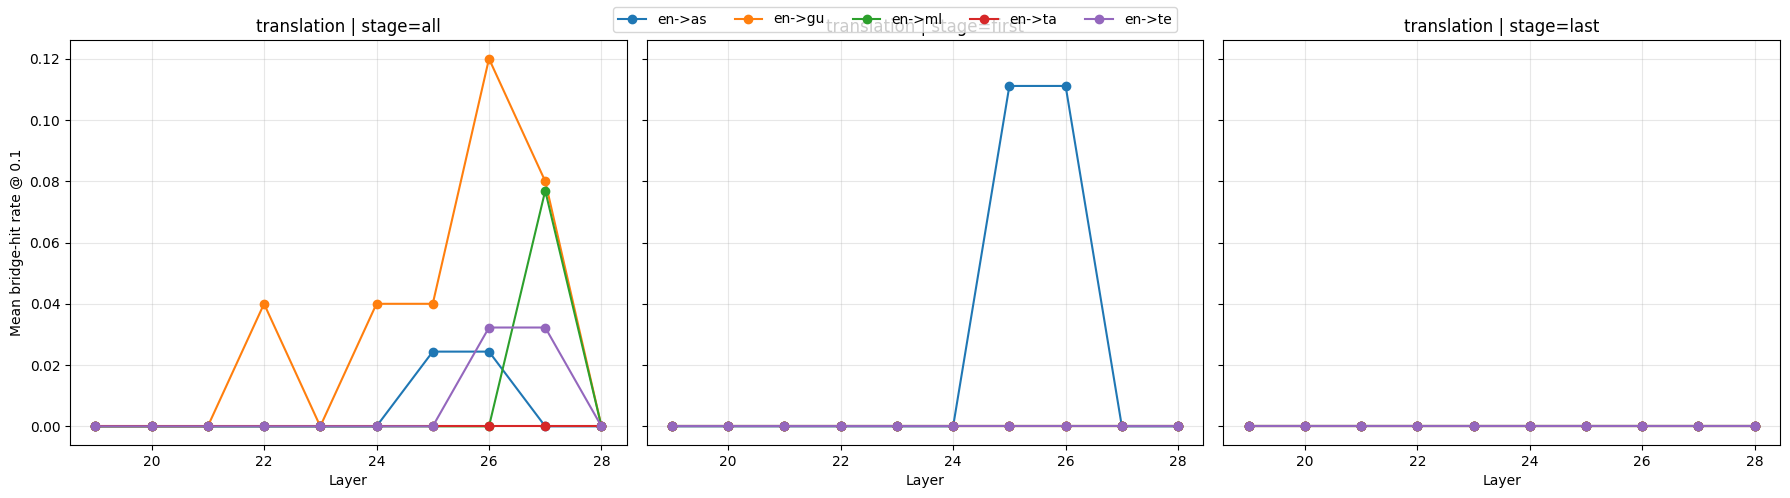

,pair,single_hit_rate@0.1
0,en->as,0.000000
1,en->gu,0.072727
2,en->ml,0.025000
3,en->ta,0.000000
4,en->te,0.025000


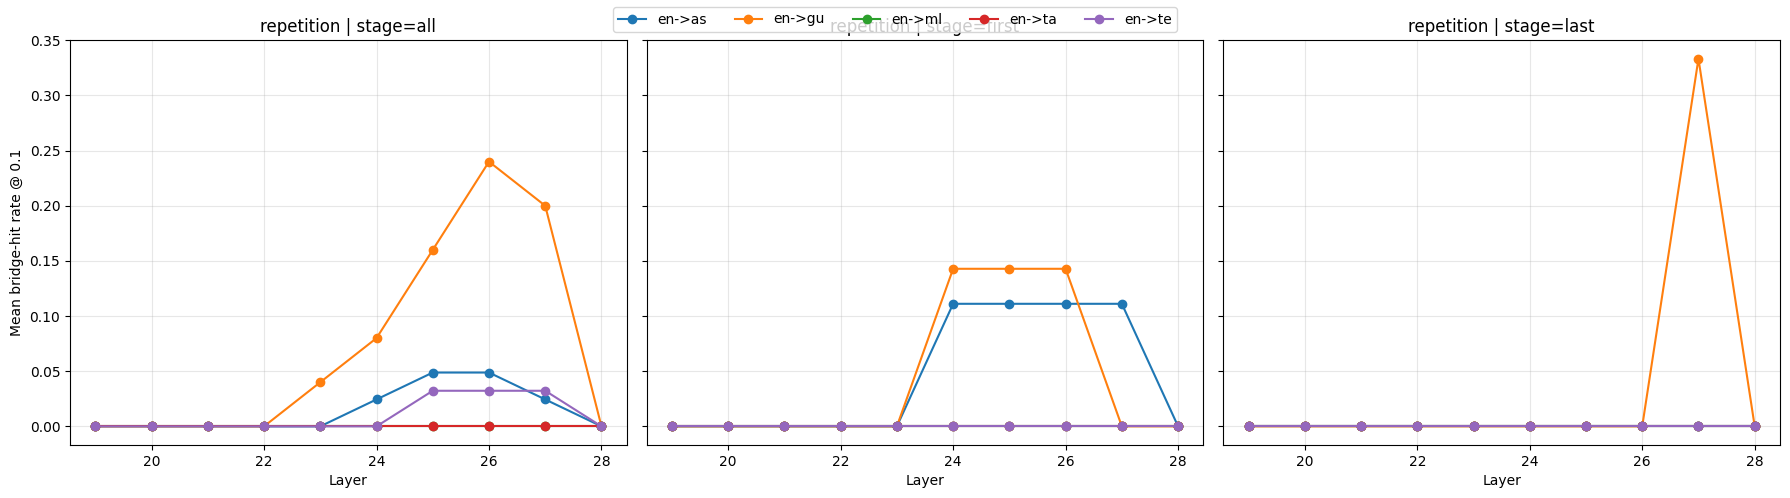

,pair,single_hit_rate@0.1
0,en->as,0.025000
1,en->gu,0.118182
2,en->ml,0.000000
3,en->ta,0.000000
4,en->te,0.037500


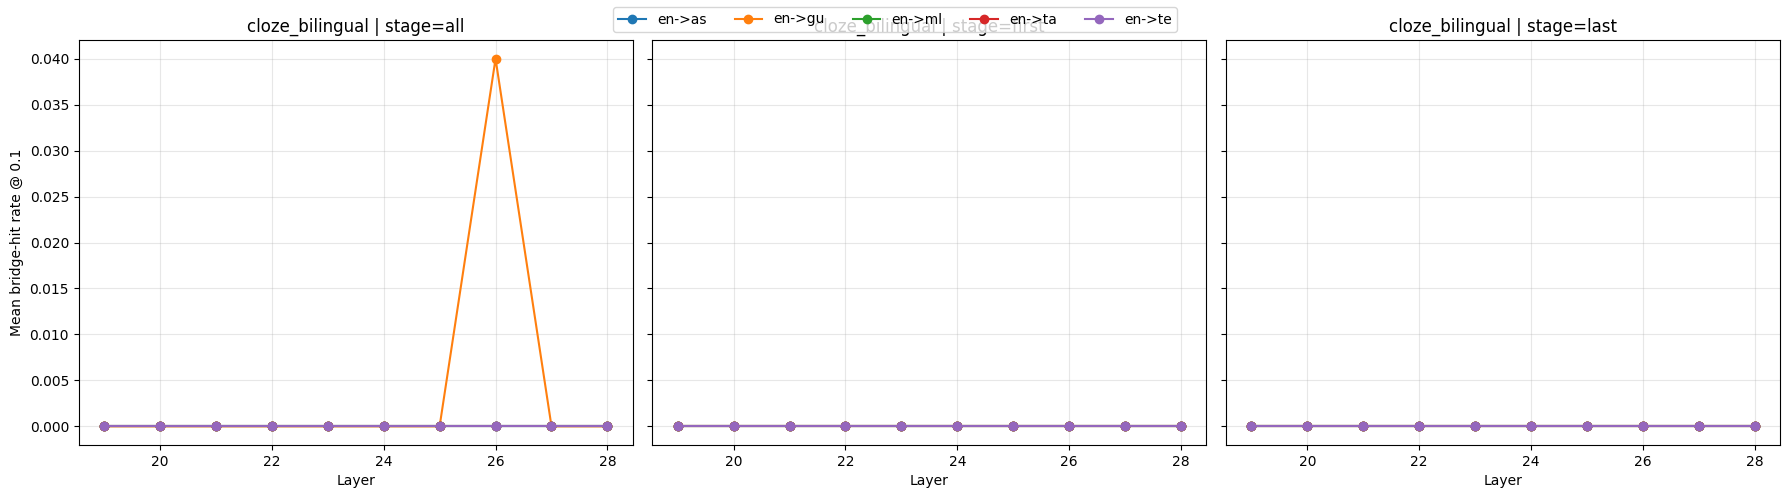

,pair,single_hit_rate@0.1
0,en->as,0.000000
1,en->gu,0.009091
2,en->ml,0.000000
3,en->ta,0.000000
4,en->te,0.000000


In [ ]:
def filter_last_n_layers(df, n_last=LAST_N_LAYERS_FOR_PAPER_STYLE_PLOTS):
    if len(df) == 0:
        return df
    max_layer = int(df["layer"].max())
    keep_layers = list(range(max(max_layer - n_last + 1, 0), max_layer + 1))
    return df[df["layer"].isin(keep_layers)].copy()

paper_plot_df = filter_last_n_layers(results_summary_df)

for task in TASKS:
    sub = paper_plot_df[paper_plot_df["task"] == task]
    if len(sub) == 0:
        continue

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    for ax, stage_name in zip(axes, ["all", "first", "last"]):
        if stage_name == "all":
            stage_sub = sub[~sub[f"bridge_hit@{PRIMARY_THRESHOLD}"].isna()].copy()
        else:
            stage_sub = sub[sub["stage"] == stage_name].copy()

        for pair in sorted(stage_sub["pair"].unique()):
            s = stage_sub[stage_sub["pair"] == pair].groupby("layer")[f"bridge_hit@{PRIMARY_THRESHOLD}"].mean().reset_index()
            ax.plot(s["layer"], s[f"bridge_hit@{PRIMARY_THRESHOLD}"], marker="o", label=pair)

        ax.set_title(f"{task} | stage={stage_name}")
        ax.set_xlabel("Layer")
        ax.grid(alpha=0.3)

    axes[0].set_ylabel(f"Mean bridge-hit rate @ {PRIMARY_THRESHOLD}")
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=min(5, len(labels)))
    plt.tight_layout()
    plt.show()

    single_sub = sub[sub["stage"] == "single"]
    if len(single_sub):
        display(single_sub.groupby("pair")[f"bridge_hit@{PRIMARY_THRESHOLD}"].mean().reset_index(name=f"single_hit_rate@{PRIMARY_THRESHOLD}"))

## Cell 27 — bridge-mass plots

**What this block does**

Plots the continuous bridge-mass signal rather than thresholded hits.

**Why this matters**

A thresholded hit may miss weak-but-real distributed evidence.
Bridge-mass lets you see whether several bridge tokens are sharing probability without any one token crossing the threshold.

**What you should expect to see**

Task-wise line plots over the last N layers.

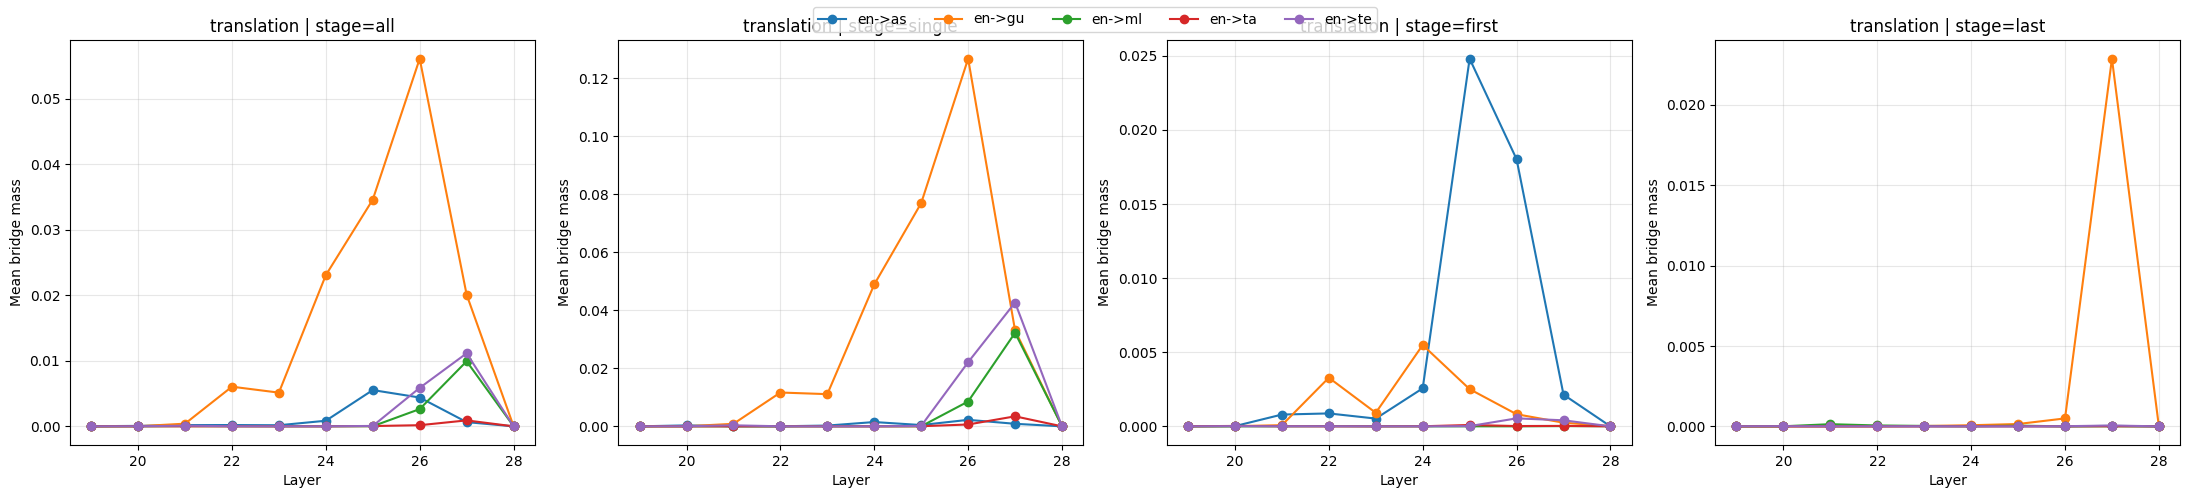

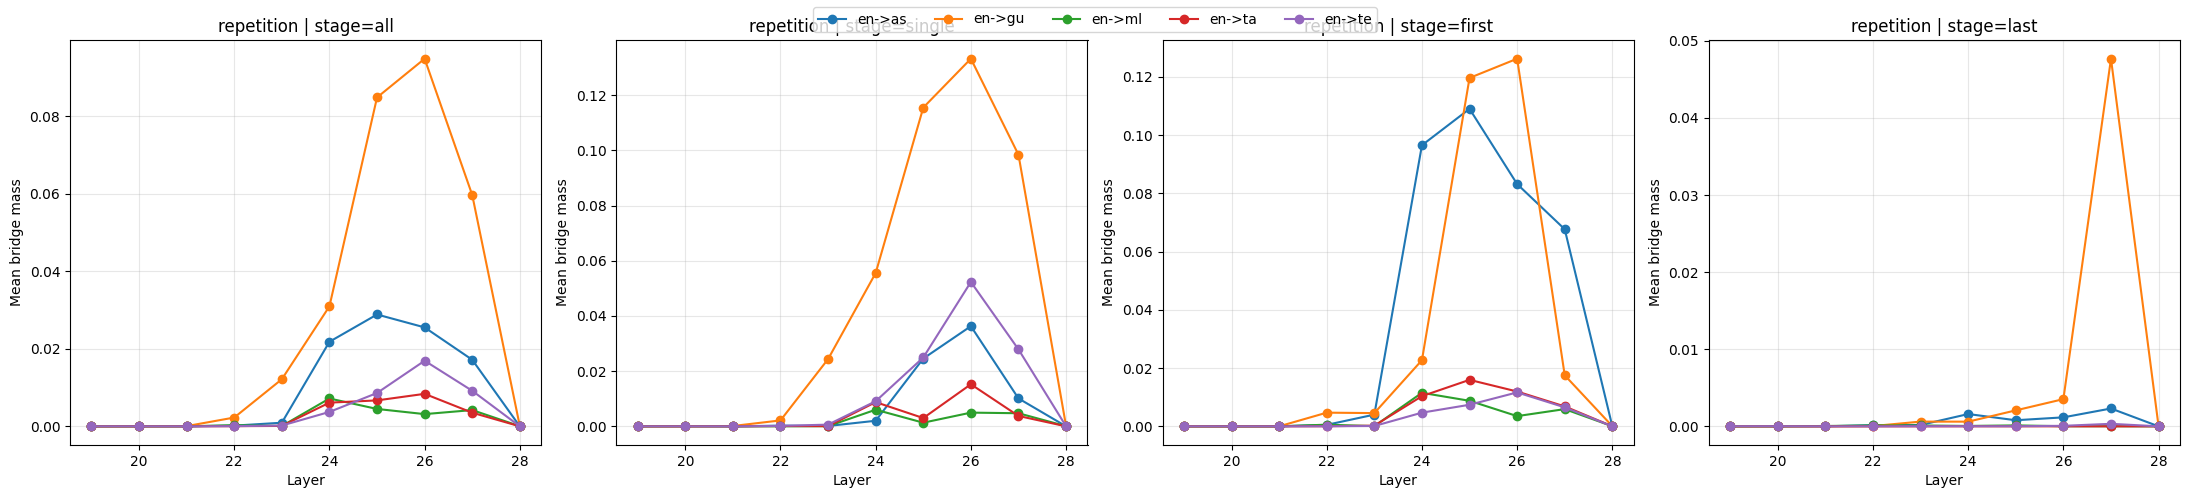

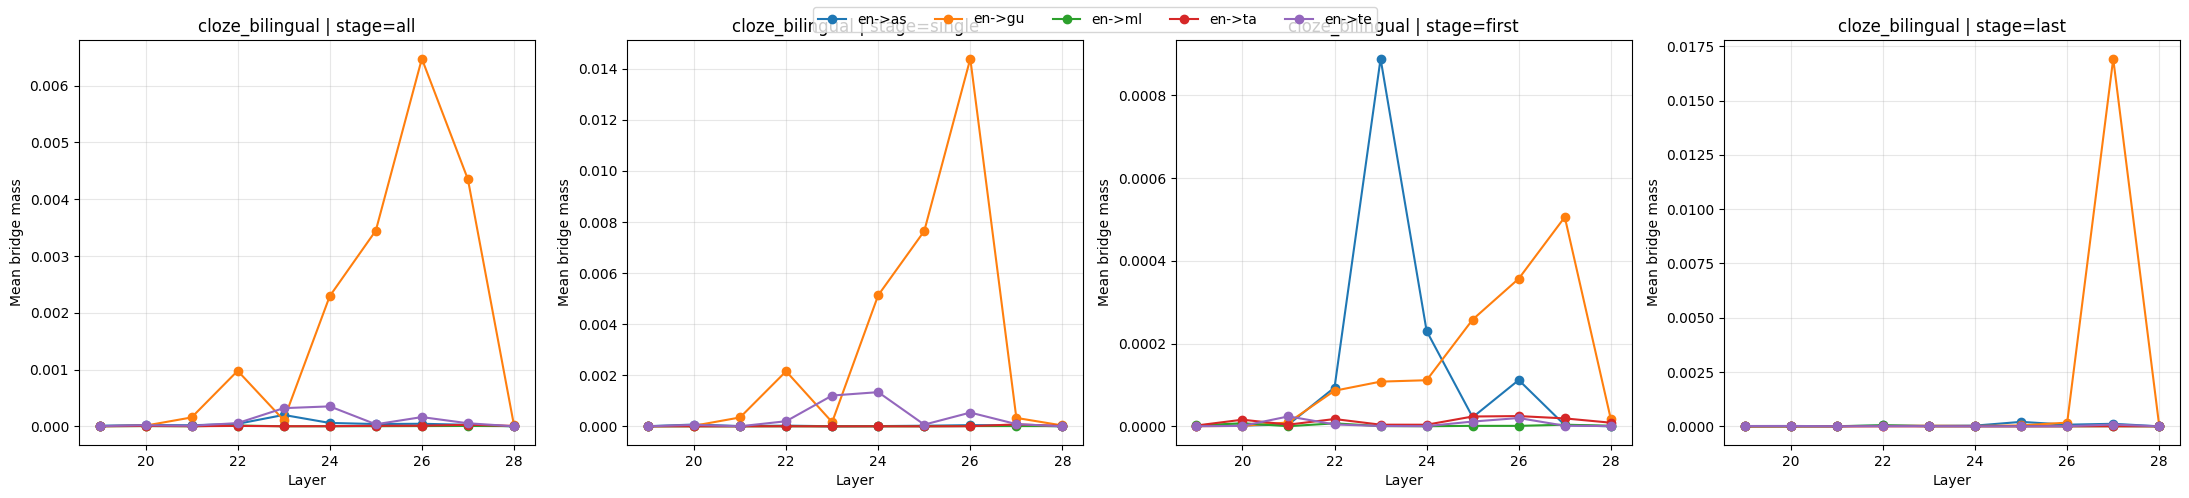

In [ ]:
for task in TASKS:
    sub = paper_plot_df[paper_plot_df["task"] == task]
    if len(sub) == 0:
        continue

    fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=False)
    for ax, stage_name in zip(axes, ["all", "single", "first", "last"]):
        if stage_name == "all":
            stage_sub = sub.copy()
        else:
            stage_sub = sub[sub["stage"] == stage_name].copy()

        for pair in sorted(stage_sub["pair"].unique()):
            s = stage_sub[stage_sub["pair"] == pair].groupby("layer")["bridge_mass"].mean().reset_index()
            ax.plot(s["layer"], s["bridge_mass"], marker="o", label=pair)

        ax.set_title(f"{task} | stage={stage_name}")
        ax.set_xlabel("Layer")
        ax.set_ylabel("Mean bridge mass")
        ax.grid(alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=min(5, len(labels)))
    plt.tight_layout()
    plt.show()

## Cell 28 — task-frequency chart (Fig. 5 style sanity analogue)

**What this block does**

This block implements a rough sanity analogue of the paper’s task-frequency comparison.

We define a task-level frequency using the **last N layers** and the **primary threshold**.

**What you should expect to see**

A grouped bar chart by pair showing whether:
- translation
- repetition
- cloze

show different bridge-hit frequencies.

This is not the paper’s exact metric, but it is close in spirit.

,pair,task,mean_frequency
0,en->as,cloze_bilingual,0.000000
1,en->as,repetition,0.014634
2,en->as,translation,0.004878
3,en->gu,cloze_bilingual,0.004000
4,en->gu,repetition,0.072000
5,en->gu,translation,0.032000
6,en->ml,cloze_bilingual,0.000000
7,en->ml,repetition,0.000000
8,en->ml,translation,0.007692
9,en->ta,cloze_bilingual,0.000000


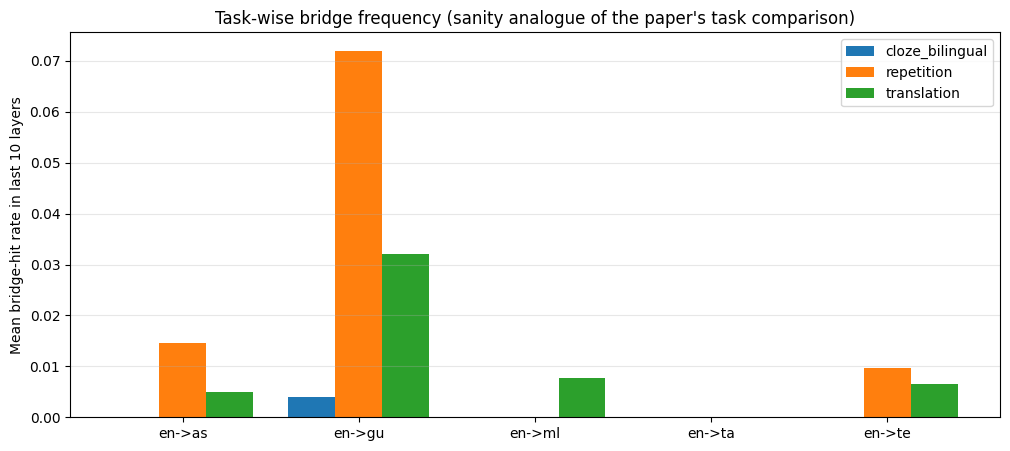

In [ ]:
freq_df = filter_last_n_layers(results_summary_df)
metric = f"bridge_hit@{PRIMARY_THRESHOLD}"
freq_plot_rows = []

if len(freq_df):
    valid = freq_df[~freq_df[metric].isna()].copy()
    for (pair, task), grp in valid.groupby(["pair", "task"]):
        freq_plot_rows.append({
            "pair": pair,
            "task": task,
            "mean_frequency": grp[metric].mean(),
        })

freq_plot_df = pd.DataFrame(freq_plot_rows)
display(freq_plot_df)

if len(freq_plot_df):
    pairs = sorted(freq_plot_df["pair"].unique())
    tasks_sorted = list(dict.fromkeys(freq_plot_df["task"].tolist()))
    x = np.arange(len(pairs))
    width = 0.8 / max(1, len(tasks_sorted))

    plt.figure(figsize=(12, 5))
    for i, task in enumerate(tasks_sorted):
        vals = []
        for pair in pairs:
            sub = freq_plot_df[(freq_plot_df["pair"] == pair) & (freq_plot_df["task"] == task)]
            vals.append(float(sub["mean_frequency"].iloc[0]) if len(sub) else 0.0)
        plt.bar(x + i*width, vals, width=width, label=task)

    plt.xticks(x + width*(len(tasks_sorted)-1)/2, pairs)
    plt.ylabel(f"Mean bridge-hit rate in last {LAST_N_LAYERS_FOR_PAPER_STYLE_PLOTS} layers")
    plt.title("Task-wise bridge frequency (sanity analogue of the paper's task comparison)")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.show()

## Cell 29 — one sample heatmap

**What this block does**

Shows one heatmap of bridge-mass across layers and timesteps for a selected example.

**Why this matters**

Sometimes the summary curves look abstract.
A heatmap lets you see whether the bridge signal is:
- early
- late
- narrow
- broad
- tied to one timestep or several

**What you should expect to see**

A single heatmap for a chosen `(pair, task, concept)` example.

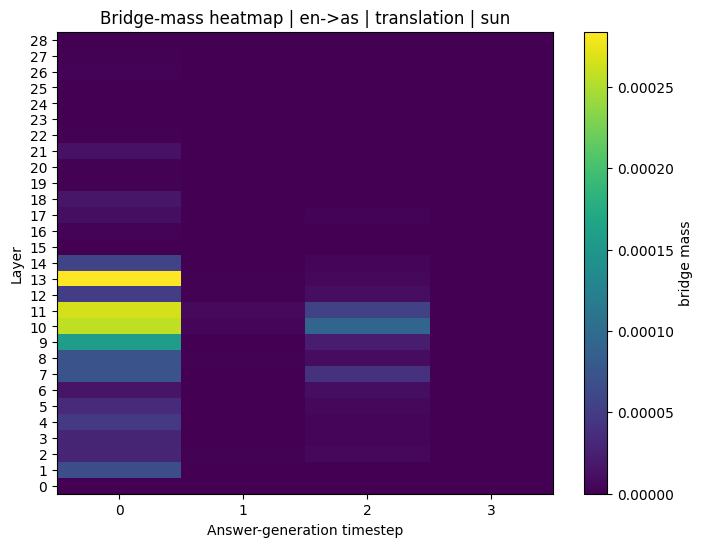

In [ ]:
if len(results_summary_df):
    sub = results_summary_df[
        (results_summary_df["pair"] == INSPECT_PAIR) &
        (results_summary_df["task"] == INSPECT_TASK) &
        (results_summary_df["concept"] == INSPECT_CONCEPT)
    ].copy()

    pivot = sub.pivot_table(index="layer", columns="timestep", values="bridge_mass", aggfunc="mean")
    plt.figure(figsize=(8, 6))
    plt.imshow(pivot.values, aspect="auto", origin="lower")
    plt.colorbar(label="bridge mass")
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xlabel("Answer-generation timestep")
    plt.ylabel("Layer")
    plt.title(f"Bridge-mass heatmap | {INSPECT_PAIR} | {INSPECT_TASK} | {INSPECT_CONCEPT}")
    plt.show()

## Cell 30 — exports

**What this block does**

Saves the main tables to CSV files so you can inspect them outside the notebook.

**What you should expect to see**

A list of written file paths.

In [ ]:
export_dir = Path("latent_bridge_audit_exports")
export_dir.mkdir(parents=True, exist_ok=True)

exports = {
    "forms_audit.csv": forms_audit_df,
    "candidate_long.csv": candidate_long_df,
    "overlap_stage.csv": overlap_stage_df,
    "frag.csv": frag_df,
    "forms_keep.csv": forms_keep_df,
    "stage_cov.csv": stage_cov,
    "results_summary.csv": results_summary_df,
    "results_bridge_token.csv": results_bridge_token_df,
    "sweep_summary.csv": sweep_summary_df,
}

for fn, df in exports.items():
    try:
        df.to_csv(export_dir / fn, index=False)
        print("wrote", export_dir / fn)
    except Exception as e:
        print("failed", fn, str(e))

wrote latent_bridge_audit_exports/forms_audit.csv
wrote latent_bridge_audit_exports/candidate_long.csv
wrote latent_bridge_audit_exports/overlap_stage.csv
wrote latent_bridge_audit_exports/frag.csv
wrote latent_bridge_audit_exports/forms_keep.csv
wrote latent_bridge_audit_exports/stage_cov.csv
wrote latent_bridge_audit_exports/results_summary.csv
wrote latent_bridge_audit_exports/results_bridge_token.csv
wrote latent_bridge_audit_exports/sweep_summary.csv


## Cell 31 — updated checklist

**What this block does**

Creates an end-of-run checklist telling us:

- what got implemented
- what is empirically looking okay
- what blockers were encountered
- what still belongs to the next iteration

**What you should expect to see**

A markdown checklist with both:
- solved items
- unresolved items / blockers

In [ ]:
checklist_lines = []
checklist_lines.append("# Updated checklist after notebook v2")
checklist_lines.append("")
checklist_lines.append("## Implemented in v2")
checklist_lines.append("- [x] Devanagari bridge probing implemented")
checklist_lines.append("- [x] Multilingual model presets include Sarvam-1, Param-1-7B, and Sarvam-Translate")
checklist_lines.append("- [x] Raw candidate strings are shown")
checklist_lines.append("- [x] Tokenizer-surviving candidates are shown")
checklist_lines.append("- [x] Candidate token IDs are shown")
checklist_lines.append("- [x] Rope/rassi-style overlap analysis is explicit")
checklist_lines.append("- [x] Same-script bridge/native exclusion is explicit")
checklist_lines.append("- [x] Empty candidate coverage is treated as NA rather than false negative")
checklist_lines.append("- [x] Stage-wise analysis includes first / mid / last / single / all")
checklist_lines.append("- [x] Threshold sweep implemented")
checklist_lines.append("- [x] Bridge-mass retained as a continuous companion metric")
checklist_lines.append("- [x] Detailed manual inspection tables for selected examples are implemented")
checklist_lines.append("")

# Empirical findings / blockages
checklist_lines.append("## Run-time findings / possible blockages")
try:
    avg_cov = stage_cov.groupby("stage")["stage_scorable"].mean().to_dict()
    for st, val in avg_cov.items():
        checklist_lines.append(f"- [ ] Mean scorable coverage for stage `{st}` = {val:.3f}")
except Exception:
    checklist_lines.append("- [ ] Stage coverage stats unavailable")

try:
    frag_summary = frag_df.groupby("pair")[["native_len", "roman_len", "bridge_len"]].mean().round(2)
    for pair, row in frag_summary.iterrows():
        checklist_lines.append(f"- [ ] `{pair}` mean token lengths: native={row['native_len']}, roman={row['roman_len']}, bridge={row['bridge_len']}")
except Exception:
    checklist_lines.append("- [ ] Fragmentation stats unavailable")

if MODEL_KEY == "sarvam-translate" and TASKS != ["translation"]:
    checklist_lines.append("- [ ] Sarvam-Translate is being used beyond translation; interpret repetition/cloze only as exploratory")
else:
    checklist_lines.append("- [ ] Sarvam-Translate caution acknowledged in config")

checklist_lines.append("")
checklist_lines.append("## Still open for next iteration")
checklist_lines.append("- [ ] Activation patching")
checklist_lines.append("- [ ] Final grapheme vs akshara scoring comparison")
checklist_lines.append("- [ ] Final Roman-control choice if current control still fragments badly")
checklist_lines.append("- [ ] Threshold calibration with decoy controls")
checklist_lines.append("- [ ] Larger curated dataset")
checklist_lines.append("- [ ] Decide whether Bengali bridge should move from secondary to primary follow-up")
checklist_lines.append("- [ ] If Sarvam-Translate behaves very differently, decide whether to treat it as a translation-only appendix model")

display(Markdown("\n".join(checklist_lines)))

# Updated checklist after notebook v2

## Implemented in v2
- [x] Devanagari bridge probing implemented
- [x] Multilingual model presets include Sarvam-1, Param-1-7B, and Sarvam-Translate
- [x] Raw candidate strings are shown
- [x] Tokenizer-surviving candidates are shown
- [x] Candidate token IDs are shown
- [x] Rope/rassi-style overlap analysis is explicit
- [x] Same-script bridge/native exclusion is explicit
- [x] Empty candidate coverage is treated as NA rather than false negative
- [x] Stage-wise analysis includes first / mid / last / single / all
- [x] Threshold sweep implemented
- [x] Bridge-mass retained as a continuous companion metric
- [x] Detailed manual inspection tables for selected examples are implemented

## Run-time findings / possible blockages
- [ ] Mean scorable coverage for stage `first` = 0.867
- [ ] Mean scorable coverage for stage `last` = 0.656
- [ ] Mean scorable coverage for stage `mid` = 0.900
- [ ] Mean scorable coverage for stage `single` = 0.889
- [ ] `en->bn` mean token lengths: native=1.39, roman=2.33, bridge=2.28
- [ ] `en->gu` mean token lengths: native=1.44, roman=2.83, bridge=1.56
- [ ] `en->ml` mean token lengths: native=1.83, roman=2.56, bridge=2.89
- [ ] `en->ta` mean token lengths: native=1.94, roman=2.72, bridge=4.33
- [ ] `en->te` mean token lengths: native=1.89, roman=3.11, bridge=2.67
- [ ] Sarvam-Translate caution acknowledged in config

## Still open for next iteration
- [ ] Activation patching
- [ ] Final grapheme vs akshara scoring comparison
- [ ] Final Roman-control choice if current control still fragments badly
- [ ] Threshold calibration with decoy controls
- [ ] Larger curated dataset
- [ ] Decide whether Bengali bridge should move from secondary to primary follow-up
- [ ] If Sarvam-Translate behaves very differently, decide whether to treat it as a translation-only appendix model

## Final note

If this notebook exposes a real late-layer Devanagari signal on the corrected audit tables, the next scientifically meaningful notebook is:

1. same corrected setup on **Param-1-7B**
2. add **Hindi-source** runs
3. only then implement **activation patching**

That sequence keeps the interpretation clean.

# **Eng-Odia**

In [ ]:
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_PRESETS = {
    "sarvam-1": {
        "hf_name": "sarvamai/sarvam-1",
        "family": "base_completion",
        "prefer_chat_template": False,
        "note": "2B multilingual Indic completion model",
    },
    "param-1-7b": {
        "hf_name": "bharatgenai/Param-1-7B",
        "family": "base_completion",
        "prefer_chat_template": False,
        "note": "7B multilingual Indic MoE base model",
    },
    "sarvam-translate": {
        "hf_name": "sarvamai/sarvam-translate",
        "family": "instruction_translation",
        "prefer_chat_template": True,
        "note": "Gemma3-4B-IT based translation-specialized model; non-translation tasks are exploratory",
    },
}

MODEL_KEY = "sarvam-1"  # change here
MODEL_NAME = MODEL_PRESETS[MODEL_KEY]["hf_name"]

# Active bridge for this notebook version
BRIDGE = "deva"   # "deva" or "beng"

# Default source-language setup
SOURCE_LANGS = ["en"]   # add "hi" later if desired

# Default target pairs for Devanagari sanity
TARGET_LANGS = ["or", "gu", "ml", "ta", "te"]

# Small sanity lexicon size
N_EXAMPLES_PER_PAIR = 18

# Task policy
TASKS_DEFAULT = ["translation", "repetition", "cloze_bilingual"]
ALLOW_NON_TRANSLATION_TASKS_FOR_SARVAM_TRANSLATE = False

if MODEL_KEY == "sarvam-translate" and not ALLOW_NON_TRANSLATION_TASKS_FOR_SARVAM_TRANSLATE:
    TASKS = ["translation"]
else:
    TASKS = TASKS_DEFAULT

# Threshold sweep for the max-candidate rule
PRIMARY_THRESHOLD = 0.10
THRESHOLD_SWEEP = [0.20, 0.10, 0.05, 0.02]

# Candidate construction
USE_GRAPHEME_SEGMENTATION = True
SPACE_MARKER_CANDIDATES = ["▁", " "]  # SentencePiece + literal-space forms

# Roman control policy
ROMAN_CONTROL_MODE = "ascii_simplified"
# options:
#   "ascii_simplified" -> deterministic Roman transliteration followed by ASCII simplification
#   "deterministic_raw" -> deterministic Roman transliteration only

# Chat template policy
USE_CHAT_TEMPLATE_IF_AVAILABLE = True

# Compute budget
USE_4BIT = True
RUN_WARMUP_ONLY = False
MAX_WARMUP_EXAMPLES_PER_PAIR = 4
LAST_N_LAYERS_FOR_PAPER_STYLE_PLOTS = 10
TOP_K_FOR_INSPECTION = 15
COLLECT_BRIDGE_CANDIDATE_PROBS = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print({
    "model_key": MODEL_KEY,
    "model_name": MODEL_NAME,
    "bridge": BRIDGE,
    "source_langs": SOURCE_LANGS,
    "target_langs": TARGET_LANGS,
    "n_examples_per_pair": N_EXAMPLES_PER_PAIR,
    "tasks": TASKS,
    "roman_control_mode": ROMAN_CONTROL_MODE,
    "threshold_sweep": THRESHOLD_SWEEP,
    "device": DEVICE,
})

{'model_key': 'sarvam-1', 'model_name': 'sarvamai/sarvam-1', 'bridge': 'deva', 'source_langs': ['en'], 'target_langs': ['or', 'gu', 'ml', 'ta', 'te'], 'n_examples_per_pair': 18, 'tasks': ['translation', 'repetition', 'cloze_bilingual'], 'roman_control_mode': 'ascii_simplified', 'threshold_sweep': [0.2, 0.1, 0.05, 0.02], 'device': 'cuda'}


In [ ]:
CONCEPTS = [
    "sun", "moon", "water", "fire", "book", "flower", "fish", "mango",
    "brother", "mother", "door", "rope", "music", "school", "house",
    "cat", "elephant", "tree"
]

LEXICON = {
    "or": {
    "sun": "ସୂର୍ଯ୍ୟ",
    "moon": "ଚନ୍ଦ୍ର",
    "water": "ପାଣି",
    "fire": "ଅଗ୍ନି",
    "book": "ବହି",
    "flower": "ଫୁଲ",
    "fish": "ମାଛ",
    "mango": "ଆମ୍ବ",
    "brother": "ଭାଇ",
    "mother": "ମା",
    "door": "ଦୁଆର",
    "rope": "ରସି",
    "music": "ସଙ୍ଗୀତ",
    "school": "ବିଦ୍ୟାଳୟ",
    "house": "ଘର",
    "cat": "ବିଲେଇ",
    "elephant": "ହାତୀ",
    "tree": "ଗଛ"
},
    "gu": {
        "sun":"સૂર્ય", "moon":"ચંદ્ર", "water":"પાણી", "fire":"આગ", "book":"પુસ્તક",
        "flower":"ફૂલ", "fish":"માછલી", "mango":"કેરી", "brother":"ભાઈ", "mother":"મા",
        "door":"દરવાજો", "rope":"દોરડું", "music":"સંગીત", "school":"શાળા",
        "house":"ઘર", "cat":"બિલાડી", "elephant":"હાથી", "tree":"ઝાડ"
    },
    "ml": {
        "sun":"സൂര്യൻ", "moon":"ചന്ദ്രൻ", "water":"വെള്ളം", "fire":"തീ", "book":"പുസ്തകം",
        "flower":"പൂവ്", "fish":"മീൻ", "mango":"മാങ്ങ", "brother":"സഹോദരൻ", "mother":"അമ്മ",
        "door":"വാതിൽ", "rope":"കയർ", "music":"സംഗീതം", "school":"സ്കൂൾ",
        "house":"വീട്", "cat":"പൂച്ച", "elephant":"ആന", "tree":"മരം"
    },
    "ta": {
        "sun":"சூரியன்", "moon":"நிலா", "water":"தண்ணீர்", "fire":"நெருப்பு", "book":"புத்தகம்",
        "flower":"பூ", "fish":"மீன்", "mango":"மாம்பழம்", "brother":"அண்ணன்", "mother":"அம்மா",
        "door":"கதவு", "rope":"கயிறு", "music":"இசை", "school":"பள்ளி",
        "house":"வீடு", "cat":"பூனை", "elephant":"யானை", "tree":"மரம்"
    },
    "te": {
        "sun":"సూర్యుడు", "moon":"చంద్రుడు", "water":"నీరు", "fire":"అగ్ని", "book":"పుస్తకం",
        "flower":"పువ్వు", "fish":"చేప", "mango":"మామిడి", "brother":"అన్న", "mother":"అమ్మ",
        "door":"తలుపు", "rope":"తాడు", "music":"సంగీతం", "school":"పాఠశాల",
        "house":"ఇల్లు", "cat":"పిల్లి", "elephant":"ఏనుగు", "tree":"చెట్టు"
    },
}

LANG_NAMES = {
    "en":"English", "hi":"Hindi", "mr":"Marathi", "bn":"Bengali", "gu":"Gujarati",
    "ml":"Malayalam", "ta":"Tamil", "te":"Telugu", "or":"Odia", "pa":"Punjabi", "kn":"Kannada"
}

rows = []
for src in SOURCE_LANGS:
    for tgt in TARGET_LANGS:
        for concept in CONCEPTS[:N_EXAMPLES_PER_PAIR]:
            rows.append({
                "pair": f"{src}->{tgt}",
                "source_lang": src,
                "target_lang": tgt,
                "concept": concept,
                "source_word": concept if src == "en" else None,   # filled later for hi if needed
                "target_word_native": LEXICON[tgt][concept],
            })

lexicon_df = pd.DataFrame(rows)
display(lexicon_df.head(20))
print("Total rows:", len(lexicon_df))

,pair,source_lang,target_lang,concept,source_word,target_word_native
0,en->or,en,or,sun,sun,ସୂର୍ଯ୍ୟ
1,en->or,en,or,moon,moon,ଚନ୍ଦ୍ର
2,en->or,en,or,water,water,ପାଣି
3,en->or,en,or,fire,fire,ଅଗ୍ନି
4,en->or,en,or,book,book,ବହି
5,en->or,en,or,flower,flower,ଫୁଲ
6,en->or,en,or,fish,fish,ମାଛ
7,en->or,en,or,mango,mango,ଆମ୍ବ
8,en->or,en,or,brother,brother,ଭାଇ
9,en->or,en,or,mother,mother,ମା


Total rows: 90


In [ ]:
# Small source-side lexicon for Hindi extension.
# This is only used if "hi" is included in SOURCE_LANGS.
SOURCE_LEXICON = {
    "hi": {
        "sun":"सूरज", "moon":"चाँद", "water":"पानी", "fire":"आग", "book":"पुस्तक",
        "flower":"फूल", "fish":"मछली", "mango":"आम", "brother":"भाई", "mother":"माँ",
        "door":"दरवाज़ा", "rope":"रस्सी", "music":"संगीत", "school":"स्कूल",
        "house":"घर", "cat":"बिल्ली", "elephant":"हाथी", "tree":"पेड़"
    }
}

def fill_source_word(row):
    if row["source_lang"] == "en":
        return row["concept"]
    return SOURCE_LEXICON[row["source_lang"]][row["concept"]]

lexicon_df["source_word"] = lexicon_df.apply(fill_source_word, axis=1)
display(lexicon_df.head(20))

,pair,source_lang,target_lang,concept,source_word,target_word_native
0,en->or,en,or,sun,sun,ସୂର୍ଯ୍ୟ
1,en->or,en,or,moon,moon,ଚନ୍ଦ୍ର
2,en->or,en,or,water,water,ପାଣି
3,en->or,en,or,fire,fire,ଅଗ୍ନି
4,en->or,en,or,book,book,ବହି
5,en->or,en,or,flower,flower,ଫୁଲ
6,en->or,en,or,fish,fish,ମାଛ
7,en->or,en,or,mango,mango,ଆମ୍ବ
8,en->or,en,or,brother,brother,ଭାଇ
9,en->or,en,or,mother,mother,ମା


In [ ]:
AKSH_SCRIPT = {
    "or": "Odiya",
    "gu": "Gujarati",
    "hi": "Devanagari",
    "mr": "Devanagari",
    "ml": "Malayalam",
    "ta": "Tamil",
    "te": "Telugu",
    "or": "Oriya",
    "pa": "Gurmukhi",
    "kn": "Kannada",
    "en": None,
}

BRIDGE_TARGET_CODE = {"deva": "hi", "beng": "bn"}
BRIDGE_TARGET_SCRIPT = {"deva": "Devanagari", "beng": "Bengali"}

def safe_strip(s: str) -> str:
    return re.sub(r"\s+", " ", s).strip()

def translit_native_to_bridge(text: str, src_lang: str, bridge: str) -> Tuple[str, str]:
    if src_lang == "en":
        return text, "identity-en"
    if bridge not in BRIDGE_TARGET_CODE:
        raise ValueError(bridge)
    try:
        out = UnicodeIndicTransliterator.transliterate(text, src_lang, BRIDGE_TARGET_CODE[bridge])
        return safe_strip(out), "unicode_indic"
    except Exception:
        out = aksh_trans.process(AKSH_SCRIPT[src_lang], BRIDGE_TARGET_SCRIPT[bridge], text)
        return safe_strip(out), "aksharamukha_fallback"

def strip_to_ascii(text: str) -> str:
    return safe_strip(unidecode(text))

def translit_native_to_roman(text: str, src_lang: str) -> Tuple[str, str]:
    if src_lang == "en":
        return text, "identity-en"
    raw = aksh_trans.process(AKSH_SCRIPT[src_lang], "ISO", text)
    raw = safe_strip(raw)
    if ROMAN_CONTROL_MODE == "deterministic_raw":
        return raw, "aksharamukha_iso"
    elif ROMAN_CONTROL_MODE == "ascii_simplified":
        return strip_to_ascii(raw), "aksharamukha_iso_plus_unidecode"
    else:
        raise ValueError(ROMAN_CONTROL_MODE)

forms_rows = []
for _, row in lexicon_df.iterrows():
    roman_word, roman_tool = translit_native_to_roman(row["target_word_native"], row["target_lang"])
    deva_word, deva_tool = translit_native_to_bridge(row["target_word_native"], row["target_lang"], "deva")
    beng_word, beng_tool = translit_native_to_bridge(row["target_word_native"], row["target_lang"], "beng")
    forms_rows.append({
        **row.to_dict(),
        "target_word_roman_control": roman_word,
        "roman_control_tool": roman_tool,
        "target_word_bridge_deva": deva_word,
        "deva_bridge_tool": deva_tool,
        "target_word_bridge_beng": beng_word,
        "beng_bridge_tool": beng_tool,
        "manual_note": "",
    })

forms_df = pd.DataFrame(forms_rows)
display(forms_df.head(20))

,pair,source_lang,target_lang,concept,source_word,target_word_native,target_word_roman_control,roman_control_tool,target_word_bridge_deva,deva_bridge_tool,target_word_bridge_beng,beng_bridge_tool,manual_note
0,en->or,en,or,sun,sun,ସୂର୍ଯ୍ୟ,suryya,aksharamukha_iso_plus_unidecode,सूर्य्य़,unicode_indic,সূর্য্য়,unicode_indic,
1,en->or,en,or,moon,moon,ଚନ୍ଦ୍ର,candra,aksharamukha_iso_plus_unidecode,चन्द्र,unicode_indic,চন্দ্র,unicode_indic,
2,en->or,en,or,water,water,ପାଣି,pani,aksharamukha_iso_plus_unidecode,पाणि,unicode_indic,পাণি,unicode_indic,
3,en->or,en,or,fire,fire,ଅଗ୍ନି,agni,aksharamukha_iso_plus_unidecode,अग्नि,unicode_indic,অগ্নি,unicode_indic,
4,en->or,en,or,book,book,ବହି,bahi,aksharamukha_iso_plus_unidecode,बहि,unicode_indic,বহি,unicode_indic,
5,en->or,en,or,flower,flower,ଫୁଲ,phula,aksharamukha_iso_plus_unidecode,फुल,unicode_indic,ফুল,unicode_indic,
6,en->or,en,or,fish,fish,ମାଛ,macha,aksharamukha_iso_plus_unidecode,माछ,unicode_indic,মাছ,unicode_indic,
7,en->or,en,or,mango,mango,ଆମ୍ବ,amba,aksharamukha_iso_plus_unidecode,आम्ब,unicode_indic,আম্ব,unicode_indic,
8,en->or,en,or,brother,brother,ଭାଇ,bhai,aksharamukha_iso_plus_unidecode,भाइ,unicode_indic,ভাই,unicode_indic,
9,en->or,en,or,mother,mother,ମା,ma,aksharamukha_iso_plus_unidecode,मा,unicode_indic,মা,unicode_indic,


In [ ]:
def codepoint_list(text: str) -> List[str]:
    return [f"{ch} (U+{ord(ch):04X}, {unicodedata.name(ch, 'UNKNOWN')})" for ch in text]

def graphemes(text: str) -> List[str]:
    return re.findall(r"\X", text)

toy_examples = []
for idx in [0, 10, 20, 40]:
    row = forms_df.iloc[idx]
    bridge_word = row["target_word_bridge_deva"] if BRIDGE == "deva" else row["target_word_bridge_beng"]
    toy_examples.append({
        "pair": row["pair"],
        "concept": row["concept"],
        "native_word": row["target_word_native"],
        "bridge_word": bridge_word,
        "codepoints": codepoint_list(bridge_word),
        "graphemes_used_for_scoring": graphemes(bridge_word),
        "human_note": "Compare graphemes with visible Indic units; this is still not a final akshara scorer."
    })

toy_seg_df = pd.DataFrame(toy_examples)
display(toy_seg_df)

,pair,concept,native_word,bridge_word,codepoints,graphemes_used_for_scoring,human_note
0,en->or,sun,ସୂର୍ଯ୍ୟ,सूर्य्य़,"[स (U+0938, DEVANAGARI LETTER SA), ू (U+0942, DEVANAGARI VOWEL SIGN UU), र (U+0930, DEVANAGARI LETTER RA), ् (U+094D, DEVANAGARI SIGN VIRAMA), य (U+092F, DEVANAGARI LETTER YA), ् (U+094D, DEVANAGA...","[सू, र्य्य़]",Compare graphemes with visible Indic units; this is still not a final akshara scorer.
1,en->or,door,ଦୁଆର,दुआर,"[द (U+0926, DEVANAGARI LETTER DA), ु (U+0941, DEVANAGARI VOWEL SIGN U), आ (U+0906, DEVANAGARI LETTER AA), र (U+0930, DEVANAGARI LETTER RA)]","[दु, आ, र]",Compare graphemes with visible Indic units; this is still not a final akshara scorer.
2,en->gu,water,પાણી,पाणी,"[प (U+092A, DEVANAGARI LETTER PA), ा (U+093E, DEVANAGARI VOWEL SIGN AA), ण (U+0923, DEVANAGARI LETTER NNA), ी (U+0940, DEVANAGARI VOWEL SIGN II)]","[पा, णी]",Compare graphemes with visible Indic units; this is still not a final akshara scorer.
3,en->ml,book,പുസ്തകം,पुस्तकं,"[प (U+092A, DEVANAGARI LETTER PA), ु (U+0941, DEVANAGARI VOWEL SIGN U), स (U+0938, DEVANAGARI LETTER SA), ् (U+094D, DEVANAGARI SIGN VIRAMA), त (U+0924, DEVANAGARI LETTER TA), क (U+0915, DEVANAGAR...","[पु, स्त, कं]",Compare graphemes with visible Indic units; this is still not a final akshara scorer.


In [ ]:
CLOZE_TEMPLATES = {
    "sun": "The ___ rises in the east.",
    "moon": "The ___ shines at night.",
    "water": "People drink ___ every day.",
    "fire": "A camp ___ gives warmth.",
    "book": "I read a ___ before sleeping.",
    "flower": "A ___ often grows in a garden.",
    "fish": "A ___ swims in water.",
    "mango": "A ripe ___ is sweet.",
    "brother": "My ___ helps me at home.",
    "mother": "My ___ cooks food.",
    "door": "Please close the ___ quietly.",
    "rope": "He tied the box with a ___.",
    "music": "Soft ___ can be relaxing.",
    "school": "Children go to ___ in the morning.",
    "house": "Their ___ is near the market.",
    "cat": "A ___ likes to chase mice.",
    "elephant": "An ___ is a very large animal.",
    "tree": "A ___ gives shade."
}

def sample_shots(examples_df: pd.DataFrame, query_concept: str, k: int, rng: random.Random):
    pool = [row for _, row in examples_df.iterrows() if row["concept"] != query_concept]
    rng.shuffle(pool)
    return pool[:k]

def build_translation_prompt(pair_df: pd.DataFrame, query_row: pd.Series, k: int = 5, rng=None) -> str:
    rng = rng or random.Random(SEED)
    shots = sample_shots(pair_df, query_row["concept"], k=k, rng=rng)
    src_name = LANG_NAMES[query_row["source_lang"]]
    tgt_name = LANG_NAMES[query_row["target_lang"]]
    lines = []
    for s in shots:
        lines.append(f'{src_name}: "{s["source_word"]}" {tgt_name}: "{s["target_word_native"]}"')
    lines.append(f'{src_name}: "{query_row["source_word"]}" {tgt_name}: "')
    return "\n".join(lines)

def build_repetition_prompt(pair_df: pd.DataFrame, query_row: pd.Series, k: int = 5, rng=None) -> str:
    rng = rng or random.Random(SEED)
    shots = sample_shots(pair_df, query_row["concept"], k=k, rng=rng)
    tgt_name = LANG_NAMES[query_row["target_lang"]]
    lines = []
    for s in shots:
        w = s["target_word_native"]
        lines.append(f'{tgt_name}: "{w}" {tgt_name}: "{w}"')
    q = query_row["target_word_native"]
    lines.append(f'{tgt_name}: "{q}" {tgt_name}: "')
    return "\n".join(lines)

def build_cloze_prompt(pair_df: pd.DataFrame, query_row: pd.Series, k: int = 2, rng=None) -> str:
    rng = rng or random.Random(SEED)
    shots = sample_shots(pair_df, query_row["concept"], k=k, rng=rng)
    tgt_name = LANG_NAMES[query_row["target_lang"]]
    lines = []
    for s in shots:
        lines.append(f'{CLOZE_TEMPLATES[s["concept"]]} Answer in {tgt_name}: "{s["target_word_native"]}"')
    lines.append(f'{CLOZE_TEMPLATES[query_row["concept"]]} Answer in {tgt_name}: "')
    return "\n".join(lines)

demo_row = forms_df.iloc[0]
demo_pair_df = forms_df[forms_df["pair"] == demo_row["pair"]].copy()
print("=== Translation ===")
print(build_translation_prompt(demo_pair_df, demo_row))
print("\n=== Repetition ===")
print(build_repetition_prompt(demo_pair_df, demo_row))
print("\n=== Cloze ===")
print(build_cloze_prompt(demo_pair_df, demo_row))

=== Translation ===
English: "book" Odia: "ବହି"
English: "fire" Odia: "ଅଗ୍ନି"
English: "house" Odia: "ଘର"
English: "cat" Odia: "ବିଲେଇ"
English: "brother" Odia: "ଭାଇ"
English: "sun" Odia: "

=== Repetition ===
Odia: "ବହି" Odia: "ବହି"
Odia: "ଅଗ୍ନି" Odia: "ଅଗ୍ନି"
Odia: "ଘର" Odia: "ଘର"
Odia: "ବିଲେଇ" Odia: "ବିଲେଇ"
Odia: "ଭାଇ" Odia: "ଭାଇ"
Odia: "ସୂର୍ଯ୍ୟ" Odia: "

=== Cloze ===
I read a ___ before sleeping. Answer in Odia: "ବହି"
A camp ___ gives warmth. Answer in Odia: "ଅଗ୍ନି"
The ___ rises in the east. Answer in Odia: "


In [ ]:
def get_final_norm_and_lm_head(model):
    candidates = [
        ("model.norm", lambda m: m.model.norm),
        ("base_model.model.norm", lambda m: m.base_model.model.norm),
        ("transformer.ln_f", lambda m: m.transformer.ln_f),
        ("model.final_layernorm", lambda m: m.model.final_layernorm),
    ]
    final_norm = None
    final_norm_name = None
    for name, getter in candidates:
        try:
            final_norm = getter(model)
            final_norm_name = name
            break
        except Exception:
            pass
    if final_norm is None:
        raise RuntimeError("Could not find final norm automatically.")
    if not hasattr(model, "lm_head"):
        raise RuntimeError("Model has no lm_head attribute.")
    return final_norm_name, final_norm, model.lm_head

FINAL_NORM_NAME, FINAL_NORM, LM_HEAD = get_final_norm_and_lm_head(model)
N_LAYERS = getattr(model.config, "num_hidden_layers", None)

print("Using final norm:", FINAL_NORM_NAME)
print("Configured num_hidden_layers:", N_LAYERS)

@torch.no_grad()
def layer_logits_from_hidden(hidden_state: torch.Tensor) -> torch.Tensor:
    x = FINAL_NORM(hidden_state)
    logits = LM_HEAD(x)
    return logits

Using final norm: model.norm
Configured num_hidden_layers: 28


In [ ]:
def render_prompt_for_model(prompt_text: str) -> str:
    prefer_chat = MODEL_PRESETS[MODEL_KEY]["prefer_chat_template"]
    if USE_CHAT_TEMPLATE_IF_AVAILABLE and prefer_chat and hasattr(tokenizer, "apply_chat_template"):
        try:
            messages = [{"role": "user", "content": prompt_text}]
            return tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True
            )
        except Exception:
            return prompt_text
    return prompt_text

demo_rendered = render_prompt_for_model(build_translation_prompt(demo_pair_df, demo_row))
print(demo_rendered[:1200])

English: "book" Odia: "ବହି"
English: "fire" Odia: "ଅଗ୍ନି"
English: "house" Odia: "ଘର"
English: "cat" Odia: "ବିଲେଇ"
English: "brother" Odia: "ଭାଇ"
English: "sun" Odia: "


In [ ]:
def prefixes_by_units(units: List[str]) -> List[str]:
    return ["".join(units[:i]) for i in range(1, len(units)+1)]

def suffixes_by_units(units: List[str]) -> List[str]:
    return ["".join(units[i:]) for i in range(len(units))]

def substrings_by_units(units: List[str]) -> List[str]:
    out = []
    n = len(units)
    for i in range(n):
        for j in range(i+1, n+1):
            out.append("".join(units[i:j]))
    return out

def add_space_variants(strings: Iterable[str]) -> List[str]:
    out = set(strings)
    for s in strings:
        for mark in SPACE_MARKER_CANDIDATES:
            out.add(mark + s)
    return list(out)

def vocab_keep(strings: Iterable[str]) -> List[str]:
    return sorted({s for s in strings if s in vocab}, key=lambda x: vocab[x])

def stage_raw_candidates(word: str, stage: str) -> List[str]:
    units = graphemes(word) if USE_GRAPHEME_SEGMENTATION else list(word)
    if stage == "first":
        raw = prefixes_by_units(units)
        raw = add_space_variants(raw)
        return sorted(set(raw))
    elif stage == "mid":
        return sorted(set(substrings_by_units(units)))
    elif stage == "last":
        return sorted(set(suffixes_by_units(units)))
    elif stage == "single":
        # For 1-step answers we keep it explicit rather than silently merging into first/last analyses.
        raw = set(prefixes_by_units(units)) | set(suffixes_by_units(units))
        raw = set(add_space_variants(raw)) | raw
        return sorted(raw)
    else:
        raise ValueError(stage)

def stage_vocab_candidates(word: str, stage: str) -> List[str]:
    return vocab_keep(stage_raw_candidates(word, stage))

def stage_vocab_candidate_ids(word: str, stage: str) -> List[int]:
    return [vocab[s] for s in stage_vocab_candidates(word, stage)]

def primary_stage_for_timestep(t: int, T: int) -> str:
    if T == 1:
        return "single"
    if t == 0:
        return "first"
    if t == T - 1:
        return "last"
    return "mid"

In [ ]:
def active_bridge_word(row) -> str:
    return row["target_word_bridge_deva"] if BRIDGE == "deva" else row["target_word_bridge_beng"]

def bridge_same_as_native(row) -> bool:
    if BRIDGE == "deva" and row["target_lang"] in {"hi", "mr"}:
        return True
    if BRIDGE == "beng" and row["target_lang"] == "bn":
        return True
    return False

forms_audit_df = forms_df.copy()
forms_audit_df["active_bridge_word"] = forms_audit_df.apply(active_bridge_word, axis=1)
forms_audit_df["bridge_same_as_native_script"] = forms_audit_df.apply(bridge_same_as_native, axis=1)

display(
    forms_audit_df[[
        "pair", "concept", "source_word", "target_word_native",
        "target_word_roman_control", "active_bridge_word",
        "bridge_same_as_native_script", "roman_control_tool"
    ]].head(40)
)

,pair,concept,source_word,target_word_native,target_word_roman_control,active_bridge_word,bridge_same_as_native_script,roman_control_tool
0,en->or,sun,sun,ସୂର୍ଯ୍ୟ,suryya,सूर्य्य़,False,aksharamukha_iso_plus_unidecode
1,en->or,moon,moon,ଚନ୍ଦ୍ର,candra,चन्द्र,False,aksharamukha_iso_plus_unidecode
2,en->or,water,water,ପାଣି,pani,पाणि,False,aksharamukha_iso_plus_unidecode
3,en->or,fire,fire,ଅଗ୍ନି,agni,अग्नि,False,aksharamukha_iso_plus_unidecode
4,en->or,book,book,ବହି,bahi,बहि,False,aksharamukha_iso_plus_unidecode
5,en->or,flower,flower,ଫୁଲ,phula,फुल,False,aksharamukha_iso_plus_unidecode
6,en->or,fish,fish,ମାଛ,macha,माछ,False,aksharamukha_iso_plus_unidecode
7,en->or,mango,mango,ଆମ୍ବ,amba,आम्ब,False,aksharamukha_iso_plus_unidecode
8,en->or,brother,brother,ଭାଇ,bhai,भाइ,False,aksharamukha_iso_plus_unidecode
9,en->or,mother,mother,ମା,ma,मा,False,aksharamukha_iso_plus_unidecode


In [ ]:
def form_word(row, form_name: str) -> str:
    if form_name == "native":
        return row["target_word_native"]
    elif form_name == "roman":
        return row["target_word_roman_control"]
    elif form_name == "bridge":
        return row["active_bridge_word"]
    elif form_name == "english":
        return row["source_word"]
    else:
        raise ValueError(form_name)

candidate_rows = []
for _, row in forms_audit_df.iterrows():
    for form_name in ["native", "roman", "bridge", "english"]:
        word = form_word(row, form_name)
        for stage in ["first", "mid", "last", "single"]:
            raw = stage_raw_candidates(word, stage)
            kept = stage_vocab_candidates(word, stage)
            kept_ids = [vocab[s] for s in kept]
            candidate_rows.append({
                "pair": row["pair"],
                "concept": row["concept"],
                "target_lang": row["target_lang"],
                "form": form_name,
                "word": word,
                "stage": stage,
                "raw_candidates": raw,
                "vocab_candidates": kept,
                "vocab_candidate_ids": kept_ids,
                "coverage_nonempty": len(kept) > 0,
                "n_raw": len(raw),
                "n_vocab": len(kept),
            })

candidate_long_df = pd.DataFrame(candidate_rows)

display(
    candidate_long_df[[
        "pair", "concept", "form", "stage", "word",
        "n_raw", "n_vocab", "coverage_nonempty",
        "raw_candidates", "vocab_candidates", "vocab_candidate_ids"
    ]].head(30)
)

,pair,concept,form,stage,word,n_raw,n_vocab,coverage_nonempty,raw_candidates,vocab_candidates,vocab_candidate_ids
0,en->or,sun,native,first,ସୂର୍ଯ୍ୟ,6,1,True,"[ ସୂ, ସୂର୍ଯ୍ୟ, ସୂ, ସୂର୍ଯ୍ୟ, ▁ସୂ, ▁ସୂର୍ଯ୍ୟ]",[▁ସୂ],[27258]
1,en->or,sun,native,mid,ସୂର୍ଯ୍ୟ,3,1,True,"[ର୍ଯ୍ୟ, ସୂ, ସୂର୍ଯ୍ୟ]",[ର୍ଯ୍ୟ],[15300]
2,en->or,sun,native,last,ସୂର୍ଯ୍ୟ,2,1,True,"[ର୍ଯ୍ୟ, ସୂର୍ଯ୍ୟ]",[ର୍ଯ୍ୟ],[15300]
3,en->or,sun,native,single,ସୂର୍ଯ୍ୟ,9,2,True,"[ ର୍ଯ୍ୟ, ସୂ, ସୂର୍ଯ୍ୟ, ର୍ଯ୍ୟ, ସୂ, ସୂର୍ଯ୍ୟ, ▁ର୍ଯ୍ୟ, ▁ସୂ, ▁ସୂର୍ଯ୍ୟ]","[ର୍ଯ୍ୟ, ▁ସୂ]","[15300, 27258]"
4,en->or,sun,roman,first,suryya,18,5,True,"[ s, su, sur, sury, suryy, suryya, s, su, sur, sury, suryy, suryya, ▁s, ▁su, ▁sur, ▁sury, ▁suryy, ▁suryya]","[▁s, ▁su, ▁sur, su, s]","[4378, 4960, 7070, 16681, 67484]"
5,en->or,sun,roman,mid,suryya,20,11,True,"[a, r, ry, ryy, ryya, s, su, sur, sury, suryy, suryya, u, ur, ury, uryy, uryya, y, ya, yy, yya]","[ur, ry, ury, su, ya, yy, a, s, r, u, y]","[4604, 5552, 8868, 16681, 24660, 55818, 67480, 67484, 67485, 67507, 67542]"
6,en->or,sun,roman,last,suryya,6,2,True,"[a, ryya, suryya, uryya, ya, yya]","[ya, a]","[24660, 67480]"
7,en->or,sun,roman,single,suryya,33,8,True,"[ a, ryya, s, su, sur, sury, suryy, suryya, uryya, ya, yya, a, ryya, s, su, sur, sury, suryy, suryya, uryya, ya, yya, ▁a, ▁ryya, ▁s, ▁su, ▁sur, ▁sury, ▁suryy, ▁suryya, ▁uryya, ▁ya, ▁yya]","[▁a, ▁s, ▁su, ▁sur, su, ya, a, s]","[4366, 4378, 4960, 7070, 16681, 24660, 67480, 67484]"
8,en->or,sun,bridge,first,सूर्य्य़,6,2,True,"[ सू, सूर्य्य़, सू, सूर्य्य़, ▁सू, ▁सूर्य्य़]","[▁सू, सू]","[7366, 19455]"
9,en->or,sun,bridge,mid,सूर्य्य़,3,1,True,"[र्य्य़, सू, सूर्य्य़]",[सू],[19455]


In [ ]:
def set_stage_candidates(row_key_df, concept, pair, form, stage):
    sub = row_key_df[
        (row_key_df["concept"] == concept) &
        (row_key_df["pair"] == pair) &
        (row_key_df["form"] == form) &
        (row_key_df["stage"] == stage)
    ]
    if len(sub) == 0:
        return set()
    return set(sub.iloc[0]["vocab_candidates"])

overlap_rows = []
for _, row in forms_audit_df.iterrows():
    for stage in ["first", "mid", "last", "single"]:
        bridge_set = set_stage_candidates(candidate_long_df, row["concept"], row["pair"], "bridge", stage)
        native_set = set_stage_candidates(candidate_long_df, row["concept"], row["pair"], "native", stage)
        roman_set = set_stage_candidates(candidate_long_df, row["concept"], row["pair"], "roman", stage)
        english_set = set_stage_candidates(candidate_long_df, row["concept"], row["pair"], "english", stage)

        overlap_native = sorted(bridge_set & native_set)
        overlap_roman = sorted(bridge_set & roman_set)
        overlap_english = sorted(bridge_set & english_set)

        reasons = []
        if row["bridge_same_as_native_script"]:
            reasons.append("excluded: bridge script equals native script")
        if overlap_native:
            reasons.append(f"excluded: bridge/native overlap = {overlap_native}")
        if overlap_roman:
            reasons.append(f"excluded: bridge/roman overlap = {overlap_roman}")
        if overlap_english:
            reasons.append(f"excluded: bridge/english overlap = {overlap_english}")

        overlap_rows.append({
            "pair": row["pair"],
            "concept": row["concept"],
            "target_lang": row["target_lang"],
            "stage": stage,
            "native_word": row["target_word_native"],
            "roman_word": row["target_word_roman_control"],
            "bridge_word": row["active_bridge_word"],
            "bridge_same_as_native_script": row["bridge_same_as_native_script"],
            "bridge_candidates": sorted(bridge_set),
            "overlap_native": overlap_native,
            "overlap_roman": overlap_roman,
            "overlap_english": overlap_english,
            "coverage_bridge_nonempty": len(bridge_set) > 0,
            "exclude_stage": row["bridge_same_as_native_script"] or bool(overlap_native or overlap_roman or overlap_english),
            "exclude_reason": " | ".join(reasons) if reasons else "keep",
        })

overlap_stage_df = pd.DataFrame(overlap_rows)
display(overlap_stage_df.head(40))

,pair,concept,target_lang,stage,native_word,roman_word,bridge_word,bridge_same_as_native_script,bridge_candidates,overlap_native,overlap_roman,overlap_english,coverage_bridge_nonempty,exclude_stage,exclude_reason
0,en->or,sun,or,first,ସୂର୍ଯ୍ୟ,suryya,सूर्य्य़,False,"[सू, ▁सू]",[],[],[],True,False,keep
1,en->or,sun,or,mid,ସୂର୍ଯ୍ୟ,suryya,सूर्य्य़,False,[सू],[],[],[],True,False,keep
2,en->or,sun,or,last,ସୂର୍ଯ୍ୟ,suryya,सूर्य्य़,False,[],[],[],[],False,False,keep
3,en->or,sun,or,single,ସୂର୍ଯ୍ୟ,suryya,सूर्य्य़,False,"[सू, ▁सू]",[],[],[],True,False,keep
4,en->or,moon,or,first,ଚନ୍ଦ୍ର,candra,चन्द्र,False,"[च, ▁च]",[],[],[],True,False,keep
5,en->or,moon,or,mid,ଚନ୍ଦ୍ର,candra,चन्द्र,False,"[च, न्द्र]",[],[],[],True,False,keep
6,en->or,moon,or,last,ଚନ୍ଦ୍ର,candra,चन्द्र,False,[न्द्र],[],[],[],True,False,keep
7,en->or,moon,or,single,ଚନ୍ଦ୍ର,candra,चन्द्र,False,"[च, न्द्र, ▁च]",[],[],[],True,False,keep
8,en->or,water,or,first,ପାଣି,pani,पाणि,False,"[पा, ▁पा]",[],[],[],True,False,keep
9,en->or,water,or,mid,ପାଣି,pani,पाणि,False,"[णि, पा]",[],[],[],True,False,keep


In [ ]:
toy_overlap_rows = [
    {
        "toy_case": "Roman rope/rassi style",
        "english_word": "rope",
        "native_word": "रस्सी",
        "bridge_word": "rassi",
        "first_bridge_candidates_example": ["r", "ra", "ras", "rass", "rassi", "▁r", "▁ra"],
        "first_english_candidates_example": ["r", "ro", "rop", "rope", "▁r", "▁ro"],
        "why_excluded": "Because bridge and English both contain r / ▁r, so a later hit would be ambiguous."
    },
    {
        "toy_case": "Devanagari same-script exclusion",
        "english_word": "book",
        "native_word": "पुस्तक",
        "bridge_word": "पुस्तक",
        "first_bridge_candidates_example": ["पु", "पुस्त", "पुस्तक"],
        "first_english_candidates_example": ["b", "bo", "boo", "book"],
        "why_excluded": "Because the bridge script is the same as the native script, so this is not a bridge test."
    }
]
toy_overlap_df = pd.DataFrame(toy_overlap_rows)
display(toy_overlap_df)

print("Sample live excluded rows from current audit:")
display(overlap_stage_df[overlap_stage_df["exclude_stage"]].head(10))

,toy_case,english_word,native_word,bridge_word,first_bridge_candidates_example,first_english_candidates_example,why_excluded
0,Roman rope/rassi style,rope,रस्सी,rassi,"[r, ra, ras, rass, rassi, ▁r, ▁ra]","[r, ro, rop, rope, ▁r, ▁ro]","Because bridge and English both contain r / ▁r, so a later hit would be ambiguous."
1,Devanagari same-script exclusion,book,पुस्तक,पुस्तक,"[पु, पुस्त, पुस्तक]","[b, bo, boo, book]","Because the bridge script is the same as the native script, so this is not a bridge test."


Sample live excluded rows from current audit:


,pair,concept,target_lang,stage,native_word,roman_word,bridge_word,bridge_same_as_native_script,bridge_candidates,overlap_native,overlap_roman,overlap_english,coverage_bridge_nonempty,exclude_stage,exclude_reason
145,en->ml,sun,ml,mid,സൂര്യൻ,suryan,सूर्यൻ,False,"[र्य, सू, ൻ]",[ൻ],[],[],True,True,excluded: bridge/native overlap = ['ൻ']
146,en->ml,sun,ml,last,സൂര്യൻ,suryan,सूर्यൻ,False,[ൻ],[ൻ],[],[],True,True,excluded: bridge/native overlap = ['ൻ']
147,en->ml,sun,ml,single,സൂര്യൻ,suryan,सूर्यൻ,False,"[सू, ൻ, ▁सू, ▁सूर्य]",[ൻ],[],[],True,True,excluded: bridge/native overlap = ['ൻ']
149,en->ml,moon,ml,mid,ചന്ദ്രൻ,candran,चन्द्रൻ,False,"[च, न्द्र, ൻ]",[ൻ],[],[],True,True,excluded: bridge/native overlap = ['ൻ']
150,en->ml,moon,ml,last,ചന്ദ്രൻ,candran,चन्द्रൻ,False,[ൻ],[ൻ],[],[],True,True,excluded: bridge/native overlap = ['ൻ']
151,en->ml,moon,ml,single,ചന്ദ്രൻ,candran,चन्द्रൻ,False,"[च, ൻ, ▁च]",[ൻ],[],[],True,True,excluded: bridge/native overlap = ['ൻ']
169,en->ml,fish,ml,mid,മീൻ,min,मीൻ,False,"[मी, ൻ]",[ൻ],[],[],True,True,excluded: bridge/native overlap = ['ൻ']
170,en->ml,fish,ml,last,മീൻ,min,मीൻ,False,[ൻ],[ൻ],[],[],True,True,excluded: bridge/native overlap = ['ൻ']
171,en->ml,fish,ml,single,മീൻ,min,मीൻ,False,"[मी, ൻ, ▁मी]",[ൻ],[],[],True,True,excluded: bridge/native overlap = ['ൻ']
177,en->ml,brother,ml,mid,സഹോദരൻ,sahodaran,सहोदरൻ,False,"[द, दर, र, स, हो, ൻ]",[ൻ],[],[],True,True,excluded: bridge/native overlap = ['ൻ']


In [ ]:
def tokenize_ids(text: str) -> List[int]:
    return tokenizer.encode(text, add_special_tokens=False)

def tokenize_pieces(text: str) -> List[str]:
    return tokenizer.tokenize(text, add_special_tokens=False)

frag_rows = []
for _, row in forms_audit_df.iterrows():
    native = row["target_word_native"]
    roman = row["target_word_roman_control"]
    bridge = row["active_bridge_word"]

    frag_rows.append({
        "pair": row["pair"],
        "concept": row["concept"],
        "native_word": native,
        "roman_word": roman,
        "bridge_word": bridge,
        "native_len": len(tokenize_ids(native)),
        "roman_len": len(tokenize_ids(roman)),
        "bridge_len": len(tokenize_ids(bridge)),
        "native_tok": tokenize_pieces(" " + native),
        "roman_tok": tokenize_pieces(" " + roman),
        "bridge_tok": tokenize_pieces(" " + bridge),
    })

frag_df = pd.DataFrame(frag_rows)

display(
    frag_df.groupby("pair")[["native_len", "roman_len", "bridge_len"]]
           .mean()
           .round(2)
           .reset_index()
)
display(frag_df.head(20))

,pair,native_len,roman_len,bridge_len
0,en->gu,1.44,2.83,1.56
1,en->ml,1.83,2.56,2.89
2,en->or,1.83,2.50,2.72
3,en->ta,1.94,2.72,4.33
4,en->te,1.89,3.11,2.67


,pair,concept,native_word,roman_word,bridge_word,native_len,roman_len,bridge_len,native_tok,roman_tok,bridge_tok
0,en->or,sun,ସୂର୍ଯ୍ୟ,suryya,सूर्य्य़,3,3,5,"[▁ସ, ୂର୍, ଯ୍ୟ]","[▁sur, y, ya]","[▁सूर्य, ्, <0xE0>, <0xA5>, <0x9F>]"
1,en->or,moon,ଚନ୍ଦ୍ର,candra,चन्द्र,2,2,2,"[▁ଚ, ନ୍ଦ୍ର]","[▁cand, ra]","[▁च, न्द्र]"
2,en->or,water,ପାଣି,pani,पाणि,1,2,2,[▁ପାଣି],"[▁pan, i]","[▁पाण, ि]"
3,en->or,fire,ଅଗ୍ନି,agni,अग्नि,3,2,1,"[▁ଅ, ଗ୍, ନି]","[▁ag, ni]",[▁अग्नि]
4,en->or,book,ବହି,bahi,बहि,2,3,2,"[▁ବ, ହି]","[▁b, ah, i]","[▁बह, ि]"
5,en->or,flower,ଫୁଲ,phula,फुल,2,2,1,"[▁ଫୁ, ଲ]","[▁ph, ula]",[▁फुल]
6,en->or,fish,ମାଛ,macha,माछ,2,2,2,"[▁ମା, ଛ]","[▁mach, a]","[▁मा, छ]"
7,en->or,mango,ଆମ୍ବ,amba,आम्ब,2,2,2,"[▁ଆ, ମ୍ବ]","[▁am, ba]","[▁आ, म्ब]"
8,en->or,brother,ଭାଇ,bhai,भाइ,1,3,2,[▁ଭାଇ],"[▁b, h, ai]","[▁भ, ाइ]"
9,en->or,mother,ମା,ma,मा,1,1,1,[▁ମା],[▁ma],[▁मा]


In [ ]:
# Row-level exclusion: if any stage has same-script or overlap conflict, exclude the whole example from bridge claims.
row_excl = (
    overlap_stage_df.groupby(["pair", "concept"])["exclude_stage"]
    .max()
    .reset_index(name="row_excluded")
)

forms_keep_df = forms_audit_df.merge(row_excl, on=["pair", "concept"], how="left")
forms_keep_df["row_keep"] = ~forms_keep_df["row_excluded"]

# Stage-level scorable coverage: row is kept, stage is overlap-clean, and bridge candidates exist for that stage.
stage_cov = overlap_stage_df.merge(
    forms_keep_df[["pair", "concept", "row_keep"]],
    on=["pair", "concept"],
    how="left"
)
stage_cov["stage_scorable"] = (
    stage_cov["row_keep"] &
    (~stage_cov["exclude_stage"]) &
    (stage_cov["coverage_bridge_nonempty"])
)

display(forms_keep_df[[
    "pair", "concept", "target_word_native", "active_bridge_word",
    "bridge_same_as_native_script", "row_excluded", "row_keep"
]].head(30))

display(
    stage_cov.groupby(["pair", "stage"])["stage_scorable"]
    .mean().reset_index(name="fraction_stage_scorable")
)
print("Row-level kept:", forms_keep_df["row_keep"].sum(), "/", len(forms_keep_df))

,pair,concept,target_word_native,active_bridge_word,bridge_same_as_native_script,row_excluded,row_keep
0,en->or,sun,ସୂର୍ଯ୍ୟ,सूर्य्य़,False,False,True
1,en->or,moon,ଚନ୍ଦ୍ର,चन्द्र,False,False,True
2,en->or,water,ପାଣି,पाणि,False,False,True
3,en->or,fire,ଅଗ୍ନି,अग्नि,False,False,True
4,en->or,book,ବହି,बहि,False,False,True
5,en->or,flower,ଫୁଲ,फुल,False,False,True
6,en->or,fish,ମାଛ,माछ,False,False,True
7,en->or,mango,ଆମ୍ବ,आम्ब,False,False,True
8,en->or,brother,ଭାଇ,भाइ,False,False,True
9,en->or,mother,ମା,मा,False,False,True


,pair,stage,fraction_stage_scorable
0,en->gu,first,1.000000
1,en->gu,last,0.944444
2,en->gu,mid,1.000000
3,en->gu,single,1.000000
4,en->ml,first,0.555556
5,en->ml,last,0.333333
6,en->ml,mid,0.555556
7,en->ml,single,0.555556
8,en->or,first,1.000000
9,en->or,last,0.833333


Row-level kept: 83 / 90


In [ ]:
if RUN_WARMUP_ONLY:
    parts = []
    for pair, grp in forms_keep_df[forms_keep_df["row_keep"]].groupby("pair"):
        parts.append(grp.head(MAX_WARMUP_EXAMPLES_PER_PAIR))
    run_forms_df = pd.concat(parts, ignore_index=True)
else:
    run_forms_df = forms_keep_df[forms_keep_df["row_keep"]].copy()

display(run_forms_df.groupby("pair").size().reset_index(name="n_examples_to_run"))
print("Rows in active run:", len(run_forms_df))

,pair,n_examples_to_run
0,en->gu,18
1,en->ml,11
2,en->or,18
3,en->ta,18
4,en->te,18


Rows in active run: 83


In [ ]:
def make_prompt(pair_df: pd.DataFrame, row: pd.Series, task: str) -> str:
    rng = random.Random(SEED + abs(hash((row["pair"], row["concept"], task))) % (10**6))
    if task == "translation":
        text = build_translation_prompt(pair_df, row, k=5, rng=rng)
    elif task == "repetition":
        text = build_repetition_prompt(pair_df, row, k=5, rng=rng)
    elif task == "cloze_bilingual":
        text = build_cloze_prompt(pair_df, row, k=2, rng=rng)
    else:
        raise ValueError(task)
    return render_prompt_for_model(text)

def answer_token_ids(row: pd.Series) -> List[int]:
    return tokenizer.encode(row["target_word_native"], add_special_tokens=False)

def token_strings_to_ids(strings: List[str]) -> List[int]:
    out = []
    for s in strings:
        if s in vocab:
            out.append(vocab[s])
    return sorted(set(out))

@torch.no_grad()
def forward_hidden_states(input_ids: torch.Tensor, attention_mask: Optional[torch.Tensor] = None):
    out = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        output_hidden_states=True,
        use_cache=False,
    )
    return out.hidden_states

@torch.no_grad()
def layer_next_token_distributions(hidden_states, position: int):
    dists = []
    for hs in hidden_states:
        logits = layer_logits_from_hidden(hs)[:, position, :]
        probs = torch.softmax(logits, dim=-1)
        dists.append(probs)
    return dists

def get_stage_candidates(row: pd.Series, form: str, stage: str) -> Tuple[List[str], List[int]]:
    word = {
        "native": row["target_word_native"],
        "roman": row["target_word_roman_control"],
        "bridge": row["active_bridge_word"],
        "english": row["source_word"],
    }[form]
    strs = stage_vocab_candidates(word, stage)
    ids = token_strings_to_ids(strs)
    return strs, ids

def topk_tokens_from_probs(probs: torch.Tensor, k: int = TOP_K_FOR_INSPECTION):
    vals, idxs = torch.topk(probs, k=min(k, probs.shape[-1]))
    out = []
    for v, idx in zip(vals.tolist(), idxs.tolist()):
        out.append({
            "token_id": idx,
            "token_str": tokenizer.convert_ids_to_tokens(idx),
            "prob": float(v),
        })
    return out

In [ ]:
def evaluate_one_example(row: pd.Series, task: str, thresholds=THRESHOLD_SWEEP):
    pair_df = run_forms_df[run_forms_df["pair"] == row["pair"]]
    prompt = make_prompt(pair_df, row, task)
    gold_ids = answer_token_ids(row)

    if len(gold_ids) == 0:
        return pd.DataFrame(), pd.DataFrame()

    summary_records = []
    bridge_candidate_records = []

    prompt_ids = tokenizer.encode(prompt, add_special_tokens=False)

    for t in range(len(gold_ids)):
        stage = primary_stage_for_timestep(t, len(gold_ids))

        bridge_strs, bridge_ids = get_stage_candidates(row, "bridge", stage)
        native_strs, native_ids = get_stage_candidates(row, "native", stage)
        roman_strs, roman_ids = get_stage_candidates(row, "roman", stage)
        english_strs, english_ids = get_stage_candidates(row, "english", stage)

        stage_key = (
            (stage_cov["pair"] == row["pair"]) &
            (stage_cov["concept"] == row["concept"]) &
            (stage_cov["stage"] == stage)
        )
        stage_scorable = bool(stage_cov.loc[stage_key, "stage_scorable"].iloc[0]) if stage_key.any() else False

        current_input = prompt_ids + gold_ids[:t]
        input_ids = torch.tensor([current_input], device=MODEL_INPUT_DEVICE)
        attention_mask = torch.ones_like(input_ids)

        hidden_states = forward_hidden_states(input_ids, attention_mask=attention_mask)
        dists = layer_next_token_distributions(hidden_states, position=input_ids.shape[1]-1)

        for layer_idx, probs_batched in enumerate(dists):
            probs = probs_batched[0]

            bridge_mass = float(probs[bridge_ids].sum().item()) if bridge_ids else float("nan")
            native_mass = float(probs[native_ids].sum().item()) if native_ids else float("nan")
            roman_mass = float(probs[roman_ids].sum().item()) if roman_ids else float("nan")
            english_mass = float(probs[english_ids].sum().item()) if english_ids else float("nan")
            bridge_max = float(probs[bridge_ids].max().item()) if bridge_ids else float("nan")

            topk = topk_tokens_from_probs(probs, TOP_K_FOR_INSPECTION)
            matched_bridge = []
            if bridge_ids:
                bridge_id_set = set(bridge_ids)
                matched_bridge = [x for x in topk if x["token_id"] in bridge_id_set]

            rec = {
                "pair": row["pair"],
                "task": task,
                "concept": row["concept"],
                "source_lang": row["source_lang"],
                "target_lang": row["target_lang"],
                "timestep": t,
                "n_timesteps": len(gold_ids),
                "stage": stage,
                "stage_scorable": stage_scorable,
                "layer": layer_idx,
                "bridge_word": row["active_bridge_word"],
                "native_word": row["target_word_native"],
                "roman_word": row["target_word_roman_control"],
                "looked_for_bridge_tokens": bridge_strs,
                "looked_for_bridge_token_ids": bridge_ids,
                "topk_model_tokens": topk,
                "matched_bridge_topk_tokens": matched_bridge,
                "bridge_mass": bridge_mass,
                "bridge_max": bridge_max,
                "native_mass": native_mass,
                "roman_mass": roman_mass,
                "english_mass": english_mass,
            }
            for thr in thresholds:
                if stage_scorable and not math.isnan(bridge_max):
                    rec[f"bridge_hit@{thr}"] = int(bridge_max > thr)
                else:
                    rec[f"bridge_hit@{thr}"] = np.nan
            summary_records.append(rec)

            if COLLECT_BRIDGE_CANDIDATE_PROBS and bridge_ids:
                for s, idx in zip(bridge_strs, bridge_ids):
                    bridge_candidate_records.append({
                        "pair": row["pair"],
                        "task": task,
                        "concept": row["concept"],
                        "timestep": t,
                        "n_timesteps": len(gold_ids),
                        "stage": stage,
                        "stage_scorable": stage_scorable,
                        "layer": layer_idx,
                        "bridge_word": row["active_bridge_word"],
                        "candidate_token_str": s,
                        "candidate_token_id": idx,
                        "candidate_prob": float(probs[idx].item()),
                    })

    return pd.DataFrame(summary_records), pd.DataFrame(bridge_candidate_records)

# Demo
demo_row = run_forms_df.iloc[0]
demo_summary_df, demo_bridge_cand_df = evaluate_one_example(demo_row, TASKS[0])
display(demo_summary_df.head(20))
display(demo_bridge_cand_df.head(20))
print("Demo summary rows:", len(demo_summary_df))
print("Demo bridge-candidate rows:", len(demo_bridge_cand_df))

,pair,task,concept,source_lang,target_lang,timestep,n_timesteps,stage,stage_scorable,layer,...,matched_bridge_topk_tokens,bridge_mass,bridge_max,native_mass,roman_mass,english_mass,bridge_hit@0.2,bridge_hit@0.1,bridge_hit@0.05,bridge_hit@0.02
0,en->or,translation,sun,en,or,0,3,first,True,0,...,[],0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.0,0.0,0.0,0.0
1,en->or,translation,sun,en,or,0,3,first,True,1,...,[],0.000041,0.000039,5.960464e-08,0.000144,0.000147,0.0,0.0,0.0,0.0
2,en->or,translation,sun,en,or,0,3,first,True,2,...,[],0.000026,0.000019,4.172325e-07,0.002552,0.002548,0.0,0.0,0.0,0.0
3,en->or,translation,sun,en,or,0,3,first,True,3,...,[],0.000024,0.000018,8.344650e-07,0.005283,0.005260,0.0,0.0,0.0,0.0
4,en->or,translation,sun,en,or,0,3,first,True,4,...,[],0.000080,0.000075,7.748604e-07,0.024277,0.024231,0.0,0.0,0.0,0.0
5,en->or,translation,sun,en,or,0,3,first,True,5,...,[],0.000042,0.000040,6.556511e-07,0.007038,0.006966,0.0,0.0,0.0,0.0
6,en->or,translation,sun,en,or,0,3,first,True,6,...,[],0.000019,0.000016,2.384186e-07,0.003618,0.003374,0.0,0.0,0.0,0.0
7,en->or,translation,sun,en,or,0,3,first,True,7,...,[],0.000078,0.000067,7.748604e-07,0.002602,0.002584,0.0,0.0,0.0,0.0
8,en->or,translation,sun,en,or,0,3,first,True,8,...,[],0.000072,0.000069,5.960464e-08,0.005772,0.005768,0.0,0.0,0.0,0.0
9,en->or,translation,sun,en,or,0,3,first,True,9,...,[],0.000250,0.000248,1.192093e-07,0.006798,0.006809,0.0,0.0,0.0,0.0


,pair,task,concept,timestep,n_timesteps,stage,stage_scorable,layer,bridge_word,candidate_token_str,candidate_token_id,candidate_prob
0,en->or,translation,sun,0,3,first,True,0,सूर्य्य़,▁सू,7366,0.000000
1,en->or,translation,sun,0,3,first,True,0,सूर्य्य़,सू,19455,0.000000
2,en->or,translation,sun,0,3,first,True,1,सूर्य्य़,▁सू,7366,0.000039
3,en->or,translation,sun,0,3,first,True,1,सूर्य्य़,सू,19455,0.000002
4,en->or,translation,sun,0,3,first,True,2,सूर्य्य़,▁सू,7366,0.000019
5,en->or,translation,sun,0,3,first,True,2,सूर्य्य़,सू,19455,0.000007
6,en->or,translation,sun,0,3,first,True,3,सूर्य्य़,▁सू,7366,0.000018
7,en->or,translation,sun,0,3,first,True,3,सूर्य्य़,सू,19455,0.000006
8,en->or,translation,sun,0,3,first,True,4,सूर्य्य़,▁सू,7366,0.000075
9,en->or,translation,sun,0,3,first,True,4,सूर्य्य़,सू,19455,0.000005


Demo summary rows: 87
Demo bridge-candidate rows: 87


In [ ]:
summary_parts = []
bridge_token_parts = []

for task in TASKS:
    task_rows = run_forms_df.copy().reset_index(drop=True)
    for _, row in tqdm(task_rows.iterrows(), total=len(task_rows), desc=f"task={task}"):
        s_df, b_df = evaluate_one_example(row, task)
        if len(s_df):
            summary_parts.append(s_df)
        if len(b_df):
            bridge_token_parts.append(b_df)

results_summary_df = pd.concat(summary_parts, ignore_index=True) if summary_parts else pd.DataFrame()
results_bridge_token_df = pd.concat(bridge_token_parts, ignore_index=True) if bridge_token_parts else pd.DataFrame()

display(results_summary_df.head())
display(results_bridge_token_df.head())
print("results_summary_df rows:", len(results_summary_df))
print("results_bridge_token_df rows:", len(results_bridge_token_df))

task=translation:   0%|          | 0/83 [00:00<?, ?it/s]

task=repetition:   0%|          | 0/83 [00:00<?, ?it/s]

task=cloze_bilingual:   0%|          | 0/83 [00:00<?, ?it/s]

,pair,task,concept,source_lang,target_lang,timestep,n_timesteps,stage,stage_scorable,layer,...,matched_bridge_topk_tokens,bridge_mass,bridge_max,native_mass,roman_mass,english_mass,bridge_hit@0.2,bridge_hit@0.1,bridge_hit@0.05,bridge_hit@0.02
0,en->or,translation,sun,en,or,0,3,first,True,0,...,[],0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.0,0.0,0.0,0.0
1,en->or,translation,sun,en,or,0,3,first,True,1,...,[],0.000041,0.000039,5.960464e-08,0.000144,0.000147,0.0,0.0,0.0,0.0
2,en->or,translation,sun,en,or,0,3,first,True,2,...,[],0.000026,0.000019,4.172325e-07,0.002552,0.002548,0.0,0.0,0.0,0.0
3,en->or,translation,sun,en,or,0,3,first,True,3,...,[],0.000024,0.000018,8.344650e-07,0.005283,0.005260,0.0,0.0,0.0,0.0
4,en->or,translation,sun,en,or,0,3,first,True,4,...,[],0.000080,0.000075,7.748604e-07,0.024277,0.024231,0.0,0.0,0.0,0.0


,pair,task,concept,timestep,n_timesteps,stage,stage_scorable,layer,bridge_word,candidate_token_str,candidate_token_id,candidate_prob
0,en->or,translation,sun,0,3,first,True,0,सूर्य्य़,▁सू,7366,0.000000
1,en->or,translation,sun,0,3,first,True,0,सूर्य्य़,सू,19455,0.000000
2,en->or,translation,sun,0,3,first,True,1,सूर्य्य़,▁सू,7366,0.000039
3,en->or,translation,sun,0,3,first,True,1,सूर्य्य़,सू,19455,0.000002
4,en->or,translation,sun,0,3,first,True,2,सूर्य्य़,▁सू,7366,0.000019


results_summary_df rows: 12702
results_bridge_token_df rows: 26622


In [ ]:
if len(results_summary_df):
    ex_cov = (
        results_summary_df.groupby(["pair", "task", "concept"])
        .size().reset_index(name="n_rows")
        .groupby(["pair", "task"]).size().reset_index(name="n_examples")
    )
    display(ex_cov)

    tok_cov = (
        results_summary_df.groupby(["pair", "task"])["n_timesteps"]
        .mean().reset_index(name="avg_native_answer_token_len")
    )
    display(tok_cov)

    stage_health = (
        results_summary_df.groupby(["pair", "task", "stage"])["stage_scorable"]
        .mean().reset_index(name="fraction_scorable")
    )
    display(stage_health)
else:
    print("No results collected.")

,pair,task,n_examples
0,en->gu,cloze_bilingual,18
1,en->gu,repetition,18
2,en->gu,translation,18
3,en->ml,cloze_bilingual,11
4,en->ml,repetition,11
5,en->ml,translation,11
6,en->or,cloze_bilingual,18
7,en->or,repetition,18
8,en->or,translation,18
9,en->ta,cloze_bilingual,18


,pair,task,avg_native_answer_token_len
0,en->gu,cloze_bilingual,1.692308
1,en->gu,repetition,1.692308
2,en->gu,translation,1.692308
3,en->ml,cloze_bilingual,1.777778
4,en->ml,repetition,1.777778
5,en->ml,translation,1.777778
6,en->or,cloze_bilingual,2.090909
7,en->or,repetition,2.090909
8,en->or,translation,2.090909
9,en->ta,cloze_bilingual,2.371429


,pair,task,stage,fraction_scorable
0,en->gu,cloze_bilingual,first,1.000000
1,en->gu,cloze_bilingual,last,0.857143
2,en->gu,cloze_bilingual,mid,1.000000
3,en->gu,cloze_bilingual,single,1.000000
4,en->gu,repetition,first,1.000000
5,en->gu,repetition,last,0.857143
6,en->gu,repetition,mid,1.000000
7,en->gu,repetition,single,1.000000
8,en->gu,translation,first,1.000000
9,en->gu,translation,last,0.857143


In [ ]:
INSPECT_PAIR = run_forms_df.iloc[0]["pair"]
INSPECT_TASK = TASKS[0]
INSPECT_CONCEPT = run_forms_df.iloc[0]["concept"]

inspect_row = run_forms_df[
    (run_forms_df["pair"] == INSPECT_PAIR) &
    (run_forms_df["concept"] == INSPECT_CONCEPT)
].iloc[0]

print("=== FORMS ===")
display(pd.DataFrame([inspect_row[[
    "pair", "concept", "source_word", "target_word_native",
    "target_word_roman_control", "active_bridge_word"
]].to_dict()]))

print("=== CANDIDATES ===")
display(candidate_long_df[
    (candidate_long_df["pair"] == INSPECT_PAIR) &
    (candidate_long_df["concept"] == INSPECT_CONCEPT)
].sort_values(["form", "stage"]))

print("=== OVERLAP ANALYSIS ===")
display(overlap_stage_df[
    (overlap_stage_df["pair"] == INSPECT_PAIR) &
    (overlap_stage_df["concept"] == INSPECT_CONCEPT)
].sort_values("stage"))

print("=== RESULT SUMMARY ROWS ===")
display(results_summary_df[
    (results_summary_df["pair"] == INSPECT_PAIR) &
    (results_summary_df["task"] == INSPECT_TASK) &
    (results_summary_df["concept"] == INSPECT_CONCEPT)
].head(80))

print("=== BRIDGE TOKEN PROBABILITIES ===")
display(results_bridge_token_df[
    (results_bridge_token_df["pair"] == INSPECT_PAIR) &
    (results_bridge_token_df["task"] == INSPECT_TASK) &
    (results_bridge_token_df["concept"] == INSPECT_CONCEPT)
].head(200))

=== FORMS ===


,pair,concept,source_word,target_word_native,target_word_roman_control,active_bridge_word
0,en->or,sun,sun,ସୂର୍ଯ୍ୟ,suryya,सूर्य्य़


=== CANDIDATES ===


,pair,concept,target_lang,form,word,stage,raw_candidates,vocab_candidates,vocab_candidate_ids,coverage_nonempty,n_raw,n_vocab
8,en->or,sun,or,bridge,सूर्य्य़,first,"[ सू, सूर्य्य़, सू, सूर्य्य़, ▁सू, ▁सूर्य्य़]","[▁सू, सू]","[7366, 19455]",True,6,2
10,en->or,sun,or,bridge,सूर्य्य़,last,"[र्य्य़, सूर्य्य़]",[],[],False,2,0
9,en->or,sun,or,bridge,सूर्य्य़,mid,"[र्य्य़, सू, सूर्य्य़]",[सू],[19455],True,3,1
11,en->or,sun,or,bridge,सूर्य्य़,single,"[ र्य्य़, सू, सूर्य्य़, र्य्य़, सू, सूर्य्य़, ▁र्य्य़, ▁सू, ▁सूर्य्य़]","[▁सू, सू]","[7366, 19455]",True,9,2
12,en->or,sun,or,english,sun,first,"[ s, su, sun, s, su, sun, ▁s, ▁su, ▁sun]","[▁s, ▁su, ▁sun, su, s]","[4378, 4960, 14272, 16681, 67484]",True,9,5
14,en->or,sun,or,english,sun,last,"[n, sun, un]","[un, n]","[5001, 67483]",True,3,2
13,en->or,sun,or,english,sun,mid,"[n, s, su, sun, u, un]","[un, su, n, s, u]","[5001, 16681, 67483, 67484, 67507]",True,6,5
15,en->or,sun,or,english,sun,single,"[ n, s, su, sun, un, n, s, su, sun, un, ▁n, ▁s, ▁su, ▁sun, ▁un]","[▁s, ▁n, ▁su, un, ▁un, ▁sun, su, n, s]","[4378, 4531, 4960, 5001, 5612, 14272, 16681, 67483, 67484]",True,15,9
0,en->or,sun,or,native,ସୂର୍ଯ୍ୟ,first,"[ ସୂ, ସୂର୍ଯ୍ୟ, ସୂ, ସୂର୍ଯ୍ୟ, ▁ସୂ, ▁ସୂର୍ଯ୍ୟ]",[▁ସୂ],[27258],True,6,1
2,en->or,sun,or,native,ସୂର୍ଯ୍ୟ,last,"[ର୍ଯ୍ୟ, ସୂର୍ଯ୍ୟ]",[ର୍ଯ୍ୟ],[15300],True,2,1


=== OVERLAP ANALYSIS ===


,pair,concept,target_lang,stage,native_word,roman_word,bridge_word,bridge_same_as_native_script,bridge_candidates,overlap_native,overlap_roman,overlap_english,coverage_bridge_nonempty,exclude_stage,exclude_reason
0,en->or,sun,or,first,ସୂର୍ଯ୍ୟ,suryya,सूर्य्य़,False,"[सू, ▁सू]",[],[],[],True,False,keep
2,en->or,sun,or,last,ସୂର୍ଯ୍ୟ,suryya,सूर्य्य़,False,[],[],[],[],False,False,keep
1,en->or,sun,or,mid,ସୂର୍ଯ୍ୟ,suryya,सूर्य्य़,False,[सू],[],[],[],True,False,keep
3,en->or,sun,or,single,ସୂର୍ଯ୍ୟ,suryya,सूर्य्य़,False,"[सू, ▁सू]",[],[],[],True,False,keep


=== RESULT SUMMARY ROWS ===


,pair,task,concept,source_lang,target_lang,timestep,n_timesteps,stage,stage_scorable,layer,...,matched_bridge_topk_tokens,bridge_mass,bridge_max,native_mass,roman_mass,english_mass,bridge_hit@0.2,bridge_hit@0.1,bridge_hit@0.05,bridge_hit@0.02
0,en->or,translation,sun,en,or,0,3,first,True,0,...,[],0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0
1,en->or,translation,sun,en,or,0,3,first,True,1,...,[],4.100800e-05,3.945827e-05,5.960464e-08,1.438856e-04,1.473427e-04,0.0,0.0,0.0,0.0
2,en->or,translation,sun,en,or,0,3,first,True,2,...,[],2.628565e-05,1.913309e-05,4.172325e-07,2.552032e-03,2.548218e-03,0.0,0.0,0.0,0.0
3,en->or,translation,sun,en,or,0,3,first,True,3,...,[],2.408028e-05,1.841784e-05,8.344650e-07,5.283356e-03,5.260468e-03,0.0,0.0,0.0,0.0
4,en->or,translation,sun,en,or,0,3,first,True,4,...,[],7.975101e-05,7.504225e-05,7.748604e-07,2.427673e-02,2.423096e-02,0.0,0.0,0.0,0.0
5,en->or,translation,sun,en,or,0,3,first,True,5,...,[],4.154444e-05,3.975630e-05,6.556511e-07,7.038116e-03,6.965637e-03,0.0,0.0,0.0,0.0
6,en->or,translation,sun,en,or,0,3,first,True,6,...,[],1.859665e-05,1.621246e-05,2.384186e-07,3.618240e-03,3.374100e-03,0.0,0.0,0.0,0.0
7,en->or,translation,sun,en,or,0,3,first,True,7,...,[],7.778406e-05,6.735325e-05,7.748604e-07,2.601624e-03,2.584457e-03,0.0,0.0,0.0,0.0
8,en->or,translation,sun,en,or,0,3,first,True,8,...,[],7.247925e-05,6.943941e-05,5.960464e-08,5.771637e-03,5.767822e-03,0.0,0.0,0.0,0.0
9,en->or,translation,sun,en,or,0,3,first,True,9,...,[],2.503395e-04,2.484322e-04,1.192093e-07,6.797791e-03,6.809235e-03,0.0,0.0,0.0,0.0


=== BRIDGE TOKEN PROBABILITIES ===


,pair,task,concept,timestep,n_timesteps,stage,stage_scorable,layer,bridge_word,candidate_token_str,candidate_token_id,candidate_prob
0,en->or,translation,sun,0,3,first,True,0,सूर्य्य़,▁सू,7366,0.000000e+00
1,en->or,translation,sun,0,3,first,True,0,सूर्य्य़,सू,19455,0.000000e+00
2,en->or,translation,sun,0,3,first,True,1,सूर्य्य़,▁सू,7366,3.945827e-05
3,en->or,translation,sun,0,3,first,True,1,सूर्य्य़,सू,19455,1.549721e-06
4,en->or,translation,sun,0,3,first,True,2,सूर्य्य़,▁सू,7366,1.913309e-05
5,en->or,translation,sun,0,3,first,True,2,सूर्य्य़,सू,19455,7.152557e-06
6,en->or,translation,sun,0,3,first,True,3,सूर्य्य़,▁सू,7366,1.841784e-05
7,en->or,translation,sun,0,3,first,True,3,सूर्य्य़,सू,19455,5.662441e-06
8,en->or,translation,sun,0,3,first,True,4,सूर्य्य़,▁सू,7366,7.504225e-05
9,en->or,translation,sun,0,3,first,True,4,सूर्य्य़,सू,19455,4.708767e-06


In [ ]:
sweep_rows = []
if len(results_summary_df):
    for thr in THRESHOLD_SWEEP:
        metric = f"bridge_hit@{thr}"
        valid = results_summary_df[~results_summary_df[metric].isna()].copy()

        for (pair, task, stage), grp in valid.groupby(["pair", "task", "stage"]):
            layer_means = grp.groupby("layer")[metric].mean().reset_index()
            if len(layer_means) == 0:
                continue
            peak_idx = layer_means[metric].idxmax()
            sweep_rows.append({
                "pair": pair,
                "task": task,
                "stage": stage,
                "threshold": thr,
                "mean_hit_rate": grp[metric].mean(),
                "peak_layer": int(layer_means.loc[peak_idx, "layer"]),
                "peak_hit_rate": float(layer_means.loc[peak_idx, metric]),
            })

sweep_summary_df = pd.DataFrame(sweep_rows)
display(sweep_summary_df.head(50))

,pair,task,stage,threshold,mean_hit_rate,peak_layer,peak_hit_rate
0,en->gu,cloze_bilingual,first,0.2,0.000000,0,0.000000
1,en->gu,cloze_bilingual,last,0.2,0.000000,0,0.000000
2,en->gu,cloze_bilingual,mid,0.2,0.000000,0,0.000000
3,en->gu,cloze_bilingual,single,0.2,0.000000,0,0.000000
4,en->gu,repetition,first,0.2,0.009852,25,0.142857
5,en->gu,repetition,last,0.2,0.000000,0,0.000000
6,en->gu,repetition,mid,0.2,0.000000,0,0.000000
7,en->gu,repetition,single,0.2,0.018809,25,0.181818
8,en->gu,translation,first,0.2,0.000000,0,0.000000
9,en->gu,translation,last,0.2,0.000000,0,0.000000


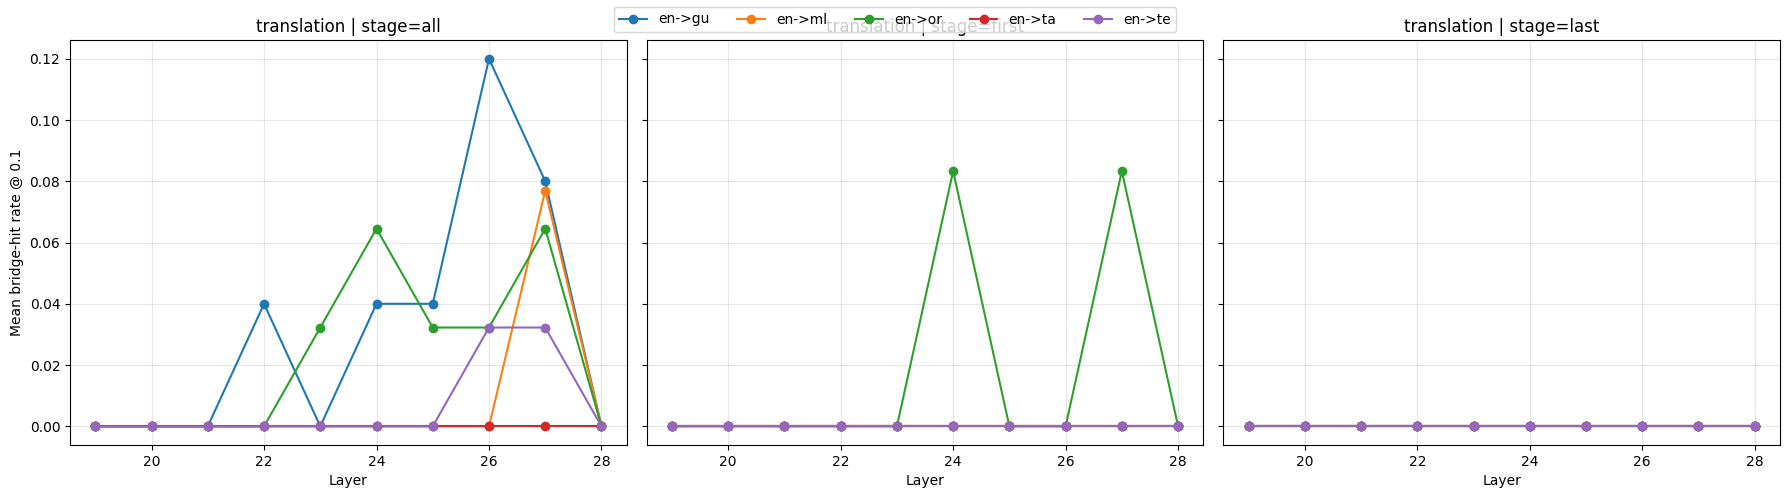

,pair,single_hit_rate@0.1
0,en->gu,0.072727
1,en->ml,0.025000
2,en->or,0.083333
3,en->ta,0.000000
4,en->te,0.025000


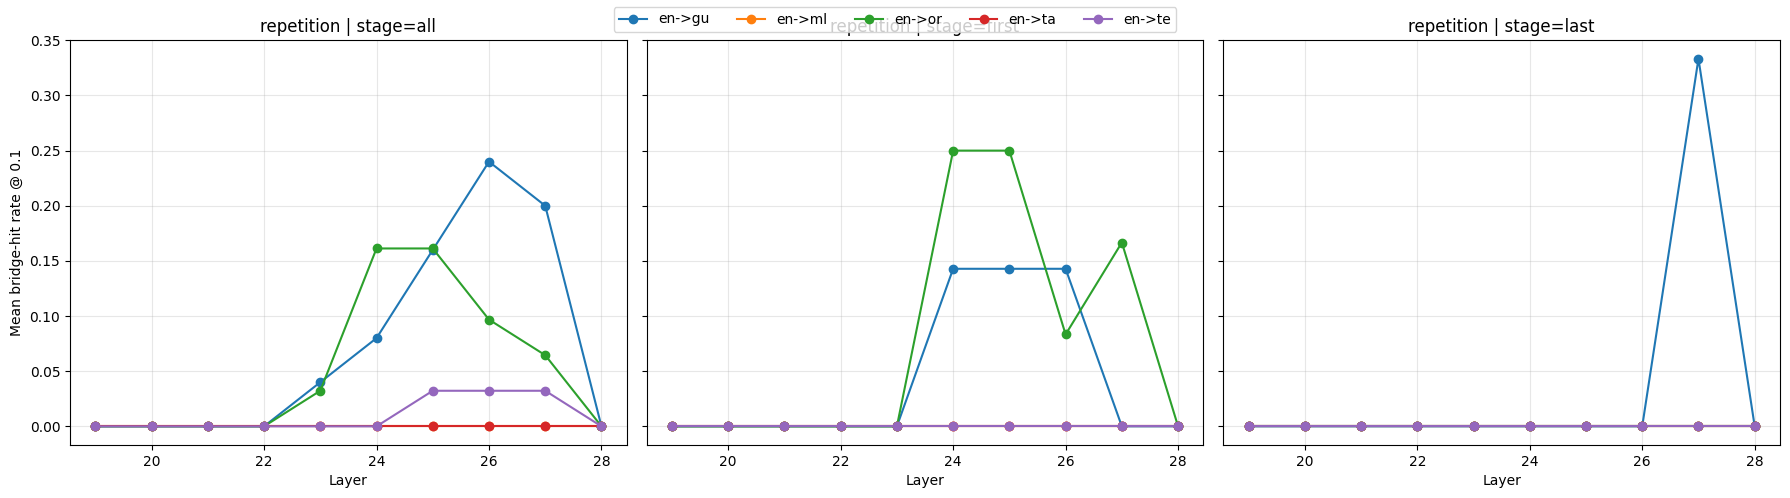

,pair,single_hit_rate@0.1
0,en->gu,0.118182
1,en->ml,0.000000
2,en->or,0.116667
3,en->ta,0.000000
4,en->te,0.037500


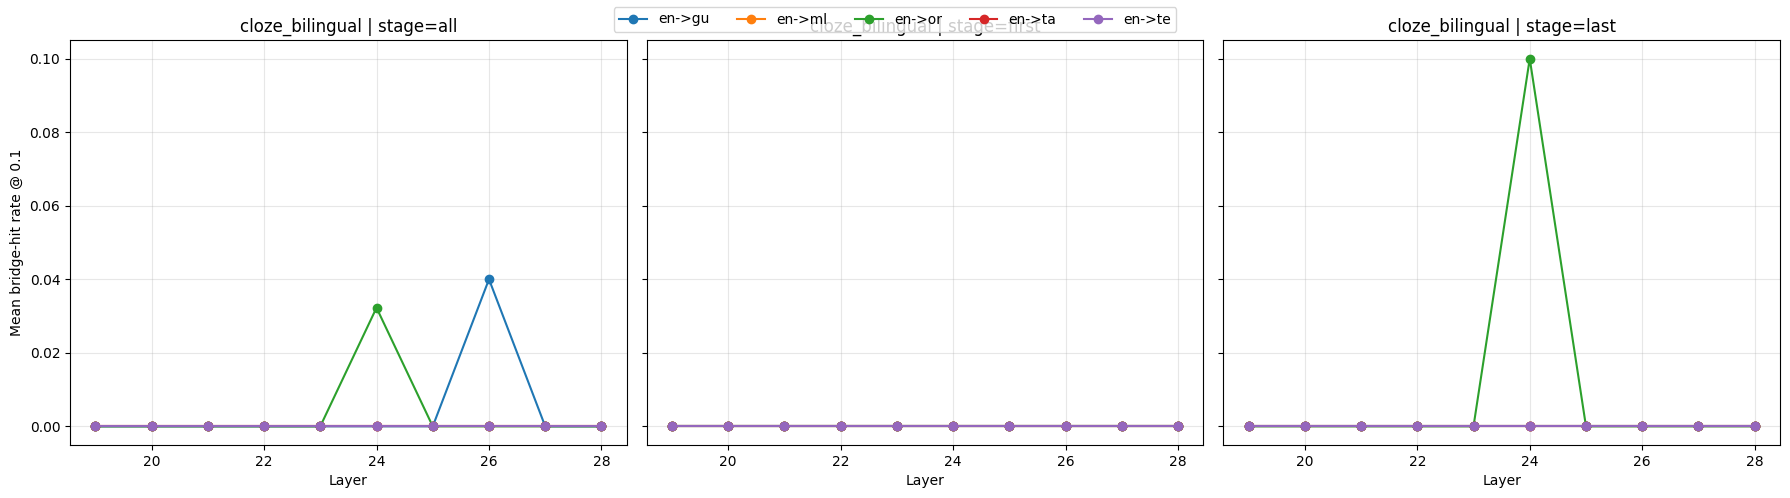

,pair,single_hit_rate@0.1
0,en->gu,0.009091
1,en->ml,0.000000
2,en->or,0.000000
3,en->ta,0.000000
4,en->te,0.000000


In [ ]:
def filter_last_n_layers(df, n_last=LAST_N_LAYERS_FOR_PAPER_STYLE_PLOTS):
    if len(df) == 0:
        return df
    max_layer = int(df["layer"].max())
    keep_layers = list(range(max(max_layer - n_last + 1, 0), max_layer + 1))
    return df[df["layer"].isin(keep_layers)].copy()

paper_plot_df = filter_last_n_layers(results_summary_df)

for task in TASKS:
    sub = paper_plot_df[paper_plot_df["task"] == task]
    if len(sub) == 0:
        continue

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    for ax, stage_name in zip(axes, ["all", "first", "last"]):
        if stage_name == "all":
            stage_sub = sub[~sub[f"bridge_hit@{PRIMARY_THRESHOLD}"].isna()].copy()
        else:
            stage_sub = sub[sub["stage"] == stage_name].copy()

        for pair in sorted(stage_sub["pair"].unique()):
            s = stage_sub[stage_sub["pair"] == pair].groupby("layer")[f"bridge_hit@{PRIMARY_THRESHOLD}"].mean().reset_index()
            ax.plot(s["layer"], s[f"bridge_hit@{PRIMARY_THRESHOLD}"], marker="o", label=pair)

        ax.set_title(f"{task} | stage={stage_name}")
        ax.set_xlabel("Layer")
        ax.grid(alpha=0.3)

    axes[0].set_ylabel(f"Mean bridge-hit rate @ {PRIMARY_THRESHOLD}")
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=min(5, len(labels)))
    plt.tight_layout()
    plt.show()

    single_sub = sub[sub["stage"] == "single"]
    if len(single_sub):
        display(single_sub.groupby("pair")[f"bridge_hit@{PRIMARY_THRESHOLD}"].mean().reset_index(name=f"single_hit_rate@{PRIMARY_THRESHOLD}"))

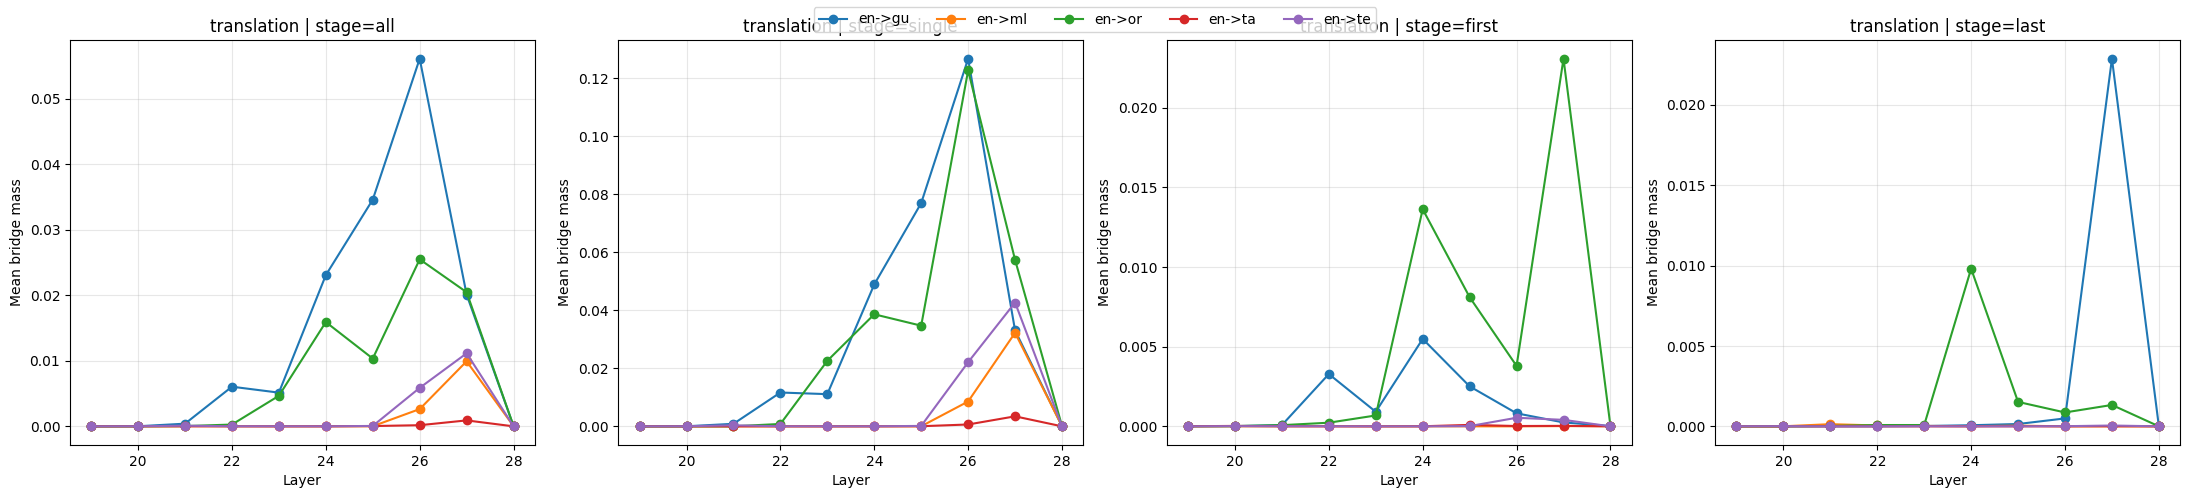

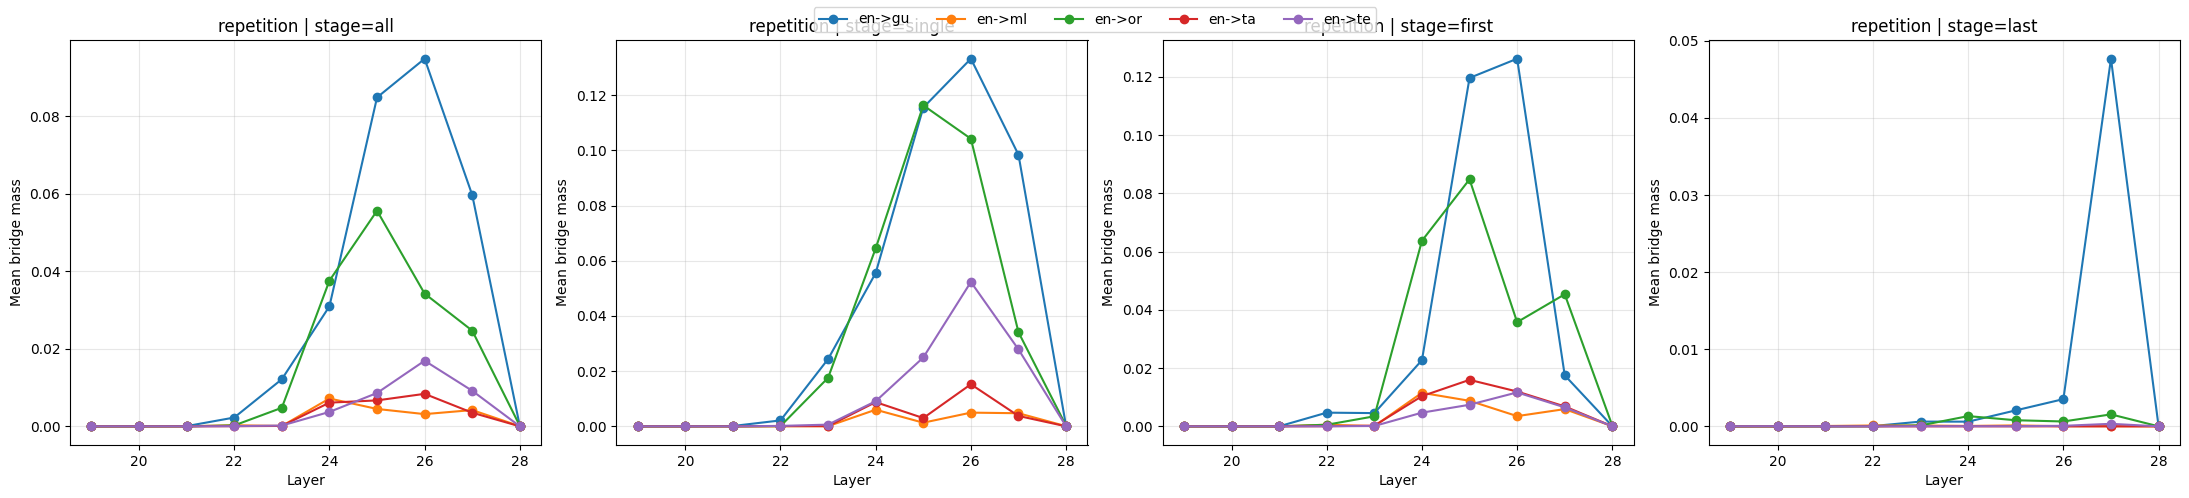

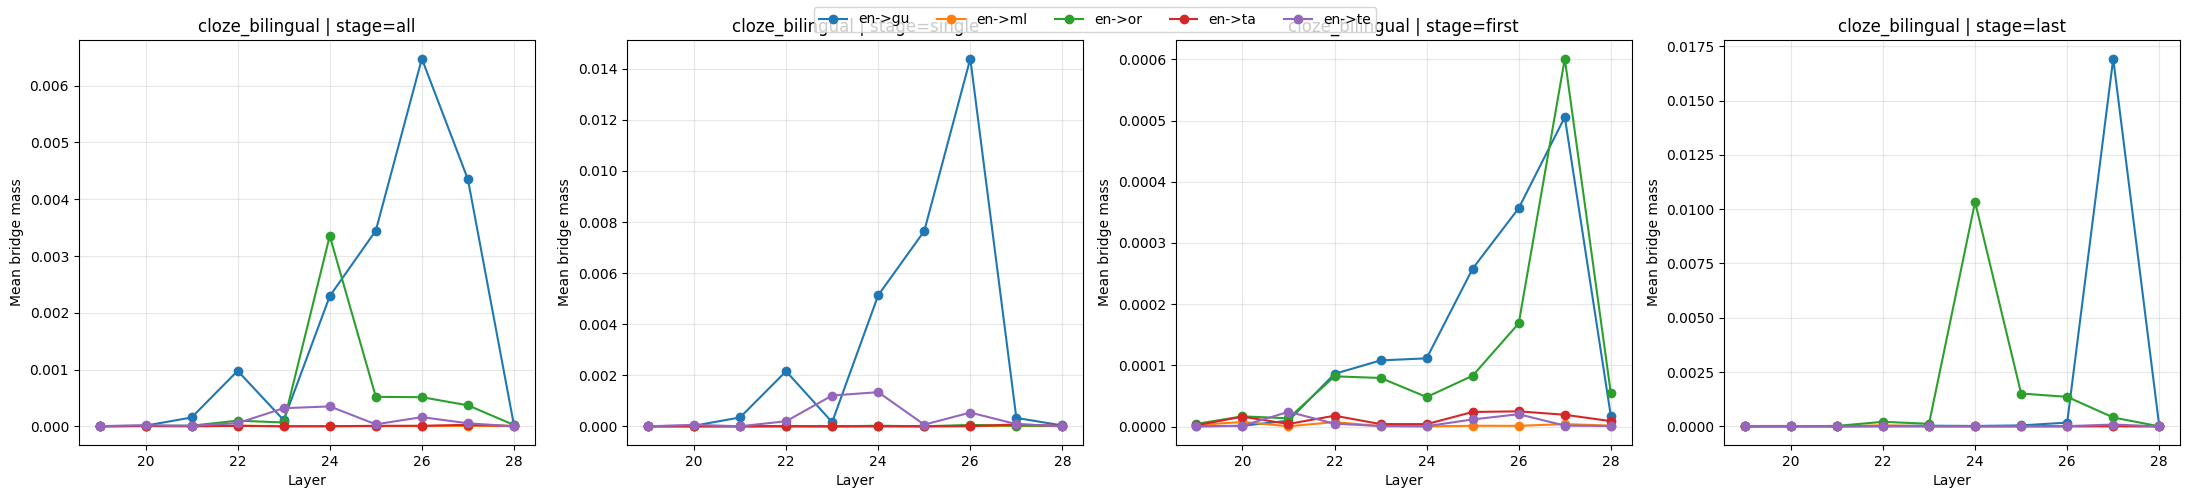

In [ ]:
for task in TASKS:
    sub = paper_plot_df[paper_plot_df["task"] == task]
    if len(sub) == 0:
        continue

    fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=False)
    for ax, stage_name in zip(axes, ["all", "single", "first", "last"]):
        if stage_name == "all":
            stage_sub = sub.copy()
        else:
            stage_sub = sub[sub["stage"] == stage_name].copy()

        for pair in sorted(stage_sub["pair"].unique()):
            s = stage_sub[stage_sub["pair"] == pair].groupby("layer")["bridge_mass"].mean().reset_index()
            ax.plot(s["layer"], s["bridge_mass"], marker="o", label=pair)

        ax.set_title(f"{task} | stage={stage_name}")
        ax.set_xlabel("Layer")
        ax.set_ylabel("Mean bridge mass")
        ax.grid(alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=min(5, len(labels)))
    plt.tight_layout()
    plt.show()

,pair,task,mean_frequency
0,en->gu,cloze_bilingual,0.004000
1,en->gu,repetition,0.072000
2,en->gu,translation,0.032000
3,en->ml,cloze_bilingual,0.000000
4,en->ml,repetition,0.000000
5,en->ml,translation,0.007692
6,en->or,cloze_bilingual,0.003226
7,en->or,repetition,0.051613
8,en->or,translation,0.022581
9,en->ta,cloze_bilingual,0.000000


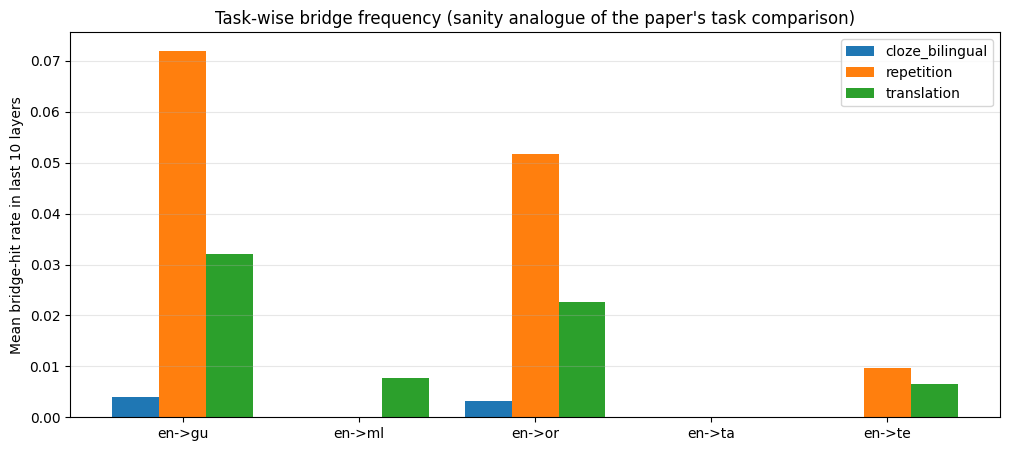

In [ ]:
freq_df = filter_last_n_layers(results_summary_df)
metric = f"bridge_hit@{PRIMARY_THRESHOLD}"
freq_plot_rows = []

if len(freq_df):
    valid = freq_df[~freq_df[metric].isna()].copy()
    for (pair, task), grp in valid.groupby(["pair", "task"]):
        freq_plot_rows.append({
            "pair": pair,
            "task": task,
            "mean_frequency": grp[metric].mean(),
        })

freq_plot_df = pd.DataFrame(freq_plot_rows)
display(freq_plot_df)

if len(freq_plot_df):
    pairs = sorted(freq_plot_df["pair"].unique())
    tasks_sorted = list(dict.fromkeys(freq_plot_df["task"].tolist()))
    x = np.arange(len(pairs))
    width = 0.8 / max(1, len(tasks_sorted))

    plt.figure(figsize=(12, 5))
    for i, task in enumerate(tasks_sorted):
        vals = []
        for pair in pairs:
            sub = freq_plot_df[(freq_plot_df["pair"] == pair) & (freq_plot_df["task"] == task)]
            vals.append(float(sub["mean_frequency"].iloc[0]) if len(sub) else 0.0)
        plt.bar(x + i*width, vals, width=width, label=task)

    plt.xticks(x + width*(len(tasks_sorted)-1)/2, pairs)
    plt.ylabel(f"Mean bridge-hit rate in last {LAST_N_LAYERS_FOR_PAPER_STYLE_PLOTS} layers")
    plt.title("Task-wise bridge frequency (sanity analogue of the paper's task comparison)")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.show()

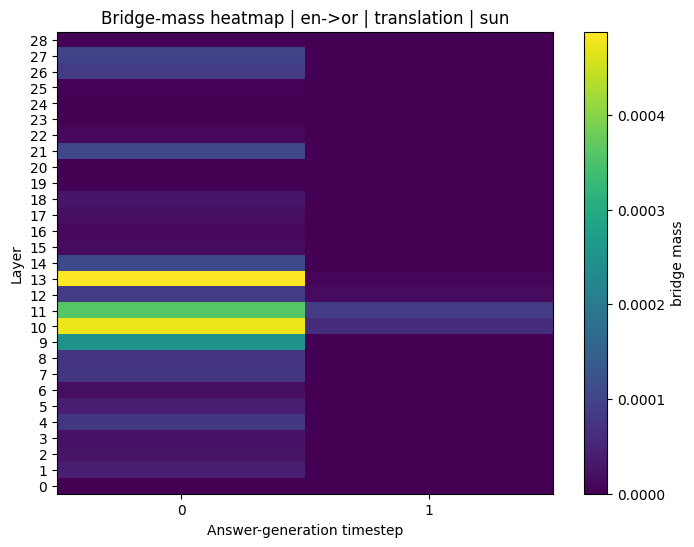

In [ ]:
if len(results_summary_df):
    sub = results_summary_df[
        (results_summary_df["pair"] == INSPECT_PAIR) &
        (results_summary_df["task"] == INSPECT_TASK) &
        (results_summary_df["concept"] == INSPECT_CONCEPT)
    ].copy()

    pivot = sub.pivot_table(index="layer", columns="timestep", values="bridge_mass", aggfunc="mean")
    plt.figure(figsize=(8, 6))
    plt.imshow(pivot.values, aspect="auto", origin="lower")
    plt.colorbar(label="bridge mass")
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xlabel("Answer-generation timestep")
    plt.ylabel("Layer")
    plt.title(f"Bridge-mass heatmap | {INSPECT_PAIR} | {INSPECT_TASK} | {INSPECT_CONCEPT}")
    plt.show()

# **Eng-Santhali**

In [ ]:
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_PRESETS = {
    "sarvam-1": {
        "hf_name": "sarvamai/sarvam-1",
        "family": "base_completion",
        "prefer_chat_template": False,
        "note": "2B multilingual Indic completion model",
    },
    "param-1-7b": {
        "hf_name": "bharatgenai/Param-1-7B",
        "family": "base_completion",
        "prefer_chat_template": False,
        "note": "7B multilingual Indic MoE base model",
    },
    "sarvam-translate": {
        "hf_name": "sarvamai/sarvam-translate",
        "family": "instruction_translation",
        "prefer_chat_template": True,
        "note": "Gemma3-4B-IT based translation-specialized model; non-translation tasks are exploratory",
    },
}

MODEL_KEY = "sarvam-1"  # change here
MODEL_NAME = MODEL_PRESETS[MODEL_KEY]["hf_name"]

# Active bridge for this notebook version
BRIDGE = "deva"   # "deva" or "beng"

# Default source-language setup
SOURCE_LANGS = ["en"]   # add "hi" later if desired

# Default target pairs for Devanagari sanity
TARGET_LANGS = ["sat", "gu", "ml", "ta", "te"]

# Small sanity lexicon size
N_EXAMPLES_PER_PAIR = 18

# Task policy
TASKS_DEFAULT = ["translation", "repetition", "cloze_bilingual"]
ALLOW_NON_TRANSLATION_TASKS_FOR_SARVAM_TRANSLATE = False

if MODEL_KEY == "sarvam-translate" and not ALLOW_NON_TRANSLATION_TASKS_FOR_SARVAM_TRANSLATE:
    TASKS = ["translation"]
else:
    TASKS = TASKS_DEFAULT

# Threshold sweep for the max-candidate rule
PRIMARY_THRESHOLD = 0.10
THRESHOLD_SWEEP = [0.20, 0.10, 0.05, 0.02]

# Candidate construction
USE_GRAPHEME_SEGMENTATION = True
SPACE_MARKER_CANDIDATES = ["▁", " "]  # SentencePiece + literal-space forms

# Roman control policy
ROMAN_CONTROL_MODE = "ascii_simplified"
# options:
#   "ascii_simplified" -> deterministic Roman transliteration followed by ASCII simplification
#   "deterministic_raw" -> deterministic Roman transliteration only

# Chat template policy
USE_CHAT_TEMPLATE_IF_AVAILABLE = True

# Compute budget
USE_4BIT = True
RUN_WARMUP_ONLY = False
MAX_WARMUP_EXAMPLES_PER_PAIR = 4
LAST_N_LAYERS_FOR_PAPER_STYLE_PLOTS = 10
TOP_K_FOR_INSPECTION = 15
COLLECT_BRIDGE_CANDIDATE_PROBS = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print({
    "model_key": MODEL_KEY,
    "model_name": MODEL_NAME,
    "bridge": BRIDGE,
    "source_langs": SOURCE_LANGS,
    "target_langs": TARGET_LANGS,
    "n_examples_per_pair": N_EXAMPLES_PER_PAIR,
    "tasks": TASKS,
    "roman_control_mode": ROMAN_CONTROL_MODE,
    "threshold_sweep": THRESHOLD_SWEEP,
    "device": DEVICE,
})

{'model_key': 'sarvam-1', 'model_name': 'sarvamai/sarvam-1', 'bridge': 'deva', 'source_langs': ['en'], 'target_langs': ['sat', 'gu', 'ml', 'ta', 'te'], 'n_examples_per_pair': 18, 'tasks': ['translation', 'repetition', 'cloze_bilingual'], 'roman_control_mode': 'ascii_simplified', 'threshold_sweep': [0.2, 0.1, 0.05, 0.02], 'device': 'cuda'}


In [ ]:
CONCEPTS = [
    "sun", "moon", "water", "fire", "book", "flower", "fish", "mango",
    "brother", "mother", "door", "rope", "music", "school", "house",
    "cat", "elephant", "tree"
]

LEXICON = {
    "sat": {
    "sun": "ᱥᱤᱸᱜᱽ",
    "moon": "ᱪᱟᱸᱫᱚ",
    "water": "ᱫᱟᱜ",
    "fire": "ᱥᱮᱸᱜᱮᱞ",
    "book": "ᱯᱚᱛᱚᱵ",
    "flower": "ᱵᱟᱦᱟ",
    "fish": "ᱦᱟᱹᱠᱩ",
    "mango": "ᱩᱞ",
    "brother": "ᱵᱚᱭᱦᱟ",
    "mother": "ᱟᱭᱩ",
    "door": "ᱫᱩᱣᱟᱹᱨ",
    "rope": "ᱵᱟᱵᱮᱨ",
    "music": "ᱥᱮᱨᱮᱧ",
    "school": "ᱥᱮᱪᱮᱫ ᱚᱲᱟᱜ",
    "house": "ᱚᱲᱟᱜ",
    "cat": "ᱯᱩᱥᱤ",
    "elephant": "ᱦᱟᱹᱛᱷᱤ",
    "tree": "ᱫᱟᱨᱮ"
},
    "gu": {
        "sun":"સૂર્ય", "moon":"ચંદ્ર", "water":"પાણી", "fire":"આગ", "book":"પુસ્તક",
        "flower":"ફૂલ", "fish":"માછલી", "mango":"કેરી", "brother":"ભાઈ", "mother":"મા",
        "door":"દરવાજો", "rope":"દોરડું", "music":"સંગીત", "school":"શાળા",
        "house":"ઘર", "cat":"બિલાડી", "elephant":"હાથી", "tree":"ઝાડ"
    },
    "ml": {
        "sun":"സൂര്യൻ", "moon":"ചന്ദ്രൻ", "water":"വെള്ളം", "fire":"തീ", "book":"പുസ്തകം",
        "flower":"പൂവ്", "fish":"മീൻ", "mango":"മാങ്ങ", "brother":"സഹോദരൻ", "mother":"അമ്മ",
        "door":"വാതിൽ", "rope":"കയർ", "music":"സംഗീതം", "school":"സ്കൂൾ",
        "house":"വീട്", "cat":"പൂച്ച", "elephant":"ആന", "tree":"മരം"
    },
    "ta": {
        "sun":"சூரியன்", "moon":"நிலா", "water":"தண்ணீர்", "fire":"நெருப்பு", "book":"புத்தகம்",
        "flower":"பூ", "fish":"மீன்", "mango":"மாம்பழம்", "brother":"அண்ணன்", "mother":"அம்மா",
        "door":"கதவு", "rope":"கயிறு", "music":"இசை", "school":"பள்ளி",
        "house":"வீடு", "cat":"பூனை", "elephant":"யானை", "tree":"மரம்"
    },
    "te": {
        "sun":"సూర్యుడు", "moon":"చంద్రుడు", "water":"నీరు", "fire":"అగ్ని", "book":"పుస్తకం",
        "flower":"పువ్వు", "fish":"చేప", "mango":"మామిడి", "brother":"అన్న", "mother":"అమ్మ",
        "door":"తలుపు", "rope":"తాడు", "music":"సంగీతం", "school":"పాఠశాల",
        "house":"ఇల్లు", "cat":"పిల్లి", "elephant":"ఏనుగు", "tree":"చెట్టు"
    },
}

LANG_NAMES = {
    "en":"English", "hi":"Hindi", "mr":"Marathi", "bn":"Bengali", "gu":"Gujarati",
    "ml":"Malayalam", "ta":"Tamil", "te":"Telugu", "or":"Odia", "pa":"Punjabi", "sat": "Santhali", "kn":"Kannada"
}

rows = []
for src in SOURCE_LANGS:
    for tgt in TARGET_LANGS:
        for concept in CONCEPTS[:N_EXAMPLES_PER_PAIR]:
            rows.append({
                "pair": f"{src}->{tgt}",
                "source_lang": src,
                "target_lang": tgt,
                "concept": concept,
                "source_word": concept if src == "en" else None,   # filled later for hi if needed
                "target_word_native": LEXICON[tgt][concept],
            })

lexicon_df = pd.DataFrame(rows)
display(lexicon_df.head(20))
print("Total rows:", len(lexicon_df))

,pair,source_lang,target_lang,concept,source_word,target_word_native
0,en->sat,en,sat,sun,sun,ᱥᱤᱸᱜᱽ
1,en->sat,en,sat,moon,moon,ᱪᱟᱸᱫᱚ
2,en->sat,en,sat,water,water,ᱫᱟᱜ
3,en->sat,en,sat,fire,fire,ᱥᱮᱸᱜᱮᱞ
4,en->sat,en,sat,book,book,ᱯᱚᱛᱚᱵ
5,en->sat,en,sat,flower,flower,ᱵᱟᱦᱟ
6,en->sat,en,sat,fish,fish,ᱦᱟᱹᱠᱩ
7,en->sat,en,sat,mango,mango,ᱩᱞ
8,en->sat,en,sat,brother,brother,ᱵᱚᱭᱦᱟ
9,en->sat,en,sat,mother,mother,ᱟᱭᱩ


Total rows: 90


In [ ]:
# Small source-side lexicon for Hindi extension.
# This is only used if "hi" is included in SOURCE_LANGS.
SOURCE_LEXICON = {
    "hi": {
        "sun":"सूरज", "moon":"चाँद", "water":"पानी", "fire":"आग", "book":"पुस्तक",
        "flower":"फूल", "fish":"मछली", "mango":"आम", "brother":"भाई", "mother":"माँ",
        "door":"दरवाज़ा", "rope":"रस्सी", "music":"संगीत", "school":"स्कूल",
        "house":"घर", "cat":"बिल्ली", "elephant":"हाथी", "tree":"पेड़"
    }
}

def fill_source_word(row):
    if row["source_lang"] == "en":
        return row["concept"]
    return SOURCE_LEXICON[row["source_lang"]][row["concept"]]

lexicon_df["source_word"] = lexicon_df.apply(fill_source_word, axis=1)
display(lexicon_df.head(20))

,pair,source_lang,target_lang,concept,source_word,target_word_native
0,en->sat,en,sat,sun,sun,ᱥᱤᱸᱜᱽ
1,en->sat,en,sat,moon,moon,ᱪᱟᱸᱫᱚ
2,en->sat,en,sat,water,water,ᱫᱟᱜ
3,en->sat,en,sat,fire,fire,ᱥᱮᱸᱜᱮᱞ
4,en->sat,en,sat,book,book,ᱯᱚᱛᱚᱵ
5,en->sat,en,sat,flower,flower,ᱵᱟᱦᱟ
6,en->sat,en,sat,fish,fish,ᱦᱟᱹᱠᱩ
7,en->sat,en,sat,mango,mango,ᱩᱞ
8,en->sat,en,sat,brother,brother,ᱵᱚᱭᱦᱟ
9,en->sat,en,sat,mother,mother,ᱟᱭᱩ


In [ ]:
AKSH_SCRIPT = {
    "sat": "Santhali",
    "gu": "Gujarati",
    "hi": "Devanagari",
    "mr": "Devanagari",
    "ml": "Malayalam",
    "ta": "Tamil",
    "te": "Telugu",
    "or": "Oriya",
    "pa": "Gurmukhi",
    "kn": "Kannada",
    "en": None,
}

BRIDGE_TARGET_CODE = {"deva": "hi", "beng": "bn"}
BRIDGE_TARGET_SCRIPT = {"deva": "Devanagari", "sat": "Ol Chiki"}

def safe_strip(s: str) -> str:
    return re.sub(r"\s+", " ", s).strip()

def translit_native_to_bridge(text: str, src_lang: str, bridge: str) -> Tuple[str, str]:
    if src_lang == "en":
        return text, "identity-en"
    if bridge not in BRIDGE_TARGET_CODE:
        raise ValueError(bridge)
    try:
        out = UnicodeIndicTransliterator.transliterate(text, src_lang, BRIDGE_TARGET_CODE[bridge])
        return safe_strip(out), "unicode_indic"
    except Exception:
        out = aksh_trans.process(AKSH_SCRIPT[src_lang], BRIDGE_TARGET_SCRIPT[bridge], text)
        return safe_strip(out), "aksharamukha_fallback"

def strip_to_ascii(text: str) -> str:
    return safe_strip(unidecode(text))

def translit_native_to_roman(text: str, src_lang: str) -> Tuple[str, str]:
    if src_lang == "en":
        return text, "identity-en"
    raw = aksh_trans.process(AKSH_SCRIPT[src_lang], "ISO", text)
    raw = safe_strip(raw)
    if ROMAN_CONTROL_MODE == "deterministic_raw":
        return raw, "aksharamukha_iso"
    elif ROMAN_CONTROL_MODE == "ascii_simplified":
        return strip_to_ascii(raw), "aksharamukha_iso_plus_unidecode"
    else:
        raise ValueError(ROMAN_CONTROL_MODE)

forms_rows = []
for _, row in lexicon_df.iterrows():
    roman_word, roman_tool = translit_native_to_roman(row["target_word_native"], row["target_lang"])
    deva_word, deva_tool = translit_native_to_bridge(row["target_word_native"], row["target_lang"], "deva")
    beng_word, beng_tool = translit_native_to_bridge(row["target_word_native"], row["target_lang"], "beng")
    forms_rows.append({
        **row.to_dict(),
        "target_word_roman_control": roman_word,
        "roman_control_tool": roman_tool,
        "target_word_bridge_deva": deva_word,
        "deva_bridge_tool": deva_tool,
        "target_word_bridge_beng": beng_word,
        "beng_bridge_tool": beng_tool,
        "manual_note": "",
    })

forms_df = pd.DataFrame(forms_rows)
display(forms_df.head(20))

NameError: name 'Tuple' is not defined

In [ ]:
def codepoint_list(text: str) -> List[str]:
    return [f"{ch} (U+{ord(ch):04X}, {unicodedata.name(ch, 'UNKNOWN')})" for ch in text]

def graphemes(text: str) -> List[str]:
    return re.findall(r"\X", text)

toy_examples = []
for idx in [0, 10, 20, 40]:
    row = forms_df.iloc[idx]
    bridge_word = row["target_word_bridge_deva"] if BRIDGE == "deva" else row["target_word_bridge_beng"]
    toy_examples.append({
        "pair": row["pair"],
        "concept": row["concept"],
        "native_word": row["target_word_native"],
        "bridge_word": bridge_word,
        "codepoints": codepoint_list(bridge_word),
        "graphemes_used_for_scoring": graphemes(bridge_word),
        "human_note": "Compare graphemes with visible Indic units; this is still not a final akshara scorer."
    })

toy_seg_df = pd.DataFrame(toy_examples)
display(toy_seg_df)

,pair,concept,native_word,bridge_word,codepoints,graphemes_used_for_scoring,human_note
0,en->sat,sun,ᱥᱤᱸᱜᱽ,ᱥᱤᱸᱜᱽ,"[ᱥ (U+1C65, OL CHIKI LETTER IS), ᱤ (U+1C64, OL CHIKI LETTER LI), ᱸ (U+1C78, OL CHIKI MU TTUDDAG), ᱜ (U+1C5C, OL CHIKI LETTER AG), ᱽ (U+1C7D, OL CHIKI AHAD)]","[ᱥ, ᱤ, ᱸ, ᱜ, ᱽ]",Compare graphemes with visible Indic units; this is still not a final akshara scorer.
1,en->sat,door,ᱫᱩᱣᱟᱹᱨ,ᱫᱩᱣᱟᱹᱨ,"[ᱫ (U+1C6B, OL CHIKI LETTER UD), ᱩ (U+1C69, OL CHIKI LETTER LU), ᱣ (U+1C63, OL CHIKI LETTER AAW), ᱟ (U+1C5F, OL CHIKI LETTER LAA), ᱹ (U+1C79, OL CHIKI GAAHLAA TTUDDAAG), ᱨ (U+1C68, OL CHIKI LETTER...","[ᱫ, ᱩ, ᱣ, ᱟ, ᱹ, ᱨ]",Compare graphemes with visible Indic units; this is still not a final akshara scorer.
2,en->gu,water,પાણી,पाणी,"[प (U+092A, DEVANAGARI LETTER PA), ा (U+093E, DEVANAGARI VOWEL SIGN AA), ण (U+0923, DEVANAGARI LETTER NNA), ी (U+0940, DEVANAGARI VOWEL SIGN II)]","[पा, णी]",Compare graphemes with visible Indic units; this is still not a final akshara scorer.
3,en->ml,book,പുസ്തകം,पुस्तकं,"[प (U+092A, DEVANAGARI LETTER PA), ु (U+0941, DEVANAGARI VOWEL SIGN U), स (U+0938, DEVANAGARI LETTER SA), ् (U+094D, DEVANAGARI SIGN VIRAMA), त (U+0924, DEVANAGARI LETTER TA), क (U+0915, DEVANAGAR...","[पु, स्त, कं]",Compare graphemes with visible Indic units; this is still not a final akshara scorer.


In [ ]:
CLOZE_TEMPLATES = {
    "sun": "The ___ rises in the east.",
    "moon": "The ___ shines at night.",
    "water": "People drink ___ every day.",
    "fire": "A camp ___ gives warmth.",
    "book": "I read a ___ before sleeping.",
    "flower": "A ___ often grows in a garden.",
    "fish": "A ___ swims in water.",
    "mango": "A ripe ___ is sweet.",
    "brother": "My ___ helps me at home.",
    "mother": "My ___ cooks food.",
    "door": "Please close the ___ quietly.",
    "rope": "He tied the box with a ___.",
    "music": "Soft ___ can be relaxing.",
    "school": "Children go to ___ in the morning.",
    "house": "Their ___ is near the market.",
    "cat": "A ___ likes to chase mice.",
    "elephant": "An ___ is a very large animal.",
    "tree": "A ___ gives shade."
}

def sample_shots(examples_df: pd.DataFrame, query_concept: str, k: int, rng: random.Random):
    pool = [row for _, row in examples_df.iterrows() if row["concept"] != query_concept]
    rng.shuffle(pool)
    return pool[:k]

def build_translation_prompt(pair_df: pd.DataFrame, query_row: pd.Series, k: int = 5, rng=None) -> str:
    rng = rng or random.Random(SEED)
    shots = sample_shots(pair_df, query_row["concept"], k=k, rng=rng)
    src_name = LANG_NAMES[query_row["source_lang"]]
    tgt_name = LANG_NAMES[query_row["target_lang"]]
    lines = []
    for s in shots:
        lines.append(f'{src_name}: "{s["source_word"]}" {tgt_name}: "{s["target_word_native"]}"')
    lines.append(f'{src_name}: "{query_row["source_word"]}" {tgt_name}: "')
    return "\n".join(lines)

def build_repetition_prompt(pair_df: pd.DataFrame, query_row: pd.Series, k: int = 5, rng=None) -> str:
    rng = rng or random.Random(SEED)
    shots = sample_shots(pair_df, query_row["concept"], k=k, rng=rng)
    tgt_name = LANG_NAMES[query_row["target_lang"]]
    lines = []
    for s in shots:
        w = s["target_word_native"]
        lines.append(f'{tgt_name}: "{w}" {tgt_name}: "{w}"')
    q = query_row["target_word_native"]
    lines.append(f'{tgt_name}: "{q}" {tgt_name}: "')
    return "\n".join(lines)

def build_cloze_prompt(pair_df: pd.DataFrame, query_row: pd.Series, k: int = 2, rng=None) -> str:
    rng = rng or random.Random(SEED)
    shots = sample_shots(pair_df, query_row["concept"], k=k, rng=rng)
    tgt_name = LANG_NAMES[query_row["target_lang"]]
    lines = []
    for s in shots:
        lines.append(f'{CLOZE_TEMPLATES[s["concept"]]} Answer in {tgt_name}: "{s["target_word_native"]}"')
    lines.append(f'{CLOZE_TEMPLATES[query_row["concept"]]} Answer in {tgt_name}: "')
    return "\n".join(lines)

demo_row = forms_df.iloc[0]
demo_pair_df = forms_df[forms_df["pair"] == demo_row["pair"]].copy()
print("=== Translation ===")
print(build_translation_prompt(demo_pair_df, demo_row))
print("\n=== Repetition ===")
print(build_repetition_prompt(demo_pair_df, demo_row))
print("\n=== Cloze ===")
print(build_cloze_prompt(demo_pair_df, demo_row))